# [이론] 계층 모형과 MCMC — 사전 강도를 데이터로 추정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 배울 것

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">AI 데이터 인텔리전스 전문가 과정 · 모형추정과 심화통계</div>
<h1 style="color:#000000;margin:10px 0">사전 강도를 데이터로 추정하기 — 계층 모형과 MCMC</h1>
<div style="font-size:1.05em;color:#656565">계약 63건인 세그먼트 하나의 요율을 확정합니다</div>
</div>

## 0. 오늘 배울 것

**여기서 할 일**

1. 오늘 다룰 대상인 계약 63건인 세그먼트가 어떤 조건으로 만들어졌는지 확인합니다.
2. 첫날의 구간 계산이 그 세그먼트에서 왜 쓸 수 없는 값을 내는지 확인합니다.
3. 둘째 날 지정한 사전 강도 102건의 근거를 확인합니다.

**여기서 다루는 값** — 오늘의 질문인 계약 63건 세그먼트는 지역×브랜드×차량 출력으로 나눈 2,323개 세그먼트 가운데 하나이고, 여기서 쓰는 값은 사고 경험률 $p$(단위 없는 비율)입니다. 1번부터 5번까지의 주제는 지역×브랜드 242개 세그먼트의 연간 사고율 $\lambda$(단위: 건/년)로 부분 풀링과 MCMC 를 익히고, 6번부터 같은 계산을 이 세그먼트의 사고 경험률에 적용합니다.

**세그먼트(segment)** 는 조건을 겹쳐 만든 조합 하나와 그 조합에 속한 계약 n건을 함께 부르는 이름입니다. 조건은 지역·브랜드·차량 출력 등급입니다. 요율표는 세그먼트마다 요율을 하나씩 적습니다.

첫날 확인한 세그먼트 하나는 조건 3개를 겹쳐 만든 조합입니다. 계약이 **63건**뿐이고 그중 4건이 기간 중 사고를 겪었습니다. 사고 경험률은 $4/63 = 6.35\%$ 인데, 같은 크기의 표본을 다시 뽑을 때 추정값이 흔들리는 정도인 첫날의 표준오차 $\mathrm{SE}$ 로 계산한 구간이 추정값 위아래로 $\pm 6.14\%$p 만큼 넓어 $\pm 2\,\mathrm{SE}$ 가 추정값과 거의 같은 크기입니다. 참값이 0.2% 일 수도 있고 12.5% 일 수도 있으므로 그 숫자로는 요율을 적을 수 없었습니다.

> **오늘의 질문 — 그 세그먼트에 요율을 얼마로 적을 것인가.**

오늘 얻을 답은 **0.0503** 이고 구간은 **[0.0312, 0.0759]** 입니다. 계약을 더 모아서가 아니라 **다른 세그먼트의 정보를 함께 써서** 이 값을 얻습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Mcmc-posterior-approximation.gif" width="960" height="480"/>
<p align="center"><em>▲ 사전분포(왼쪽)에서 출발한 표본이 누적되어(가운데) 사후분포(오른쪽)에 근접해 가는 과정 — 오늘 뒤에서 같은 방법을 코드로 직접 실행한다 (출처: Wikimedia Commons)</em></p>

둘째 날에는 데이터를 보기 전에 어느 모수값이 얼마나 그럴듯한지 미리 그려 둔 분포인 사전분포로 이 구간을 좁혔습니다. 사전 강도 102건, 곧 계약 102건을 미리 관측한 것과 같은 무게인 Beta(6, 96) 을 지정해 사후분포의 최빈값 MAP 0.0552 를 얻었는데, **그 102건에는 「그 정도면 적당해 보인다」 외에 근거가 없었습니다.** 같은 세그먼트에 중심을 0.0588 로 고정한 채 사전 강도만 20 · 102 · 1,020 으로 바꿔 대입하면 답이 0.0516 · 0.0552 · 0.0583 으로 달라지고, 그 차이 0.67%p 는 보험료로 13% 차이입니다($0.0583 \div 0.0516 - 1 = 0.13$). 오늘은 그 수를 사람이 지정하지 않고 데이터에서 추정합니다.

## 오늘의 순서

1번부터 5번까지는 지역×브랜드 242개 세그먼트의 연간 사고율로 부분 풀링과 MCMC 를 익히고, 6번부터 같은 계산을 오늘의 질문인 계약 63건 세그먼트의 사고 경험률에 적용합니다. 가운데 열에 주제마다 다루는 데이터와 값을 적었습니다.

| 주제 | 다루는 데이터와 값 | 새로 정의하는 용어 |
|---|---|---|
| 1. 세그먼트 하나만 쓰는 추정과 계약 전체를 쓰는 추정 | 지역×브랜드 242개 세그먼트의 연간 사고율 $\lambda$ | 무 풀링 · 완전 풀링 · 노출 |
| 2. 부분 풀링과 계층 모형 | 지역×브랜드 242개 세그먼트의 연간 사고율 $\lambda$ | 부분 풀링 · 계층 모형 · 세그먼트 편차 · 세그먼트 간 표준편차 |
| 3. 수축의 크기를 정하는 값: 노출 | 지역×브랜드 242개 세그먼트의 연간 사고율 $\lambda$ | 수축 · 수축의 크기 · 가상 노출 · 사전 강도 |
| 4. MCMC: 사후분포를 식으로 적을 수 없을 때 표본으로 얻는 방법 | 지역×브랜드 242개 세그먼트의 연간 사고율 $\lambda$, 연습 예시는 세그먼트 1개의 사고 경험률 $p$ | 켤레 · 차원의 저주 · MCMC · 제안 표준편차 · 수용률 · 번인 |
| 5. 수렴 진단: R-hat 과 유효표본수 | 지역×브랜드 242개 세그먼트의 연간 사고율 $\lambda$ | R-hat · 유효표본수 |
| 6. 사전 강도를 데이터로 추정 | 계약 63건 세그먼트가 속한 2,323개 세그먼트의 사고 경험률 $p$ | 등가 사전 강도 |
| 7. 요율표에 적는 값: 신용구간과 상대 구간 길이 | 계약 63건 세그먼트가 속한 2,323개 세그먼트의 사고 경험률 $p$ | 신용구간 · 상대 구간 길이 |
| 8. 오늘의 정리와 팀 토론 질문 | 연간 사고율 $\lambda$ 와 사고 경험률 $p$ 를 나누어 정리 | |

접어 둔 「자세히」는 전개하지 않아도 주제가 완결되고 퀴즈가 풀립니다.

**오늘의 지표 2개.** 오늘은 같은 데이터를 지표 2개로 측정합니다. 뜻도 단위도 다르므로 주제마다 「여기서 다루는 값」으로 어느 쪽을 쓰는지 밝힙니다.

| 지표 | 정의 | 단위 | 계약 전체의 값 | 오늘 쓰는 곳 |
|---|---|---|---|---|
| 사고 경험률 $p$ | 계약 $n$ 건 가운데 기간 중 사고를 1건 이상 겪은 계약 $k$ 건의 비율 | 없음(비율) | 0.0502 | 4번 주제의 연습 예시인 세그먼트 1개, 그리고 6번·7번 주제의 지역×브랜드×차량 출력 2,323개 세그먼트 이항 모형 |
| 연간 사고율 $\lambda$ | 사고 건수 $y$ 를 노출 합 $E$(1번 주제에서 정의)로 나눈 값 | 건/년 | 0.1006 | 1번부터 5번까지의 주제, 지역×브랜드 242개 세그먼트의 포아송 모형 |

<details class="lms-extra"><summary>자세히 — 읽기 전에 확인하는 첫날부터 넷째 날까지의 개념</summary>

오늘 글에 이름만 다시 나오는 개념입니다. 기억이 흐릿하면 여기서 한 줄로 확인하고 읽습니다.

- **사전분포**: 데이터를 보기 전에 어느 모수값이 얼마나 그럴듯한지 미리 그려 둔 분포입니다. (둘째 날)
- **우도**: 데이터를 관측된 상수로 고정해 두고, 모수가 그 값이라면 이 데이터가 나올 가능성을 모수 후보마다 매긴 점수입니다. (첫날)
- **사후분포**: 사전분포에 우도를 곱해 다시 계산한 분포입니다. (둘째 날)
- **MAP**: 사후분포의 최빈값입니다. 사전분포가 MLE 를 중심 쪽으로 수축시킨 추정값입니다. (둘째 날)
- **표준오차 SE**: 같은 크기의 표본을 다시 뽑을 때 추정값이 흔들리는 정도입니다. (첫날)
- **베타분포**: 0 과 1 사이의 값을 갖는 모수의 분포족입니다. (둘째 날)
- **로짓**: 확률 $\mu$ 를 $\log\dfrac{\mu}{1-\mu}$ 로 바꾼 값입니다. 0 과 1 사이의 확률을 경계 없는 값으로 옮깁니다. (셋째 날)
- **신뢰구간**: 같은 크기의 표본을 다시 뽑을 때 그 계산 절차가 만드는 구간의 95% 가 참값을 담는다는 뜻의 구간입니다. (넷째 날)

</details>

## 1. 세그먼트 하나만 쓰는 추정과 계약 전체를 쓰는 추정

**여기서 할 일**

1. 노출이 6.62년뿐인 세그먼트의 기록만으로 값을 계산하면 무엇이 문제인지 확인합니다.
2. 그 방식을 **무 풀링**이라 부르고 실제 데이터에서 나오는 값 3개를 확인합니다.
3. 반대쪽 극단인 **완전 풀링**과 표 한 장으로 대조합니다.

**여기서 다루는 값** — 연간 사고율 $\lambda$(단위: 건/년), 지역×브랜드 242개 세그먼트.

세그먼트에 적을 값을 정하는 방식에는 두 극단이 있습니다.

- **무 풀링(no pooling)** 은 세그먼트마다 **그 세그먼트의 데이터만** 보고 값을 계산하는 방식입니다.
- **완전 풀링(complete pooling)** 은 세그먼트 구분을 무시하고 계약 전체의 값 하나를 모든 세그먼트에 쓰는 방식입니다.

관측이 적은 세그먼트는 드물지 않습니다. 242개 세그먼트 가운데 **9개**는 관측 기간의 사고가 0건이라, 세그먼트 하나만 보고 값을 계산하면 답이 전부 0 이 됩니다. 0 은 요율표에 적을 수 없는 값입니다.

**노출(exposure) $E$** 는 계약이 실제로 보장을 받은 기간의 합이고 단위는 년입니다. 계약 1건을 1.0년 보장하면 노출 1년이고, 계약 2건을 0.5년씩 보장해도 노출 1년입니다.

계약 678,013건의 노출 합이 358,360.11년이라 계약 하나가 평균 0.53년만 보장을 받은 셈이고, 계약 전체의 사고 36,056건을 이 노출 합으로 나눈 값이 계약 전체의 연간 사고율 0.1006 건/년입니다. 우리는 계약 하나의 노출을 1.0년으로 잘라 쓰므로(첫날부터 쓰는 전처리), 노출 합이 수천 년이나 수만 년이 되는 것은 긴 계약이 있어서가 아니라 계약이 많아서입니다. 노출이 가장 많은 세그먼트는 계약 54,103건이 모여 35,949년입니다.

작은 예로 세그먼트 하나를 끝까지 따라갑니다. 계약 12건의 노출 합이 6.62년이고 그 기간의 사고가 2건인 세그먼트이며, 이후로는 **노출 6.62년 세그먼트**라 부릅니다.

사고 건수가 어떤 값으로 나오는지부터 정해 둡니다.

**포아송분포**는 정해진 기간에 드물게 일어나는 사건의 건수가 따르는 분포입니다. 사고 건수는 0, 1, 2 처럼 집계되는 값이라 이 분포를 씁니다.

노출 $E$ 년 동안의 사고 건수는 평균이 $\lambda \times E$ 입니다. 노출이 1년이면 평균이 $\lambda$ 입니다.

작은 수를 대입해 봅니다. 노출 6.62년 세그먼트에 계약 전체의 값을 적용하면 $\lambda \times E$ 가 $0.1006 \times 6.62 \approx 0.67$ 건이고, 이때는 사고 0건일 확률이 0.51 로 가장 큽니다. 노출이 그 6배인 세그먼트라면 $\lambda \times E$ 가 약 4 이고, 3건과 4건일 확률이 각각 0.195 로 가장 큽니다. 아래 그림에서 평균이 4 인 보라색 점을 보면 3건과 4건의 점이 가장 높습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Poisson_pmf.svg" width="560" height="433"/>
<p align="center"><em>▲ 포아송분포 — 가로축이 사고 건수, 세로축이 그 건수가 나올 확률이다. 그림의 λ 는 그 기간의 평균 건수이고, 우리 기호로는 λ × E 다. 평균이 1 이면 0건과 1건이 가장 흔하다. 계약 전체의 연간 사고율이 0.1006 건/년이고 계약 한 건의 평균 노출이 0.53년이라, 계약 한 건의 기대 사고 건수는 0.1006 × 0.53 ≈ 0.05 건이다. 그래서 사고 0건인 계약이 대부분이다 (출처: Wikipedia)</em></p>

무 풀링을 식으로 적습니다. 말로 먼저 적으면 「연간 사고율 = 사고 건수 ÷ 노출」입니다. 사고 건수의 평균이 $\lambda \times E$ 라는 식을 $\lambda$ 에 대해 정리한 형태입니다.

$$
\hat{\lambda}_j = \frac{y_j}{E_j}
$$

- $j$ : 세그먼트 번호이고 1부터 242까지입니다.
- $\lambda_j$ : 세그먼트 $j$ 의 아직 모르는 연간 사고율이고, 모자를 씌운 $\hat{\lambda}_j$ 는 그 값을 데이터로 계산한 추정값입니다. 모자는 추정값이라는 표시입니다.
- $y_j$ : 세그먼트 $j$ 의 사고 건수입니다.
- $E_j$ : 세그먼트 $j$ 의 노출 합(년)이고, 그 세그먼트에 누적된 관측량입니다.
- $\hat{\lambda}_j$ : 세그먼트 $j$ 의 연간 사고율 추정값입니다. 관측된 데이터가 나올 가능성이 가장 큰 값으로 고른 추정값이고, 첫날의 최대우도추정값과 같습니다.

노출 6.62년 세그먼트를 대입하면 $\hat{\lambda}_j = 2 \div 6.62$ 입니다. 이는 다음 뜻입니다.

- 분자는 그 세그먼트에서 일어난 사고 건수이고, 분모는 사고가 날 기회의 크기입니다.
- 다른 세그먼트의 사고와 노출은 이 식에 들어오지 않습니다.

#### 왜 사고 건수가 아니라 노출로 나누는가

사고 건수만 보면 그 세그먼트가 사고가 잦은 것인지 관측량이 많은 것인지 구분되지 않습니다. 연간 사고율이 똑같이 0.10 건/년이어도 노출이 10년이면 기대 사고가 1건이고, 노출이 1,000년이면 100건입니다.

노출로 나누면 세그먼트마다 다른 관측량이 빠지고 1년당 건수만 남습니다. 지금부터 5번 주제까지 쓰는 값이 연간 사고율이라 이 형태가 필요합니다.

이 값이 계약 전체의 값 0.1006 과 견줘 어느 쪽인지는 다음 그림에서 확인합니다.

> **[예측] 노출 6.62년에 사고 2건인 세그먼트의 무 풀링 연간 사고율은 계약 전체의 값 0.1006 의 몇 배일까요?**
>
> 1. 거의 같다 — 관측이 적은 세그먼트라 값이 크게 달라져도 약 1배다
> 2. 두 배쯤 — 약 0.20 이다
> 3. 세 배쯤 — 약 0.30 이다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

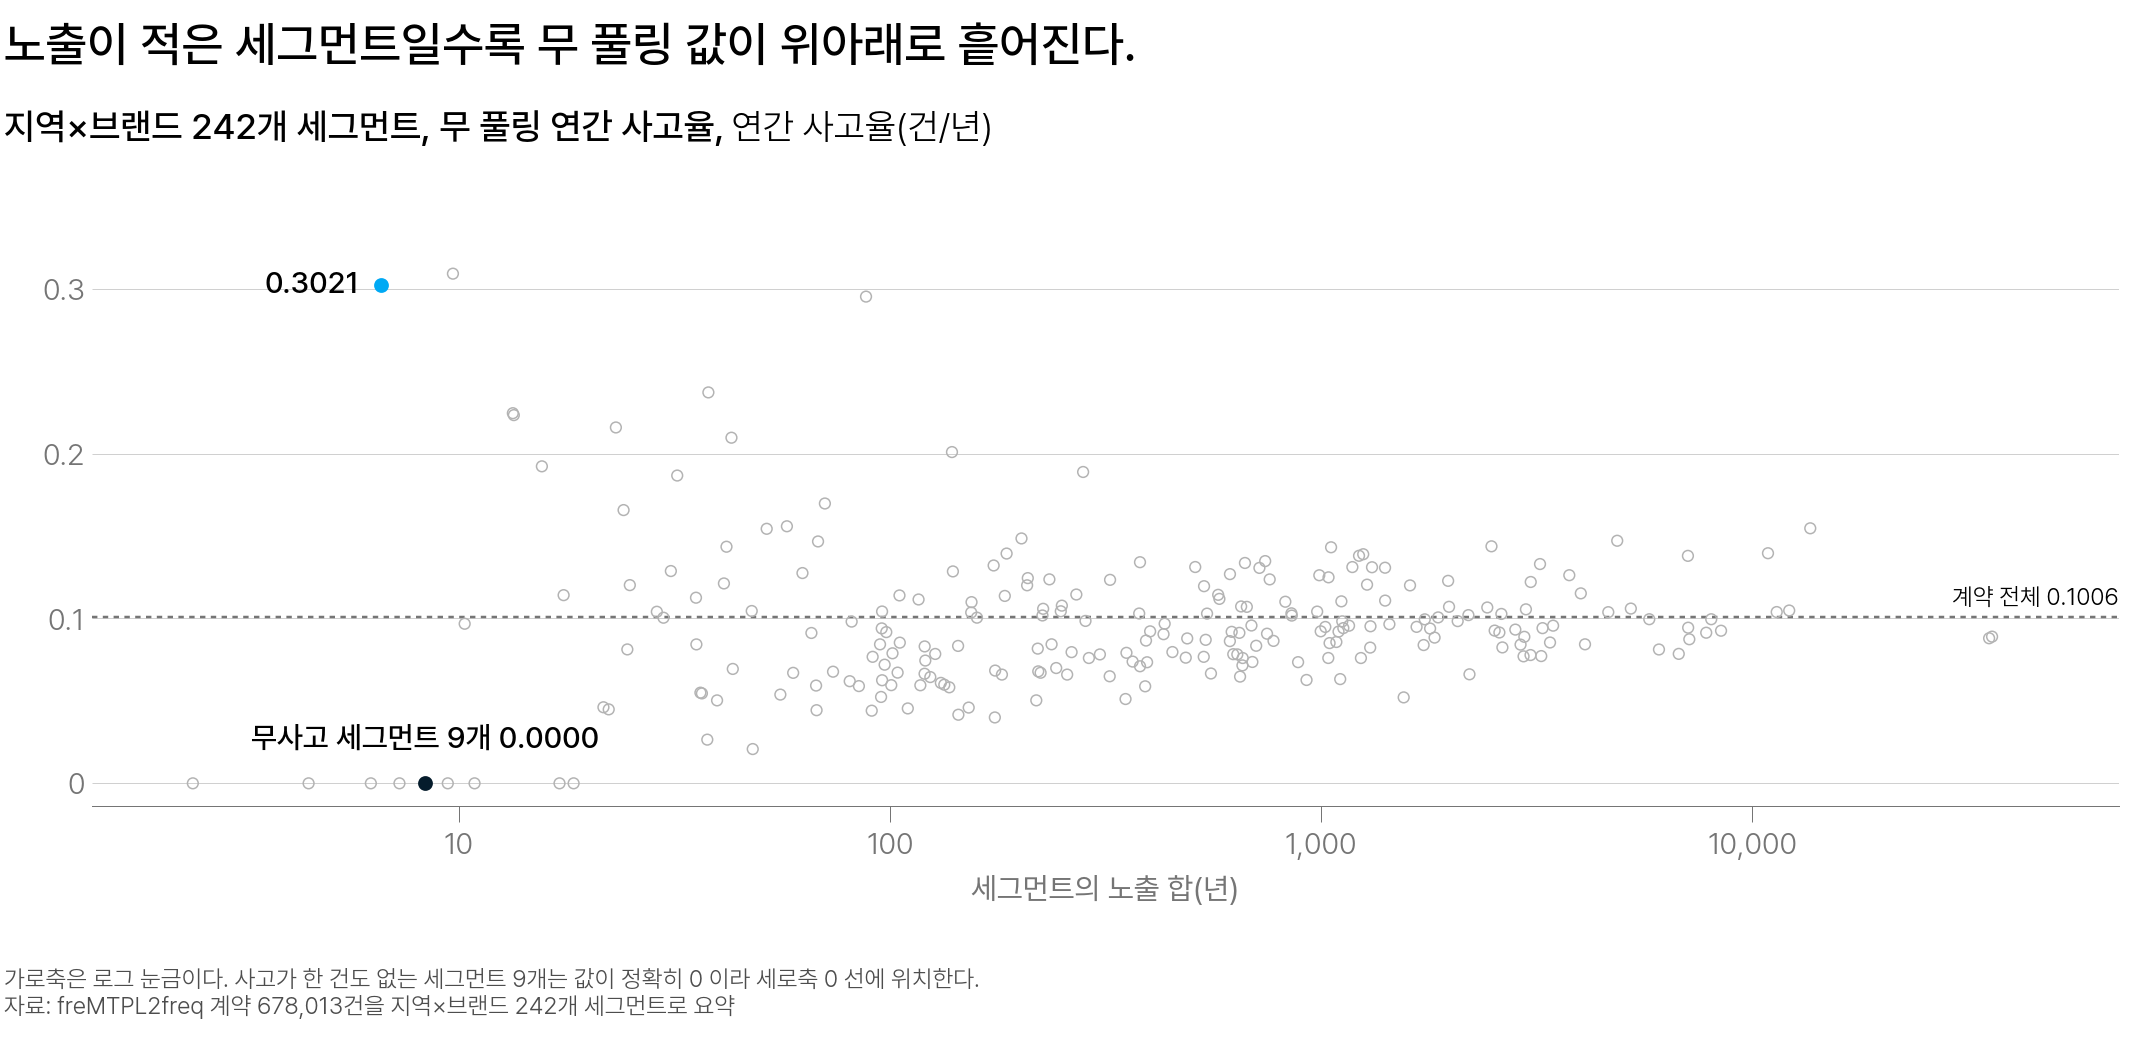

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 지역×브랜드 242개 세그먼트의 무 풀링 연간 사고율 — 가로축이 오른쪽으로 갈수록 노출이 많은 세그먼트이고, 하늘색 점이 노출 6.62년 세그먼트이고, 세로축 0 선에 위치한 점들이 사고 0건인 세그먼트 9개이고 그중 노출이 중앙값인 세그먼트 1개를 남색으로 표시했다 — 노출이 적은 쪽에서는 값이 0 과 0.30 사이에 고르게 흩어진다.</em></p>

이 방식이 실제 데이터에서 계산한 값 3개입니다. 셋 다 연간 사고율입니다.

- **0.3021** — 노출 6.62년 세그먼트이고, 계약 전체의 값 0.1006 의 **3배**입니다.
- **0.0890** — 노출이 가장 많은 세그먼트이고, 무 풀링으로도 계약 전체의 값에 가까운 안정된 값입니다.
- **0.0000** — 사고가 한 건도 없는 세그먼트 9개입니다.

#### 왜 노출이 적은 세그먼트에서 값이 크게 달라지는가

노출 6.62년 세그먼트에서 사고가 1건이었다면 0.1510, 0건이었다면 0.0000 입니다.

무사고 세그먼트 9개의 0.0000 은 「이 세그먼트는 사고가 나지 않는다」가 아니라 「관측 기간에 사고를 겪은 계약이 한 건도 없었다」는 뜻입니다. 그 9개의 노출 합 중앙값은 **8.37년**이고 242개 세그먼트 전체의 중앙값은 **380.2년**이라 관측 기간 자체가 적습니다. 분자가 0 이면 분모가 8년이든 800년이든 값은 똑같이 0 입니다.

극단 두 경우로 정리합니다.

- **노출이 아주 적으면** 사고 1건이 값을 0.1510 움직입니다. 같은 세그먼트의 답이 0 이 되기도 하고 계약 전체의 3배가 되기도 합니다.
- **노출이 아주 많으면** 사고 1건이 값을 0.00003 움직입니다. 노출 35,949년 세그먼트의 0.0890 은 그래서 안정된 값입니다.

#### 왜 완전 풀링으로 바꾸어도 해결되지 않는가

완전 풀링은 연간 사고율 0.1006 건/년을 242개 세그먼트에 똑같이 적습니다.

노출 합이 13,619년인 세그먼트가 있습니다. 노출이 많아 무 풀링 값이 안정되어 있고, 그 값이 0.1547 건/년입니다. 완전 풀링은 여기에도 0.1006 을 적습니다.

두 방식을 표로 대조합니다.

| | 무 풀링 | 완전 풀링 |
|---|---|---|
| 세그먼트마다 값이 | 다르다 | 같다 |
| 관측이 적은 세그먼트에서 | 위아래로 흩어진다 | 흩어지지 않는다 |
| 관측이 많은 세그먼트에서 | 그 세그먼트의 값을 계산한다 | 그 세그먼트의 값을 계산하지 못한다 |
| 무사고 세그먼트에 | 0 을 부여한다 | 계약 전체의 값을 부여한다 |
| 쓰는 정보 | 그 세그먼트뿐 | 계약 전체를 하나로 평균한 값 |

세 번째 행과 네 번째 행은 서로 반대 방향입니다. 둘 중 하나를 고르면 어느 한쪽이 늘 손해입니다.

**그래서** 무 풀링의 문제는 값이 틀렸다는 것이 아니라 **그 세그먼트의 데이터가 답을 정하기에 너무 적다**는 것입니다. 무 풀링에는 그 사실을 반영할 항이 없습니다. 그러면 관측량에 따라 두 극단 사이에서 저절로 달라지는 방식을 어떻게 적을 수 있는지가 다음 질문입니다.

> **무 풀링은 세그먼트마다 다른 값을 주지만, 노출이 적은 세그먼트에서는 그 값을 정할 정보가 그 세그먼트 안에 없습니다.**

> **[문제] 관측이 적은 세그먼트에서도 무 풀링 값이 크게 달라지지 않게 하려면 표준오차 공식을 더 정확한 것으로 바꾸면 된다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 2. 부분 풀링과 계층 모형

**여기서 할 일**

1. 세그먼트마다 값을 따로 두면서 서로 묶는 모형을 어떻게 적는지 확인합니다.
2. 세그먼트 3개 예시로 두 극단 사이의 값을 직접 계산합니다.
3. 층 3개로 적은 모형을 식 3개로 옮기고 그 안의 $\tau$ 를 정의합니다.

**여기서 다루는 값** — 앞 주제와 같습니다.

**부분 풀링(partial pooling)** 은 세그먼트마다 값을 따로 두고 그 값들이 하나의 공통 분포를 따른다고 적어, 추정값이 계약 전체의 값 쪽으로 수축되게 하는 방식입니다. 이렇게 층을 나누어 적은 모형을 **계층 모형(hierarchical model)** 이라 부릅니다. 위층에 모든 세그먼트가 함께 쓰는 값 하나를 두고, 가운데에 세그먼트마다 다른 편차를 두고, 아래에 관측한 사고 건수를 두는 방식입니다. 방식 3개는 이렇습니다.

- **무 풀링**은 그 세그먼트의 관측값을 그대로 씁니다.
- **완전 풀링**은 모든 세그먼트에 계약 전체의 값 하나를 씁니다.
- **부분 풀링**은 두 값을 가중평균해 그 사이의 값을 씁니다.

계약 전체의 값이 0.10 건/년이고 세그먼트 3개의 노출과 사고 건수가 아래와 같습니다. 손으로 따라가 보려고 만든 예시 세그먼트 3개입니다. 사전분포(데이터를 보기 전에 미리 그려 둔 분포)가 관측 몇 년치에 해당하는지를 나타내는 수를 **가상 노출**이라 부르고, 여기서는 가상 노출을 400년으로 둡니다. 이 400 이 어디서 나오는 값인지는 3번 주제에서 데이터로 역산합니다.

| 세그먼트 | 노출 $E$(년) | 사고 $y$(건) | 무 풀링 $y/E$ | 완전 풀링 | 부분 풀링 |
|---|---:|---:|---:|---:|---:|
| A | 5 | 2 | 0.400 | 0.100 | 0.104 |
| B | 50 | 6 | 0.120 | 0.100 | 0.102 |
| C | 5,000 | 450 | 0.090 | 0.100 | 0.091 |

부분 풀링 열은 말로 적으면 이렇습니다.

부분 풀링값 = (자기 노출 × 무 풀링값 + 가상 노출 × 완전 풀링값) ÷ 자기 노출과 가상 노출의 합

A 를 대입해 보겠습니다. A 의 노출은 5년이고 사전분포의 가상 노출은 400년입니다. $(5 \times 0.400 + 400 \times 0.100) \div 405 = 0.1037$ 이라, 무 풀링의 0.400 과 완전 풀링의 0.100 사이인 0.104 를 적습니다.

- 가상 노출이 0 이면 그 세그먼트의 무 풀링 값을 그대로 씁니다.
- 가상 노출이 아주 크면 모든 세그먼트가 완전 풀링 값을 씁니다.

같은 계산을 C 에 적용하면 노출이 5,000년이라 0.091 이 되어 무 풀링 값 0.090 을 거의 그대로 유지합니다. 세그먼트 3개에 **같은 규칙**을 적용했는데 이동한 거리가 다릅니다.

층 3개를 그림으로 보면 이렇습니다. 상자에 적힌 $\mu$ 는 모든 세그먼트가 함께 쓰는 값 하나이고, $\theta_j$ 는 세그먼트 $j$ 의 값이 그 값과 차이 나는 크기이며, $\tau$ 는 그 차이들의 표준편차입니다. 셋의 자세한 정의는 그림 뒤에 이어집니다.

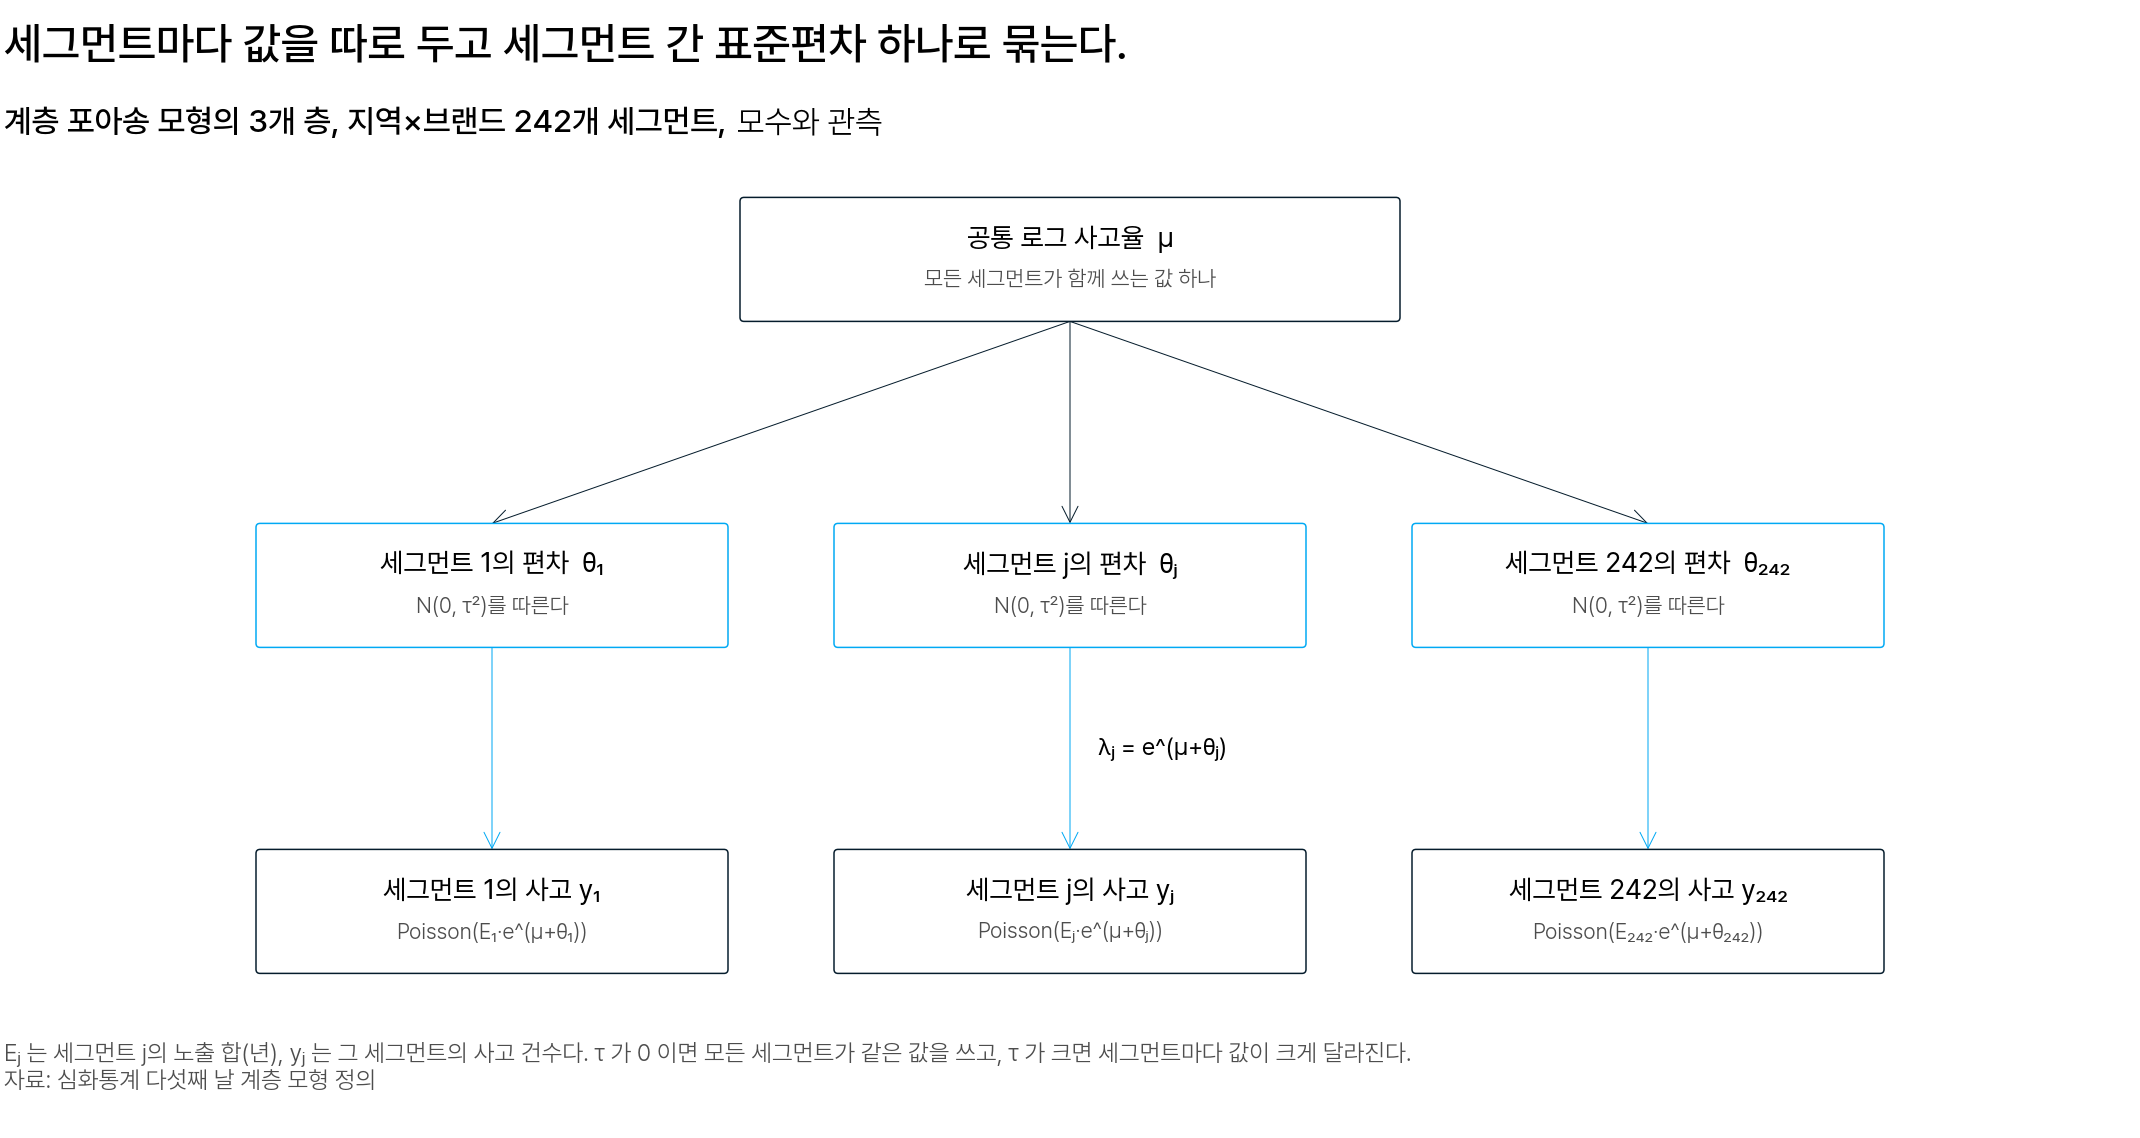

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계층 포아송 모형의 3개 층 — 맨 위 로그 사고율 μ 는 모든 세그먼트가 함께 쓰고, 가운데 θ 는 세그먼트마다 다르지만 같은 표준편차의 정규분포 N(0, τ²) 안에서만 움직이며, 맨 아래에서 관측 y 가 나온다 — 우리가 정하는 것은 이 구조와 μ·τ 에 얹는 넓은 사전분포이고 표준편차 τ 의 값은 데이터가 정한다.</em></p>

맨 위의 $\mu$ 하나를 242개 세그먼트가 함께 쓰고, 편차 $\theta_j$ 만 세그먼트마다 다릅니다. 상자에 적혀 있는 $N(0,\ \tau^2)$ 의 $\tau$ 가 오늘 추정할 핵심 모수입니다.

242개 세그먼트에 적용하려면 이 층 3개를 식으로 적습니다.

$$
\theta_j \sim N(0,\ \tau^2)
$$

$$
\lambda_j = e^{\mu + \theta_j}
$$

$$
y_j \sim \mathrm{Poisson}(E_j\, \lambda_j)
$$

- $\sim$ : 왼쪽 값이 오른쪽 분포를 따른다는 뜻입니다. $N(0,\ \tau^2)$ 은 평균 0 인 정규분포이고, 괄호 안의 둘째 수는 표준편차 $\tau$ 의 제곱인 분산입니다.
- $y_j$ : 세그먼트 $j$ 의 사고 건수입니다. 우리가 관측한 값입니다.
- $E_j$ : 세그먼트 $j$ 의 노출 합(년)입니다. 그 세그먼트에 누적된 관측량입니다.
- $\mu$ : 그림의 공통 로그 사고율 $\mu$ 입니다. 모든 세그먼트에 공통인 평균이고, 로그로 옮겨 적은 좌표 곧 로그 스케일의 값입니다. $\mu = -2.30$ 이면 $e^{-2.30} = 0.1003$ 이라 표의 완전 풀링 열에 적힌 값이 됩니다.
- $\theta_j$ : 세그먼트 편차입니다. 세그먼트 $j$ 의 값이 공통 평균과 차이 나는 크기이고, 0 이면 그 세그먼트가 계약 전체와 같습니다. $\theta_j = 0.693$ 이면 $e^{0.693} = 2.00$ 이라 공통 평균의 사고율 $e^{\mu}$ 의 2배이고, $-0.693$ 이면 $e^{-0.693} = 0.50$ 이라 그 절반입니다.
- $\lambda_j$ : 세그먼트 $j$ 의 연간 사고율(건/년)입니다.
- $\tau$ : 세그먼트 간 표준편차, 곧 세그먼트 편차 $\theta_j$ 들의 표준편차입니다.

이 식 3개를 말로 옮기면 이렇습니다.

- 세그먼트 편차 $\theta_j$ 는 대부분 0 부근에 있고, 0 에서 떨어진 크기는 $\tau$ 하나가 정합니다.
- 세그먼트의 연간 사고율 $\lambda_j$ 는 공통 평균에 그 세그먼트의 편차를 더해 정해집니다.
- 사고 건수 $y_j$ 는 기대 사고 건수 $E_j \lambda_j$ 를 평균으로 하는 포아송분포를 따릅니다.

$\tau$ 에도 작은 수를 대입해 보겠습니다. $\tau = 0.1$ 이면 세그먼트 편차 $\theta_j$ 의 약 68%가 $-0.1$ 과 $0.1$ 사이에 놓입니다. 이 구간을 사고율로 옮기면 $e^{-0.1} = 0.905$, $e^{0.1} = 1.105$ 라 공통 평균의 사고율 $e^{\mu}$ 를 기준으로 0.905배에서 1.105배 안입니다.

$\tau = 1$ 이면 같은 구간이 $e^{-1} = 0.368$ 에서 $e^{1} = 2.718$ 로 넓어져, $e^{\mu}$ 를 기준으로 0.368배에서 2.718배 사이가 됩니다.

앞의 A 를 이 식 3개에 대입해 보겠습니다. A 는 $E_A$ 가 5년이고 $y_A$ 가 2건입니다. $\theta_A$ 가 0 이면 $\lambda_A$ 가 $e^{\mu}$ 라 위에서 본 0.1003, 곧 표의 완전 풀링 열 값입니다. 표의 부분 풀링 열에 적힌 0.104 는 $\theta_A$ 가 0.034 일 때의 값이고, $e^{-2.30 + 0.034} = 0.1037$ 이라 반올림하면 0.104 입니다.

$\theta_A$ 가 0 일 때 맨 아래 식의 기대 사고 건수는 $E_A \lambda_A = 5 \times 0.1003 = 0.50$ 건이고, 실제 관측한 사고는 2건입니다.

표의 부분 풀링 열은 이 모형이 주는 수축을 가중평균으로 근사해 계산한 값입니다. 모형이 정하는 값을 그대로 구하려면 사후분포가 필요하고, 그 계산은 4번 주제에서 다룹니다.

$\mu$ 와 $\tau$ 에도 사전분포를 지정합니다. 오늘은 어느 값 쪽으로도 치우치지 않도록 넓게 둡니다. 넓게 둔다는 것은 어느 값도 배제하지 않는다는 뜻이라, 실제로 두 값이 얼마가 될지는 데이터가 정합니다.

#### 왜 편차를 더한 뒤 지수를 취하는가

$\mu$ 가 로그 스케일의 값이라 지수를 취해야 연간 사고율이 됩니다. $e^{x}$ 는 어떤 수를 대입해도 0 보다 큰 값을 반환하는 지수함수라, 편차를 더해도 사고율이 음수가 되지 않습니다.

$e^{\mu + \theta_j} = e^{\mu} \times e^{\theta_j}$ 라, 편차를 더하는 것은 공통 평균의 사고율에 배수를 곱하는 것과 같습니다. 위에서 $\theta_j = 0.693$ 이 2배가 된 것도 이 성질입니다.

#### 왜 τ 하나로 방식 3개가 갈리는가

- $\tau = 0$ 이면 모든 $\theta_j$ 가 0 이라 세그먼트가 전부 같은 값을 씁니다. 표의 완전 풀링 열이 그 경우입니다. **완전 풀링**입니다.
- $\tau$ 가 아주 크면 $\theta_j$ 가 제한 없이 달라져 세그먼트끼리 아무 관계가 없습니다. 표의 무 풀링 열처럼 A 는 0.400, C 는 0.090 을 그대로 씁니다. **무 풀링**입니다.
- 그 사이면 세그먼트마다 값이 다르지만 공통 평균에서 멀리 벗어나지는 못합니다. **부분 풀링**입니다.

앞 표에서 쓴 가상 노출은 $\tau$ 가 주는 수축을 노출년으로 옮긴 근사값이고, $\tau$ 가 작을수록 가상 노출이 커집니다.

**그래서** 우리가 지정하는 것은 층 3개의 구조와 $\mu$·$\tau$ 에 얹는 넓은 사전분포이고, 수축의 크기를 정하는 $\tau$ 의 값은 데이터가 정합니다. 그러면 같은 $\tau$ 하나가 노출 5년 세그먼트와 노출 5,000년 세그먼트에 어떻게 다른 크기의 이동을 주는지가 다음 질문입니다.

**한 문장으로** 적으면, 계층 모형은 세그먼트마다 값을 하나씩 두고 그 값들의 표준편차 $\tau$ 로 묶어, 완전 풀링과 무 풀링 사이 어디에 놓일지를 데이터가 정하게 하는 모형입니다.

> **[문제] τ 가 0 에 가까울 때와 클 때 요율표가 어떻게 달라지는가**
>
> 계층 모형의 가운데 층은 $\theta_j \sim N(0,\ \tau^2)$ 입니다. 같은 데이터에서 $\tau$ 가 0.01 로 추정된 경우와 2.0 으로 추정된 경우, 지역×브랜드 242개 세그먼트의 요율표가 각각 어떤 모양이 되는지 두 문장으로 적어 보세요.

## 3. 수축의 크기를 정하는 값: 노출

**여기서 할 일**

1. 노출 6.62년 세그먼트의 추정값이 계약 전체의 값 쪽으로 얼마나 이동하는지 읽습니다.
2. 이동한 크기를 노출이 정한다는 사실을 242개 세그먼트에서 확인합니다.
3. 노출이 가장 적은 세그먼트와 가장 많은 세그먼트의 가중치를 대조합니다.

**여기서 다루는 값** — 앞 주제와 같습니다. 연간 사고율 $\lambda$(단위: 건/년), 지역×브랜드 242개 세그먼트입니다. 여기서 함께 쓰는 노출 $E$ 는 1번 주제에서 정의한 대로 계약이 실제로 보장을 받은 기간의 합이고 단위는 년입니다.

**수축(shrinkage)** 은 세그먼트별 추정값이 계약 전체의 값 쪽으로 이동하는 현상입니다. 이동한 크기는 **수축의 크기**라 부릅니다. 얼마나 이동하는지는 그 세그먼트에 누적된 관측량이 정합니다.

바로 앞에서 세그먼트 간 표준편차 $\tau$ 하나가 모든 세그먼트에 공통으로 적용된다고 적었습니다. 그렇다면 노출 6.62년 세그먼트와 노출 35,949년 세그먼트가 같은 크기로 이동해야 할 것 같습니다.

그러면 관측이 많은 세그먼트에서도 세그먼트별 값이 사라집니다. 실제로는 그렇지 않습니다.

> **[예측] 노출 6.62년에 사고 2건인 세그먼트(무 풀링 0.3021 건/년)에 부분 풀링을 쓰면 값이 얼마가 될까요? 계약 전체의 값은 0.1006 건/년입니다.**
>
> 1. 0.3021 그대로 — 그 세그먼트의 데이터가 이미 답을 정했다
> 2. 약 0.2000 — 무 풀링과 계약 전체의 값 가운데쯤까지 수축한다
> 3. 약 0.1040 — 계약 전체의 값에 거의 근접할 만큼 수축한다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

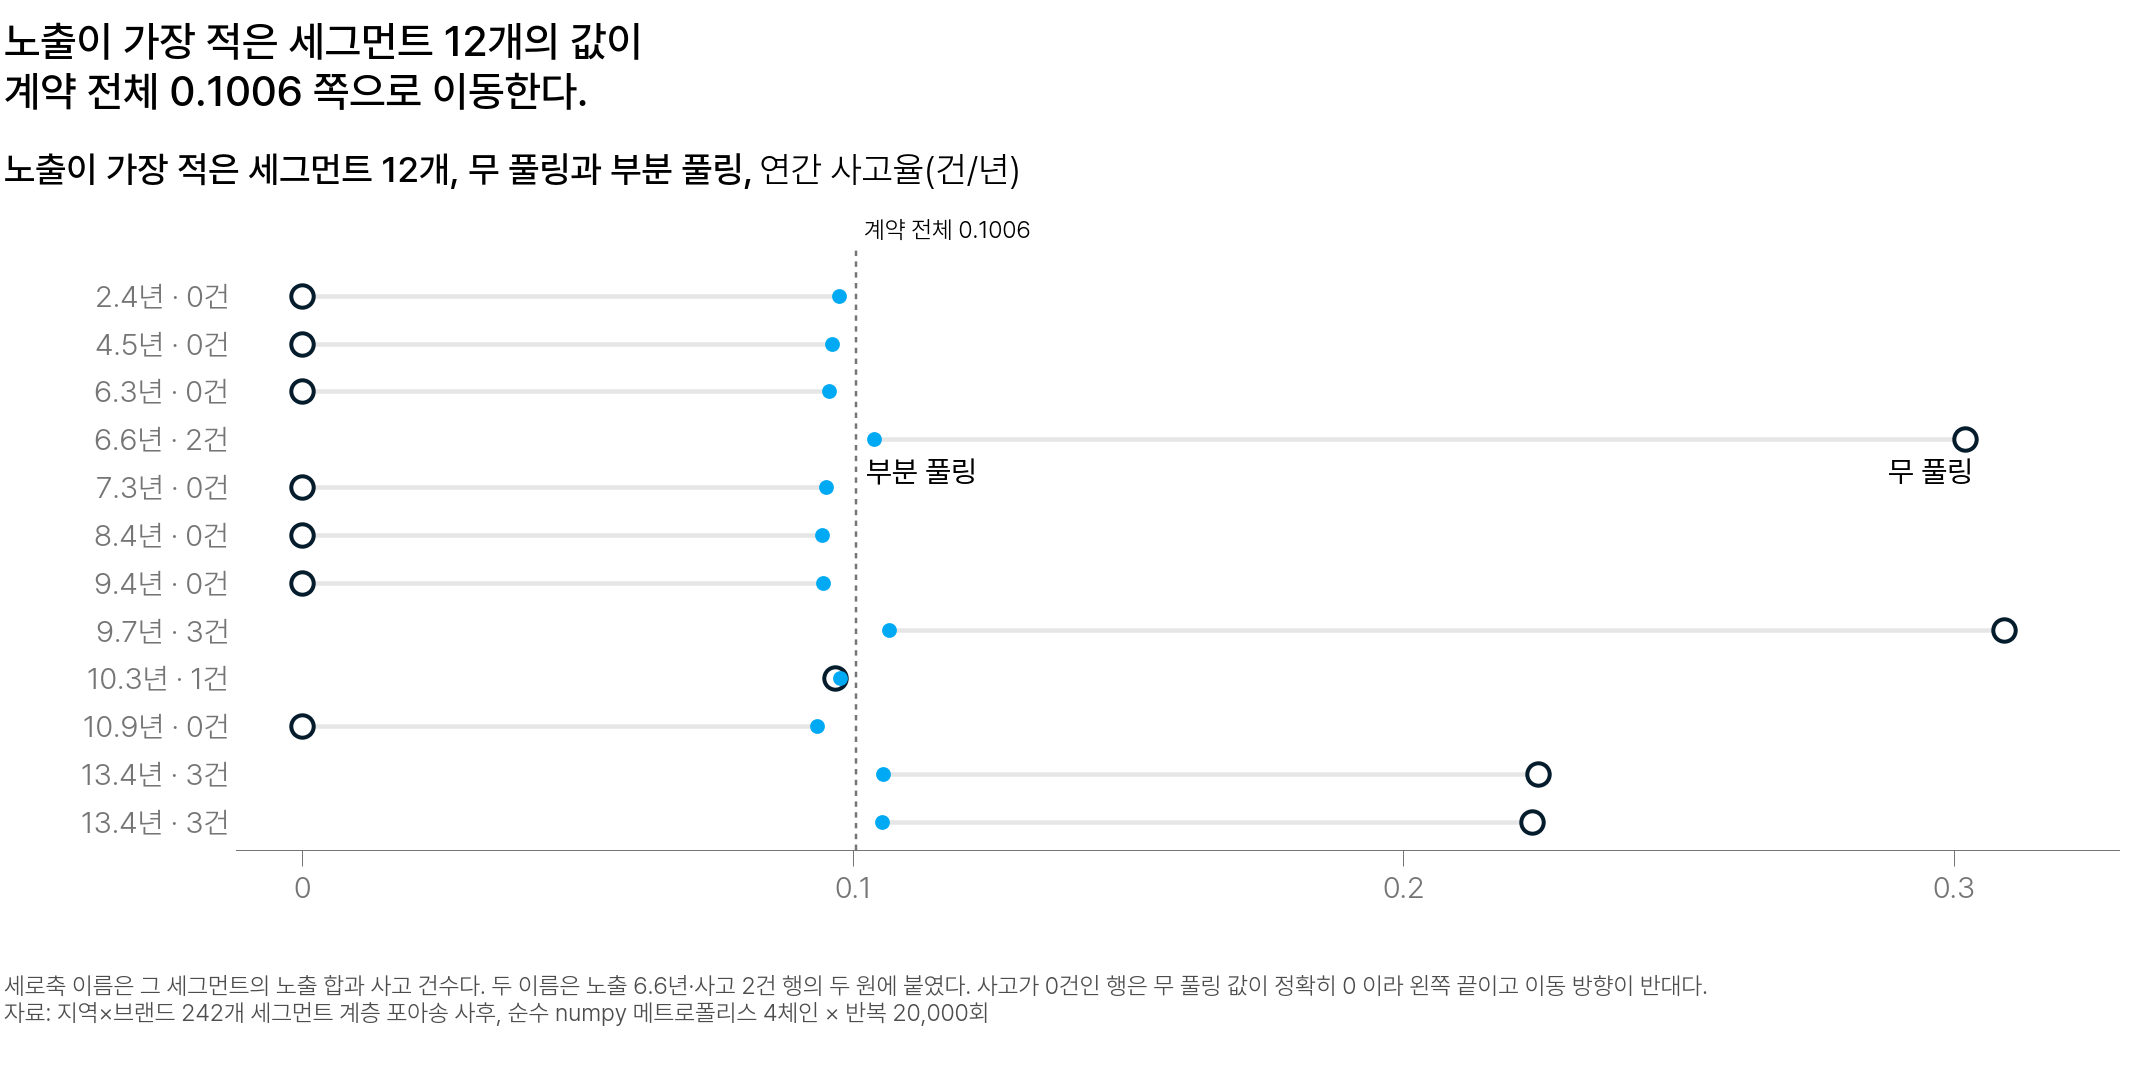

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 노출이 가장 적은 세그먼트 12개의 이동 — 속 빈 원이 무 풀링, 채운 하늘색 원이 부분 풀링이고 회색 점선이 계약 전체의 연간 사고율 0.1006 건/년이다 — 사고 0건 세그먼트는 왼쪽 끝에서 오른쪽으로 증가하고 0.3021 세그먼트는 오른쪽 끝에서 왼쪽으로 감소해 양쪽이 계약 전체 0.1006 에 근접한다.</em></p>

노출 6.62년 세그먼트가 0.3021 에서 **0.1038** 로 감소해 계약 전체의 값에 거의 근접했습니다. 사고 0건 세그먼트는 0.0000 에서 0.09 대로 증가해 양쪽이 계약 전체의 값 쪽으로 이동했습니다. 이 0.1038 은 아래에 적는 가중평균 식으로 계산한 값이 아니라 계층 모형이 계산한 값이고, 그 계산 방법은 4번 주제에서 다룹니다.

이동한 거리를 일반식으로 적으면 가중평균입니다. 말로 먼저 적으면 이렇습니다.

부분 풀링값 = 무 풀링값 × 가중치 + 계약 전체의 값 × (1 − 가중치)

가중치 = 그 세그먼트의 노출 ÷ (그 세그먼트의 노출 + 가상 노출)

기호로 옮기면 이렇습니다.

$$
\hat{\lambda}_j \approx w_j \times \frac{y_j}{E_j} + (1 - w_j) \times \lambda^{\text{계약 전체}}, \qquad w_j = \frac{E_j}{E_j + B}
$$

- $\hat{\lambda}_j$ : 세그먼트 $j$ 에 최종으로 적는 부분 풀링 값입니다. 모자는 1번 주제와 같은 추정값 표시입니다.
- $w_j$ : 그 세그먼트의 데이터에 주는 가중치입니다. 0 이면 계약 전체의 값만 쓰고 1 이면 그 세그먼트의 값만 씁니다.
- $y_j/E_j$ : 그 세그먼트의 무 풀링 값입니다.
- $\lambda^{\text{계약 전체}}$ : 계약 678,013건 전체로 계산한 값 0.1006 건/년입니다.
- $E_j$ : 그 세그먼트의 노출 합(년)입니다. 노출이 많을수록 가중치가 커집니다.
- $B$ : 사전분포가 가진 가상 노출(년)입니다. 세그먼트 간 표준편차 $\tau$ 가 작을수록 커지고 클수록 작아집니다.

작은 수를 대입해 봅니다. $B$ 가 100년이고 그 세그먼트의 노출도 100년이면 $w = 100 \div 200 = 0.5$ 라 두 값을 절반씩 씁니다.

이는 다음 뜻입니다.

- 가중치 $w_j$ 는 노출 $E_j$ 가 많을수록 1 에 가까워집니다.
- 추정값은 무 풀링 값과 계약 전체의 값을 잇는 선분 위의 한 점이고, 그 위치를 $w_j$ 가 정합니다.

$B$ 는 사람이 지정하는 수가 아니라 계층 모형이 그 세그먼트에 준 값(그림의 0.1038)에서 역산하는 수입니다. 가중치는 부분 풀링 값이 계약 전체의 값에서 아직 떨어져 있는 거리를 무 풀링 값과 계약 전체의 값 사이의 전체 거리로 나눈 비입니다. 그림에 나온 0.3021 과 0.1038 과 계약 전체의 0.1006 을 대입하면 이렇습니다.

$$
w = \frac{0.1038 - 0.1006}{0.3021 - 0.1006} = 0.016
$$

그 가중치와 노출 6.62년에서 역산하면 가상 노출이 **약 400년**입니다. 2번 주제에서 미리 400년으로 둔 그 수를 여기서 데이터로 확인한 것입니다.

<details class="lms-extra"><summary>더 깊이 — 가중치에서 약 400년으로 가는 역산</summary>

본문의 가중치는 위 가중평균 식을 $w$ 에 대해 푼 값입니다. 부분 풀링과 계약 전체의 차를 무 풀링과 계약 전체의 차로 나누면 나옵니다.

이 $w$ 를 $w = E/(E+B)$ 에 대입하고 $B$ 에 대해 풀면 $B$ 가 나옵니다.

$$
B = \frac{E\,(1 - w)}{w} = \frac{6.62 \times 0.984}{0.016}
$$

나눗셈을 계산하면 407 입니다. 이 값은 지금까지 따라온 노출 6.62년 세그먼트 하나에서 역산한 수이고, 242개 세그먼트가 함께 쓰는 수로 확인된 값은 아닙니다.

세그먼트를 바꾸어 역산하면 값이 조금이 아니라 몇 배씩 달라집니다. 위 그림의 12개만 같은 방식으로 역산해도 사고가 0건인 세그먼트 7개는 76년에서 147년 사이이고, 사고가 3건인 세그먼트 3개는 325년에서 331년 사이입니다. 가중평균이 계층 모형의 수축을 한 줄로 옮긴 근사식이라 그렇습니다. 본문은 따라온 세그먼트에서 나온 약 400년 하나로 적습니다.

</details>

#### 가상 노출 400년은 무슨 뜻인가

사전분포가 담은 정보량을 노출년으로 환산한 값이고, 이 정보량을 **사전 강도**라 부릅니다. 6번 주제에서는 같은 이름을 사고 경험률 모형의 가상 관측 건수로 다시 환산하므로, 여기의 단위는 년이고 6번 주제의 단위는 건입니다. 가상 노출이 400년이면 사전분포가 400년치 노출을 이미 본 것과 같습니다.

작은 수로 확인합니다. 앞 주제의 노출 5년 세그먼트는 가중치가 $5 \div 405 = 0.012$ 라 자기 데이터가 1.2% 만 반영되고, 노출 5,000년 세그먼트는 $5{,}000 \div 5{,}400 = 0.926$ 이라 92.6% 가 반영됩니다.

- 노출이 가상 노출보다 훨씬 적으면 가중치가 0 에 가까워 계약 전체의 값을 씁니다. 사전 강도가 무한이면 그 끝이 완전 풀링입니다.
- 노출이 가상 노출보다 훨씬 많으면 가중치가 1 에 가까워 자기 값을 씁니다. 사전 강도가 0 이면 그 끝이 무 풀링입니다.

둘째 날 Beta(6, 96) 은 가상 관측 102건(6 + 96)을 미리 얹은 사전분포이고, 그 모수를 사람이 지정해 사후분포를 공식으로 바로 푼 계산입니다. 이 계산에서 강도는 사람이 지정한 수입니다. 그래서 그 계산은 완전 풀링이 아니라 수축의 세기를 사람이 지정한 계산입니다. 다만 수축이 향하는 중심도 사람이 지정한 값이라, 계약 전체의 값 쪽으로 수축하는 부분 풀링과는 그 점이 다릅니다.

#### 무엇을 데이터가 정하고 무엇을 사람이 지정하는가

추정할 모수 $\lambda_j$ 는 데이터가 정합니다. 사전분포의 모수인 사전 강도와 중심은 사람이 지정하기도 하고 데이터가 정하기도 합니다. 사전분포를 정하는 일은 $\lambda_j$ 를 정하는 일이 아니라 $\lambda_j$ 가 어디쯤일지 미리 그려 두는 일입니다. 사전분포를 얹는다는 것은 그 세그먼트의 관측에 가상 관측을 더해 계산한다는 뜻입니다.

| 방식 | 얹는 가상 데이터 | 세그먼트마다 얹는 양 | 세그먼트마다 다른 것 |
|---|---|---|---|
| 무 풀링 | 없음 | 해당 없음 | 자기 값 그대로 |
| 사람이 지정한 사전분포 | 유한, 사람이 지정 | 가상 노출 하나, 세그먼트마다 같음 | 이동 거리, 자기 노출에 따라 |
| 계층(데이터가 추정) | 유한, 데이터가 추정 | 가상 노출 하나, 세그먼트마다 같음 | 이동 거리, 자기 노출에 따라 |
| 완전 풀링 | 무한 | 해당 없음 | 없음, 모두 같은 값 |

가운데 두 행이 부분 풀링입니다. 두 방식의 차이는 얹는 양이 같은가 다른가가 아니라, 그 한 가지 양을 사람이 지정하는가 데이터가 정하는가입니다.

#### 왜 세그먼트마다 이동한 크기가 다른가

가중평균 식은 가상 노출 $B$ 를 242개 세그먼트에 같은 값으로 두고 노출 $E_j$ 만 세그먼트마다 다르게 둡니다. 약 400년을 노출 35,949년 세그먼트에 대입하면 가중치가 $35{,}949 \div 36{,}349 = 0.989$, 곧 **98.9%** 입니다. 같은 식으로 노출 6.62년 세그먼트의 가중치를 계산하면 1.6% 입니다.

무사고 세그먼트 9개를 뺀 233개 세그먼트에서 같은 규칙이 성립하는지 확인합니다.

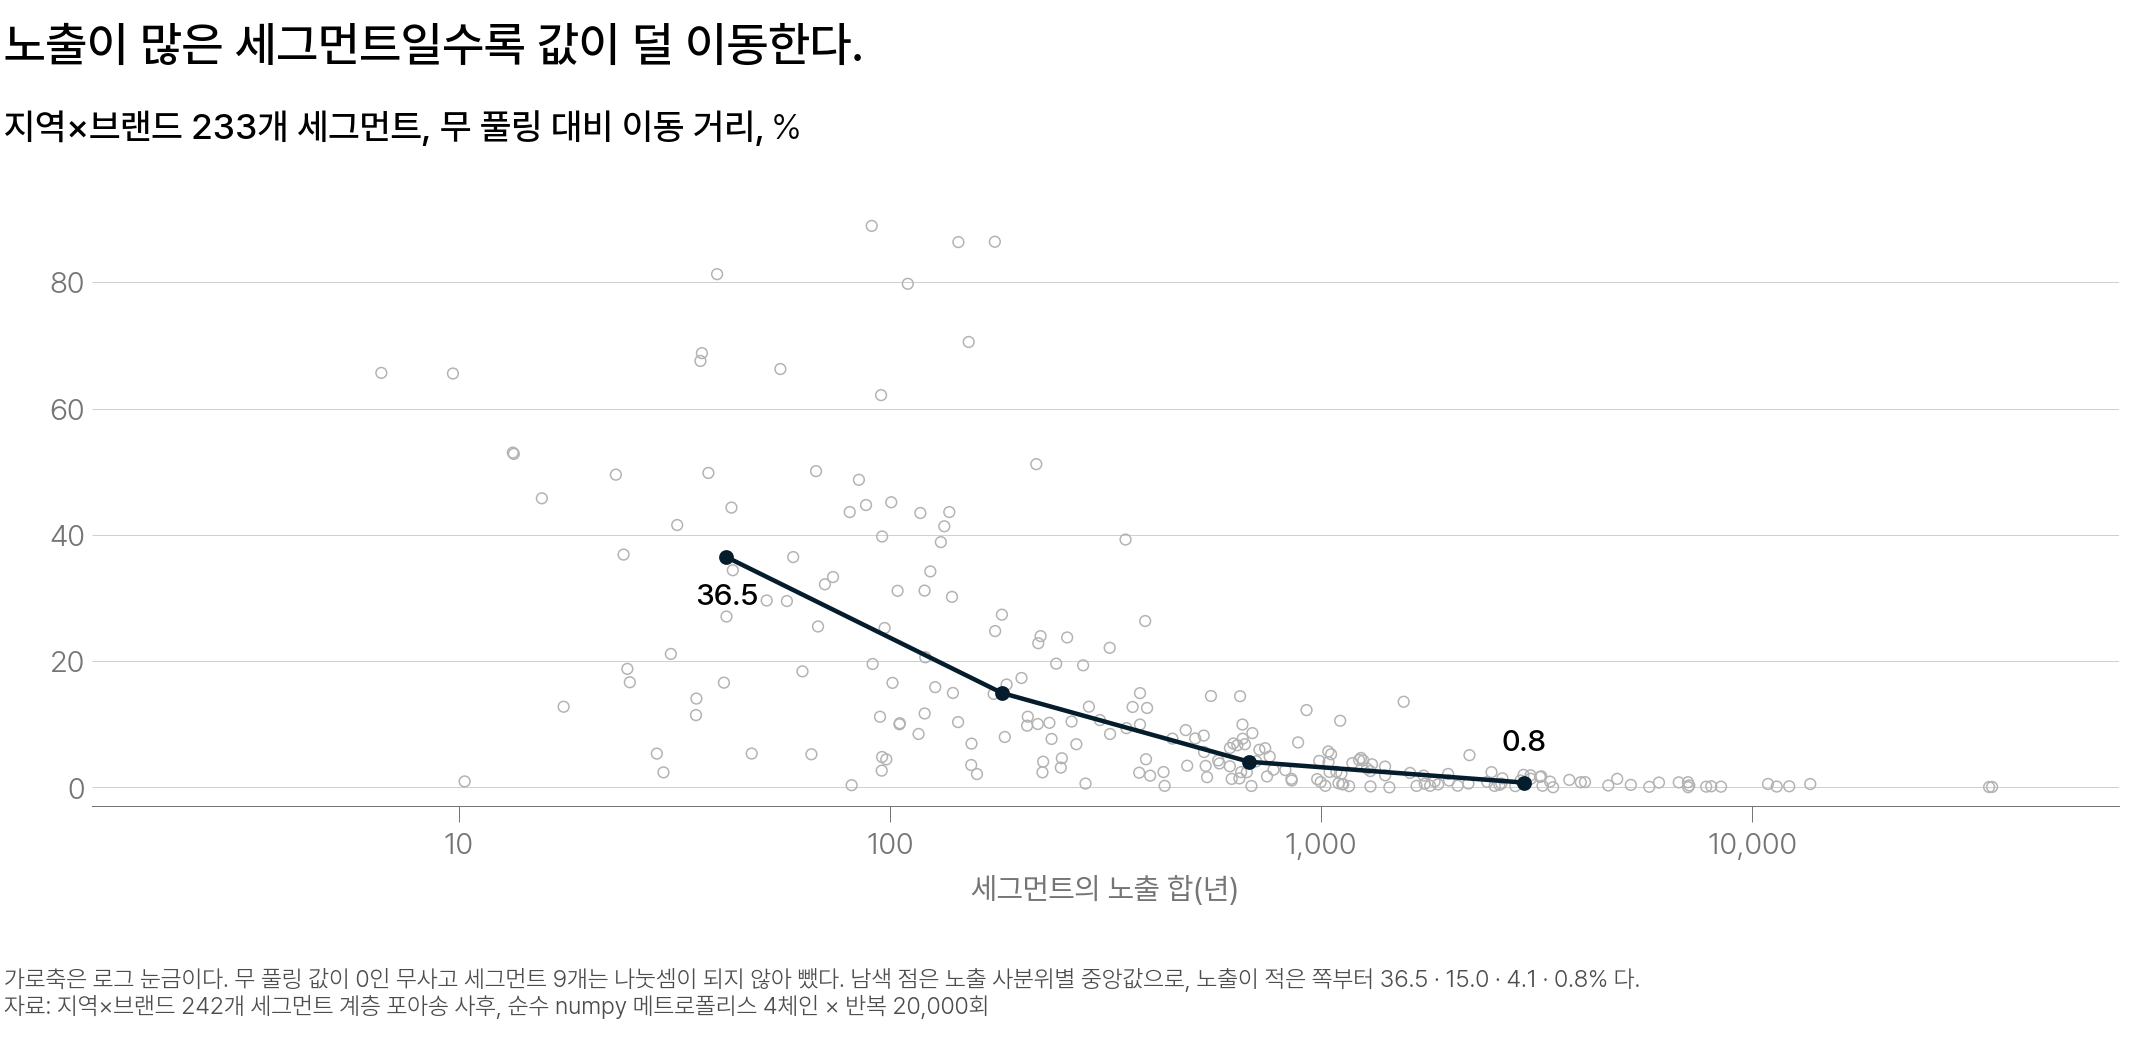

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 세그먼트의 노출 합과 값이 이동한 정도 — 회색 원이 세그먼트 하나이고 남색 선이 노출 사분위별 중앙값이다 — 노출이 10배로 증가할 때마다 이동한 정도가 뚜렷하게 감소해 노출이 가장 많은 사분위에서는 0.8% 만 이동한다.</em></p>

노출 순으로 4등분한 묶음 가운데 노출이 가장 적은 사분위는 무 풀링 값의 **36.5%** 만큼 이동하고, 노출이 가장 많은 사분위는 **0.8%** 만 이동합니다. **노출이 많은 세그먼트는 세그먼트별 차이를 잃지 않습니다.**

### [직접 해보기] 가상 노출을 바꾸면 수축의 크기가 어떻게 달라지는가

이 위젯은 둘째 날 「4. 실무 적용 — 자동차보험 데이터」에서 조작한 화면 그대로이고, 다루는 값도 여기와 같습니다. 화면 이름은 `사전 강도 β₀` 이지만 여기서 그 값은 단위가 년인 가상 노출입니다.

조작하기 전에 예측해 봅니다. β₀ 를 100 에서 400 으로 4배 늘리면 데이터 가중치 `w` 도 4분의 1 이 될까요. 답을 적어 둔 뒤 아래 순서대로 조작합니다.

1. **조작.** 위젯을 `사고 많음` 탭으로 두면 지금까지 다룬 노출 6.62년에 사고 2건인 세그먼트가 열립니다. `사전 강도 β₀` 슬라이더를 오른쪽으로 옮겨 값 표시란이 400 부근이 되게 합니다. 슬라이더 눈금이 한 칸씩 끊겨 있어 값 표시란에는 400 이 아니라 398 이 나옵니다.
2. **관찰.** 오른쪽 `수축 폭 |MLE − MAP|` 숫자와 그 아래 값 표시란이 함께 바뀝니다. 여기서 MLE 는 무 풀링 값이고 MAP 은 사후분포의 최빈값, 곧 수축된 추정값입니다. 화면의 `데이터의 발언권 w` 가 본문에서 말하는 데이터 가중치 $w$ 입니다. β₀ 가 100 일 때 MAP 은 0.113 이고, 400 부근(화면에 398)으로 옮기면 0.104 로 감소해 계층 모형이 계산한 부분 풀링 값에 근접합니다.
3. **확인 질문.** β₀ 가 100 일 때와 400 부근일 때의 $w$ 를 값 표시란에서 각각 읽어 적어 둔 예측과 대조합니다. 화면은 백분율 한 자리로 표시하므로 6.2% 와 1.6% 가 나옵니다. 4배 늘린 결과가 정확히 4분의 1 인지는 이 두 수만으로 갈리지 않으니, $w = E/(E+\beta_0)$ 식에 노출 6.62 를 직접 대입해 확인합니다. $6.62 \div (6.62 + 100) = 0.0621$ 이고 $6.62 \div (6.62 + 398) = 0.0164$ 인데, 0.0621 의 4분의 1 은 0.0155 라 실제 값이 그보다 조금 큽니다. 분모에 노출 6.62 가 함께 들어 있어 그렇습니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/map-shrink-lab.html", width=980, height=520)

#### 핵심 주의점

수축을 「값을 아래로 깎는 보정」으로 읽으면 안 됩니다. 가중평균이 산출하는 값은 그 세그먼트의 값과 계약 전체의 값을 잇는 선분 위의 한 점입니다.

> **계약 전체보다 낮은 세그먼트는 증가하는 쪽으로, 높은 세그먼트는 감소하는 쪽으로 움직입니다.**

**그래서** 부분 풀링은 무 풀링과 완전 풀링을 반씩 결합하는 방식이 아닙니다. **세그먼트마다 다른 비율로 결합하고 그 비율을 노출이 정합니다.**

**한 문장으로** 적으면, 수축의 크기를 정하는 것은 노출 하나가 아니라 그 세그먼트의 노출과 사전 강도 400년의 비입니다.

그러면 그 비율을 정하는 $B$ 를, 곧 $\tau$ 를 어떻게 계산하는지가 남습니다. 6번 주제는 같은 성격의 환산을 사고 경험률 모형에서 가상 관측 건수로 다루고, 400년과 300건은 단위가 달라 곧장 대조하지 않습니다.

$\tau$ 의 답은 사후분포에 있습니다. 그런데 그 사후분포를 식으로 적을 수 없다는 점이 다음 문제입니다.

> **[문제] 계층 모형이 관측이 많은 세그먼트의 추정값도 왜곡하는가**
>
> 지역×브랜드 242개 세그먼트 중 노출이 35,949년으로 가장 많은 세그먼트는 무 풀링 값이 0.0890 이고 부분 풀링 값이 0.0891 입니다. 본문의 가중평균 식 $w_j = E_j/(E_j + B)$ 에 이 세그먼트의 노출과 $B = 400$ 을 대입해 가중치를 계산하고, 그 값으로 「부분 풀링은 관측이 많은 세그먼트의 세그먼트별 차이까지 지운다」는 걱정에 한 문장으로 답해 보세요.

## 4. MCMC: 사후분포를 식으로 적을 수 없을 때 표본으로 얻는 방법

**여기서 할 일**

1. 요율표에 적을 값을 좁히고, 그 값을 얻는 방법 3개를 표로 대조합니다.
2. 앞의 두 방법이 계층 모형에서 각각 어디부터 막히는지 확인합니다.
3. 무작위 이동을 반복해 표본을 모으는 규칙을 확인하고, 공식으로 답을 아는 경우와 대조합니다.

**여기서 다루는 값** — 앞부분은 앞 주제와 같은 연간 사고율 $\lambda$(단위: 건/년), 지역×브랜드 242개 세그먼트입니다. 규칙을 연습하는 표·그림·코드·위젯만 사고 경험률 $p$(단위 없는 비율)와 계약 63건인 세그먼트 하나를 씁니다.

요율표를 채우려면 세그먼트마다 사후평균 하나와 95% 구간의 두 끝, 이렇게 세 수가 필요합니다. 곡선의 식이 아닙니다. 그 가운데 무엇을 적는지는 뒤의 7번에서 정합니다.

이 세 수는 표본만 있으면 나옵니다. 사후평균은 표본의 평균이고, 95% 구간은 표본을 정렬해 2.5% 와 97.5% 에서 끊은 두 값입니다.

그러니 「사후분포를 얻는다」는 곡선의 식을 적는 일일 수도 있고, 곡선을 닮은 표본을 모으는 일일 수도 있습니다. 둘째 날 나열한 방법 3개를 그 기준으로 정리하면 이렇습니다. 셋째 열의 $Z$ 는 곡선 아래의 넓이를 1 로 맞추려고 나누는 수 하나이고, 바로 아래에서 숫자로 확인합니다.

| 방법 | 얻는 것 | $Z$ 가 필요한가 | 요약값은 어떻게 |
|---|---|---|---|
| 공식으로 풀기(켤레) | 사후분포의 이름과 식 | 필요 없습니다. 켤레 공식이 넓이 1 인 식을 바로 줍니다 | 식에 대입해 계산합니다 |
| 격자로 계산하기 | 후보 100개의 높이 표 | 필요합니다. 표의 값을 모두 더해 후보 간격을 곱한 값이 $Z$ 입니다 | 표로 가중 평균을 냅니다 |
| 표본을 추출하기(MCMC) | 곡선에서 뽑은 표본 | 필요 없습니다. 두 상태의 높이 비만 씁니다 | 표본 평균과 분위수로 냅니다 |

아래에서 이 표의 세 행을 차례로 확인합니다. 첫째가 막히고 둘째가 막혀 셋째로 갑니다.

**공식으로 풀기**부터 둘째 날 예로 확인합니다. 사후분포가 사전분포와 **같은 분포족**이라 갱신이 모수 덧셈으로 끝나는 관계를 **켤레(conjugate)** 라 부릅니다.

둘째 날 베타 사전분포 Beta(6, 96) 에 이항 관측 $k = 4$, $n = 63$ 을 대입하니 사후분포가 $\mathrm{Beta}(6+4,\ 96+(63-4))$, 즉 $\mathrm{Beta}(10,\ 155)$ 로 나왔습니다. 더한 두 수는 사고 4건과 사고가 아닌 59건입니다. 사전분포도 사후분포도 베타분포이고 갱신이 덧셈 2개로 끝났으니 이 관계가 켤레입니다. 이항분포는 첫날 정의한 대로 같은 시행을 $n$ 번 반복해 일어난 횟수만 센 분포이고, 베타분포는 둘째 날 사전분포로 쓴 0 과 1 사이 값을 갖는 모수의 분포족입니다.

#### 왜 계층 모형은 켤레로 계산되지 않는가

켤레 계산은 사전분포의 모수를 사람이 지정한 수로 두고 시작합니다. Beta(6, 96) 의 6 과 96 이 그런 수입니다.

계층 모형은 그렇지 않습니다. 세그먼트 편차 $\theta_j$ 의 사전분포 $N(0,\ \tau^2)$ 에서 **세그먼트 간 표준편차** $\tau$ 자체가 추정 대상입니다. $\tau$ 를 모르면 $\theta_j$ 의 사후분포를 적을 수 없고, $\theta_j$ 를 모르면 $\tau$ 의 사후분포를 적을 수 없습니다. 이 순환 때문에 한 번의 덧셈으로 끝나는 식이 없습니다.

그래서 식을 적는 대신 사후분포에서 표본을 모으는 쪽으로 갑니다. 아래 MCMC 가 그 방법입니다.

막힌 곳을 조금 더 들여다봅니다. 「사후분포를 적을 수 없다」에서 적을 수 없는 것이 정확히 무엇인지 둘째 날 예로 확인합니다. 아래에서 규칙을 확인하는 표·그림·코드·위젯은 모두 이 예를 씁니다. 규칙이 맞는지 대조하려면 공식으로 푼 답이 있어야 하기 때문입니다.

우도는 둘째 날 정의한 대로 모수를 그 값으로 두면 이 데이터가 나올 가능성입니다. 사전분포와 우도를 $p$ 마다 곱해 이으면 곡선 하나가 나옵니다. 이 곡선은 아직 확률분포가 아닙니다. 아래 넓이가 1 이 아니기 때문입니다.

둘째 날 예에서 그 넓이를 계산하면 **0.1545** 입니다. 곡선을 이 넓이로 나누면 아래 넓이가 1 인 곡선이 되고 그것이 사후분포입니다. 나누는 이 수가 **정규화 상수 $Z$** 이고, 넓이를 1 로 맞추는 일이라 그렇게 부릅니다.

$p$ 두 값에서 숫자를 따라가면 이렇습니다.

| $p$ | 사전 × 우도 | $\div\ Z$ | 사후 Beta(10, 155) 높이 |
|---:|---:|---:|---:|
| 0.055 | 3.434 | 22.23 | 22.23 |
| 0.080 | 1.611 | 10.43 | 10.43 |

둘째 열에서 두 행의 비는 $1.611 \div 3.434 = 0.469$ 이고, $Z$ 로 나눈 셋째 열에서도 $10.43 \div 22.23 = 0.469$ 입니다. 셋째 열과 넷째 열의 값이 같으니, 사전 × 우도를 0.1545 로 나눈 것이 공식으로 푼 사후분포와 같습니다.

$Z$ 는 $p$ 에 따라 바뀌지 않는 수 하나입니다. 사전 × 우도 자체는 어느 점에서든 값을 대입해 계산됩니다. 계산되지 않는 것은 그것을 모든 점에서 더한 $Z$ 하나뿐입니다. 모수가 $p$ 하나인 이 예에서는 그 합을 낼 수 있어 0.1545 가 나왔지만, 모수가 244개가 되면 낼 수 없습니다.

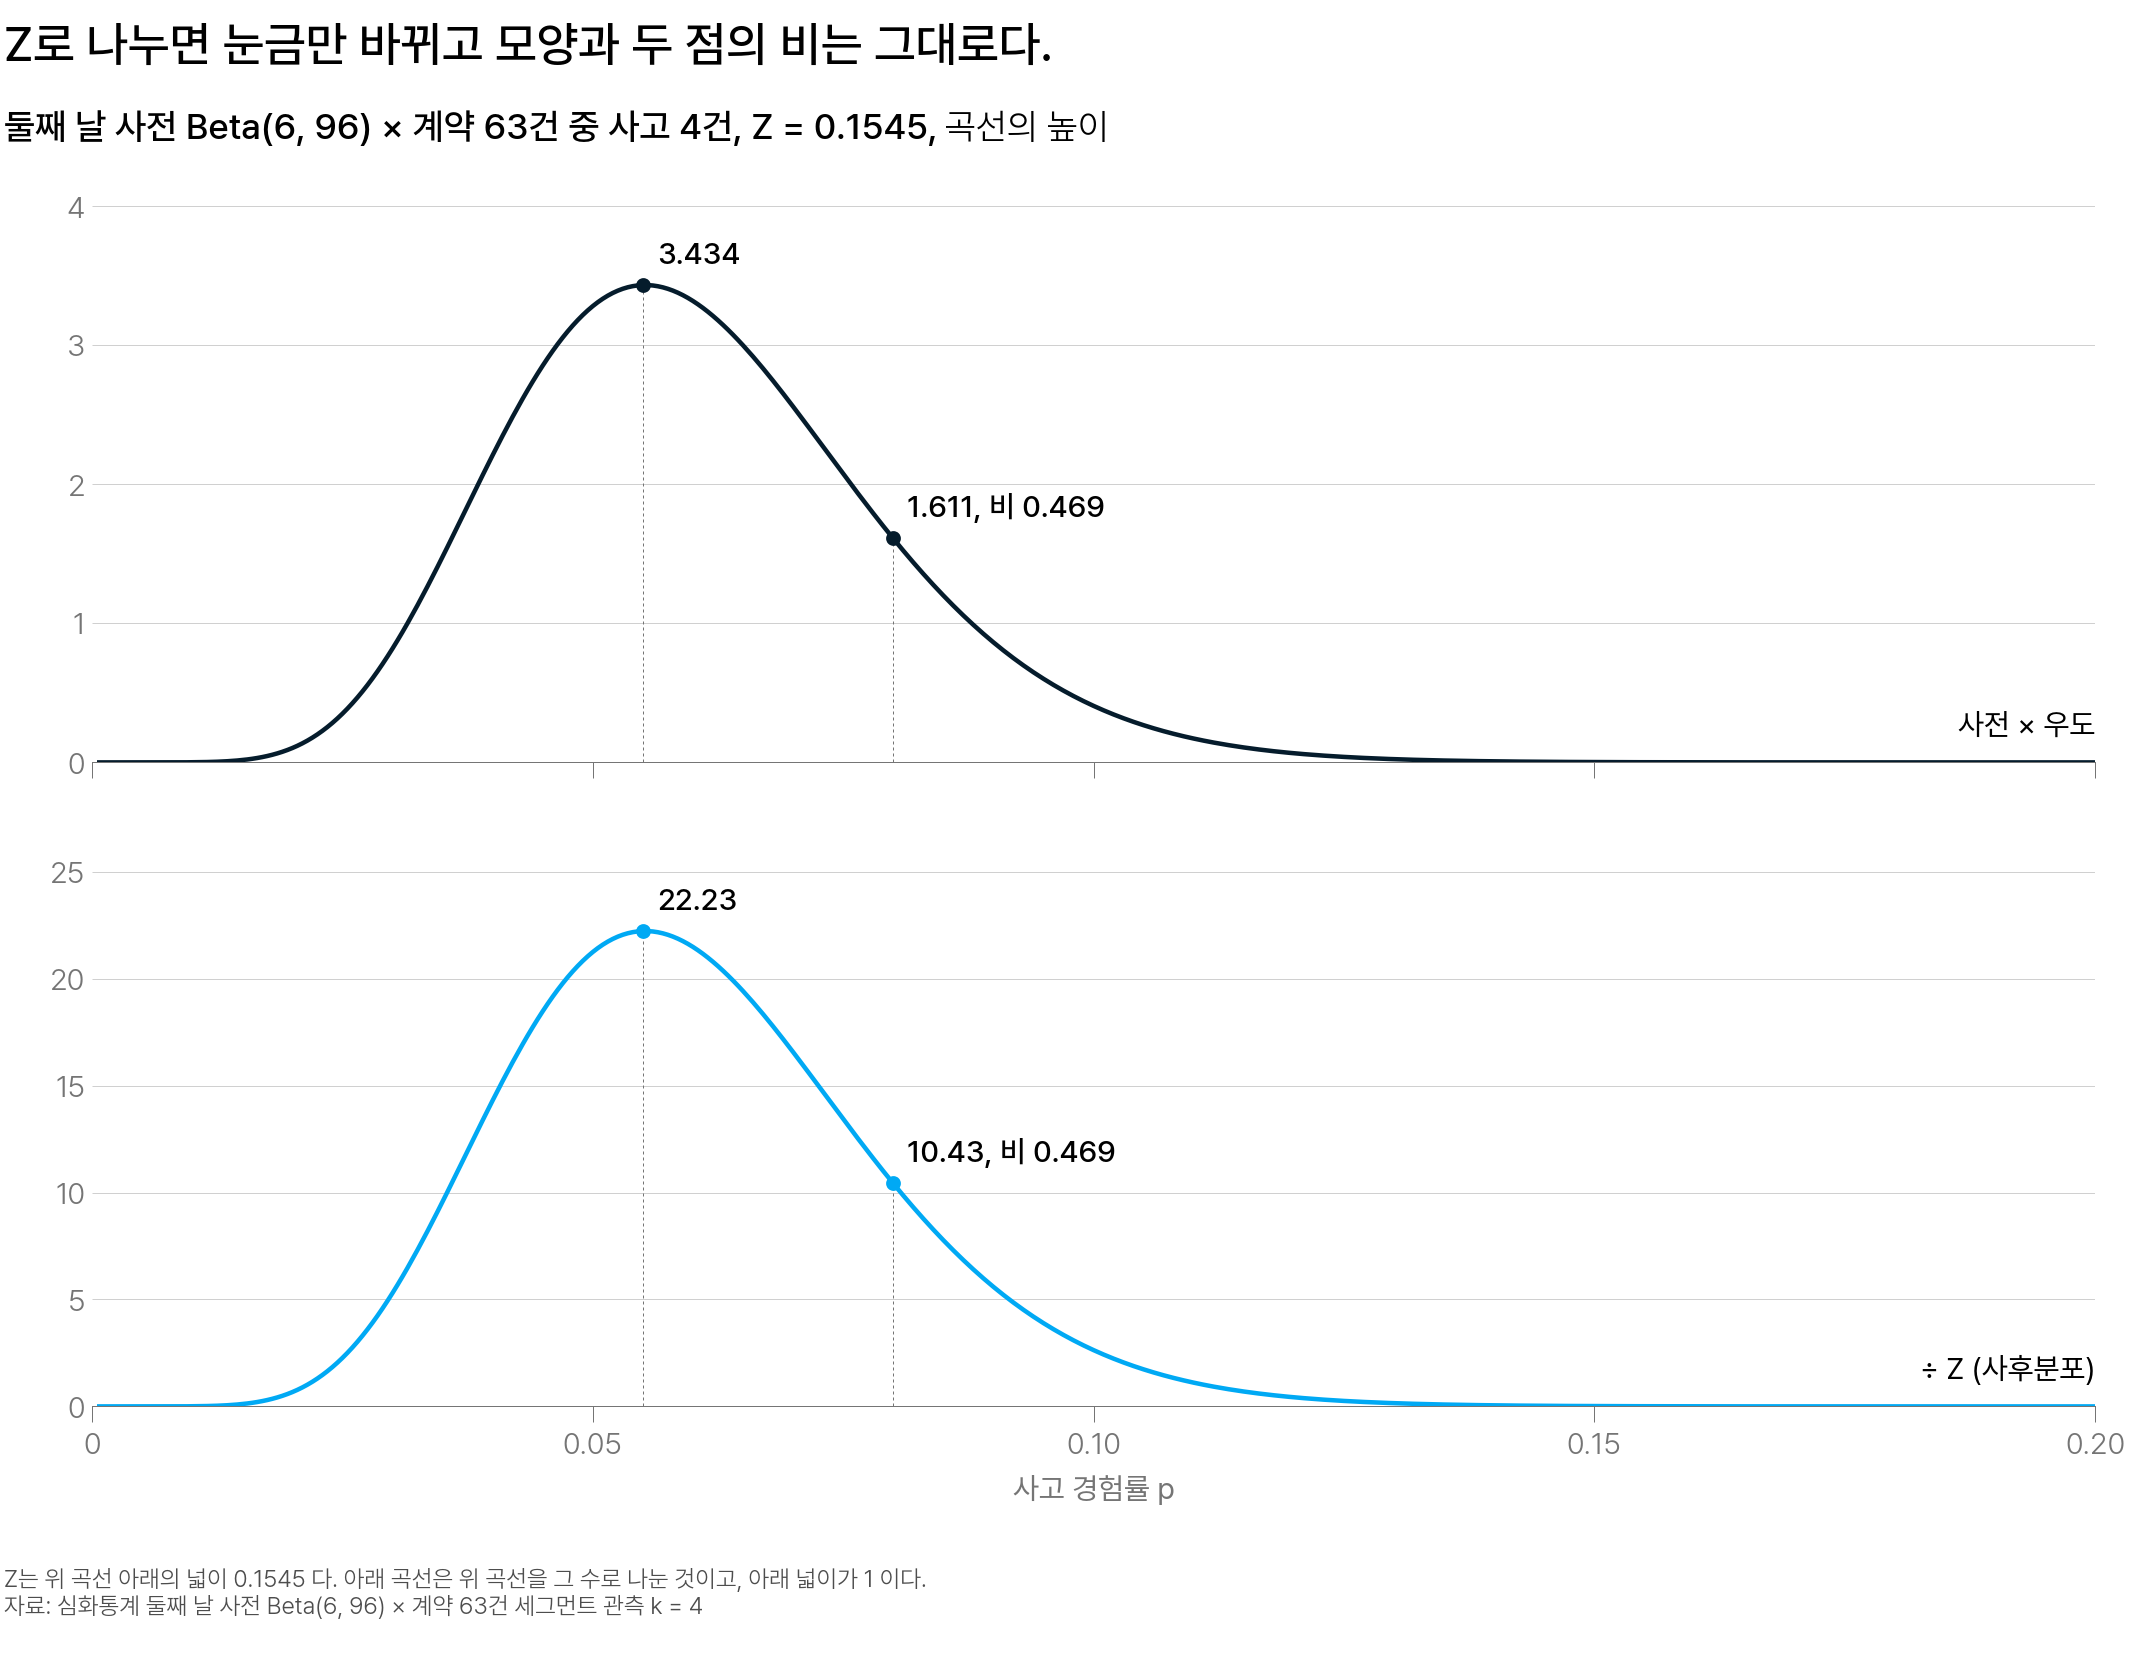

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ Z 로 나누기 전과 나눈 뒤의 같은 곡선 — 위가 사전 × 우도이고 아래가 그것을 0.1545 로 나눈 사후분포다 — 세로 눈금만 약 6.5배로 바뀌고 모양과 두 점의 높이 비 0.469 는 그대로다.</em></p>

그림의 세로 눈금에 22.23 이 나왔으니 **밀도**라는 말을 여기서 정해 둡니다. 밀도는 확률이 아니라 곡선의 높이입니다. $p$ 는 끊김 없이 이어진 값이라 한 점의 확률은 0 이고, 대신 그 값 부근의 좁은 구간에 확률이 얼마나 몰려 있는지를 높이로 나타냅니다. 높이라서 22.23 처럼 1 을 넘습니다.

첫째 방법이 막혔으니 둘째를 확인합니다. **격자로 계산하기**는 모수마다 후보를 배열하고 모든 조합의 값을 계산합니다.

둘째 날 모수는 $p$ 하나였습니다. 후보를 100개 두면 계산이 100번입니다. 그 100개를 더한 뒤 후보 사이의 간격 0.01 을 곱한 값이 $Z$ 입니다(15.45 × 0.01 = 0.1545).

모수가 2개면 달라집니다. 사후분포의 높이는 두 모수의 쌍마다 하나씩 있으므로 100행 × 100열 = 10,000개 값의 표가 됩니다.

말로 적으면 조합 수 = 후보 수를 모수 수만큼 거듭제곱한 값입니다.

계산이 200번이 아닌 이유는 이렇습니다. 예를 들어 첫째 모수를 0.03 에 고정하면, 그 행의 값 100개는 둘째 모수가 무엇이냐에 따라 전부 다릅니다. $Z$ 는 이 10,000개를 전부 더한 뒤 두 모수의 후보 간격을 곱한 값입니다.

#### 왜 모수마다 따로 계산할 수 없는가

계층 모형에서 $\theta_j$ 의 사전분포 $N(0,\ \tau^2)$ 의 높이는 $\tau$ 에 따라 달라집니다. $\tau$ 후보를 하나 바꾸면 242개 $\theta_j$ 의 높이가 전부 다시 계산됩니다. 그래서 $\tau$ 따로, $\theta_j$ 따로가 되지 않고 조합 단위로 계산합니다.

계층 모형의 모수는 공통 평균 $\mu$ 1개, 세그먼트 간 표준편차 $\tau$ 1개, 세그먼트마다 $\theta_j$ 242개를 더해 **244개**입니다.

> **[예측] 계층 모형에는 모수가 244개 있습니다. 모수 하나에 후보를 100개씩 두고 격자로 계산하면 조합이 몇 개일까요?**
>
> 1. 24,400개 — 모수 수 × 후보 수
> 2. 약 $10^{24}$ 개 — 자릿수는 훨씬 작지만 컴퓨터로는 끝낼 수 없는 규모
> 3. 약 $10^{488}$ 개 — 관측 가능한 우주의 원자 수보다 많다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

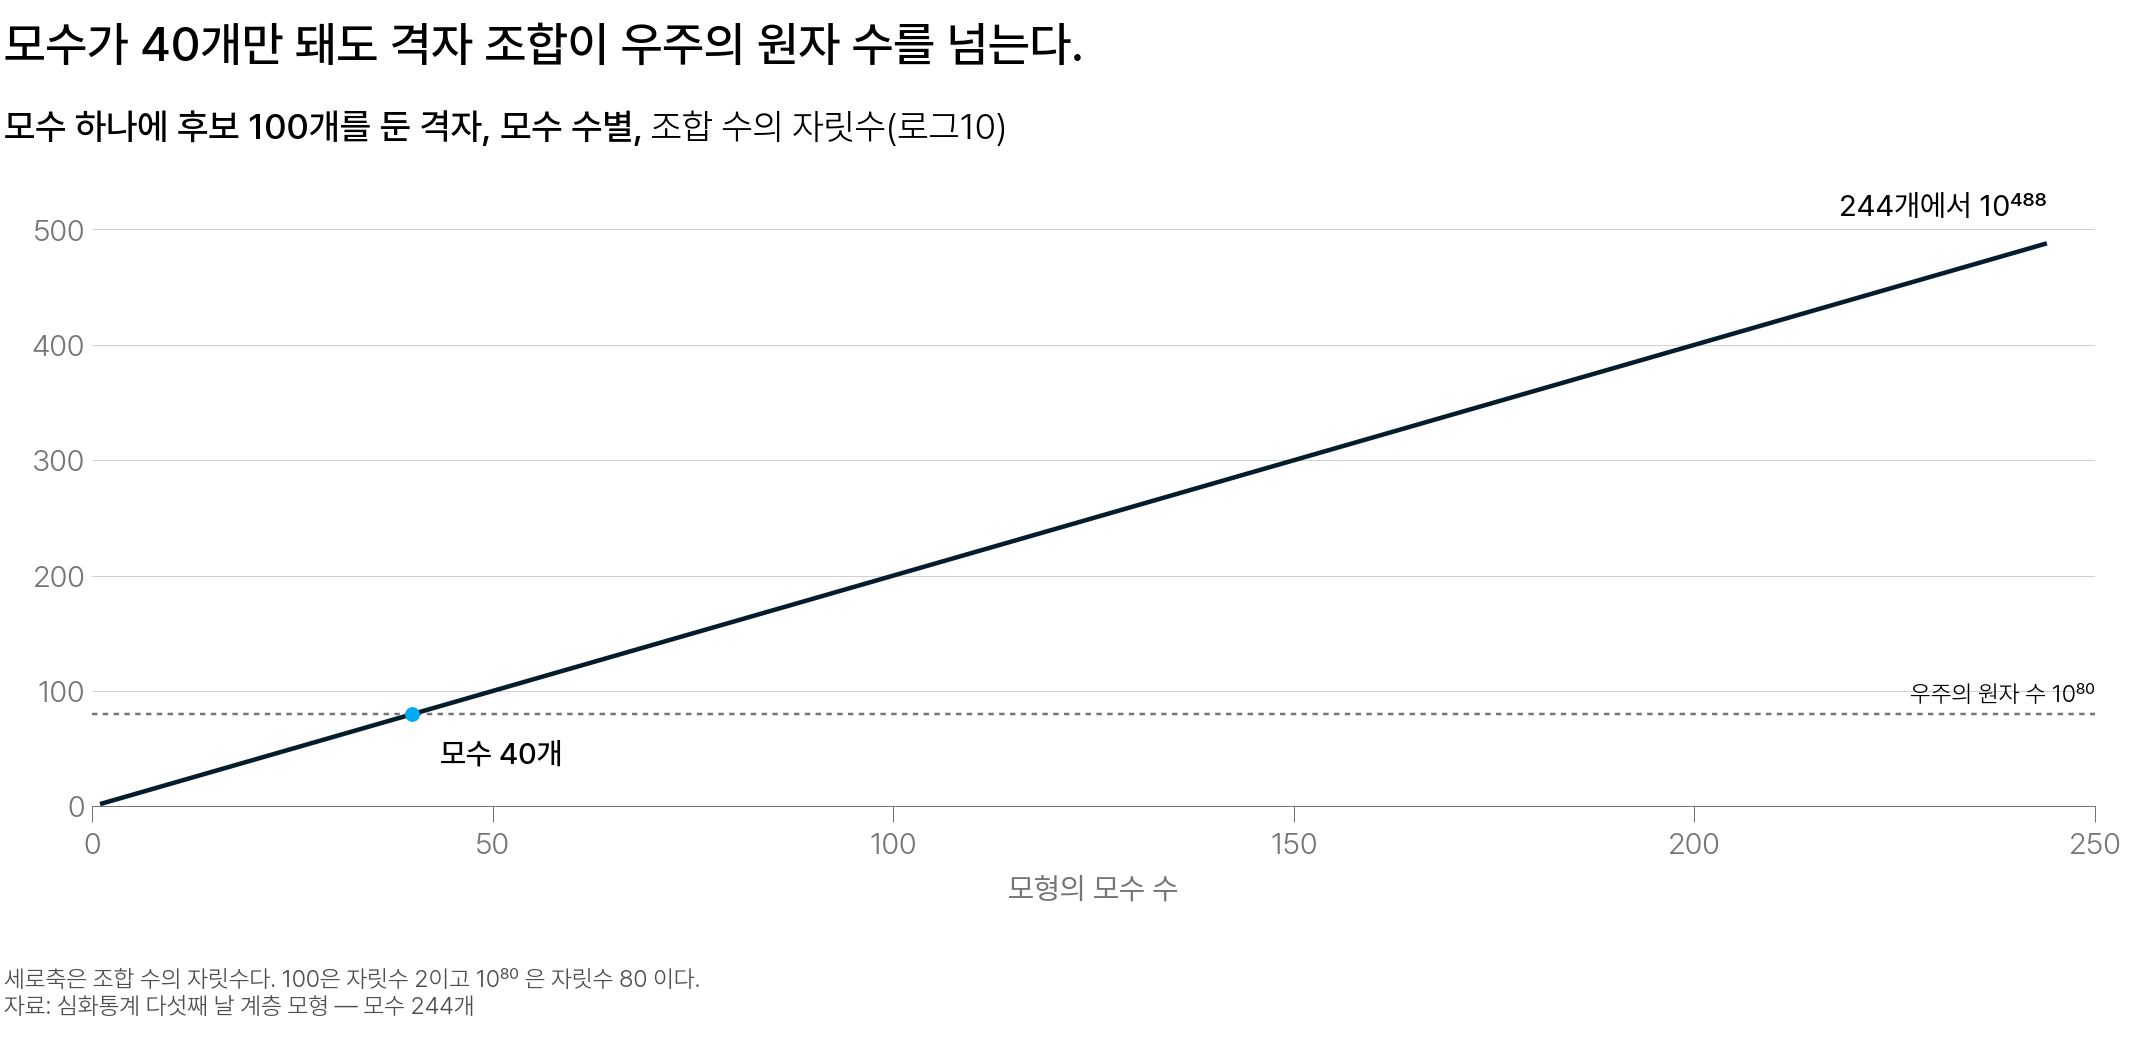

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 모수 수와 격자 조합 수 — 세로축은 조합 수의 자릿수이고 회색 점선이 자릿수 80 이다 — 모수 40개에서 이미 우주의 원자 수를 넘고, 244개는 아래 표의 마지막 행이다.</em></p>

세로축은 조합 수의 **자릿수**라 눈금이 100 오를 때마다 조합 수는 $10^{100}$ 배가 됩니다. 선이 직선인 이유는 가로로 모수를 1개 더할 때마다 세로로 자릿수가 2 씩 오르기 때문입니다.

| 모수 수 | 조합 수 | 자릿수 |
|---:|---:|---:|
| 1 | 100 | 2 |
| 2 | 10,000 | 4 |
| 244 | $10^{488}$ | 488 |

예측 질문의 보기에 있던 24,400 은 244 × 100 이고, 모수마다 따로 100번씩 계산하면 된다고 볼 때의 수입니다. 방금 확인한 대로 따로 계산이 되지 않으므로 이 수는 틀립니다. 모수 244개의 조합은 $10^{488}$ 개입니다.

보기에 있던 $10^{24}$ 도 집계할 수 있는 수가 아닙니다. 1초에 10억($10^9$) 개를 집계해도 $10^{24} \div 10^9 = 10^{15}$ 초, 약 3,200만 년이 걸립니다.

우리 모형의 244개를 대입해 보겠습니다.

$$
100^{244} = 10^{488}
$$

- $100$ : 모수 하나에 배열한 후보 수입니다.
- $244$ : 모형의 모수 수입니다.
- $10^{488}$ : 그 조합의 수입니다.

이는 다음 뜻입니다.

- 모수를 하나 더할 때마다 조합 수가 100배가 됩니다.
- 관측 가능한 우주의 원자 $10^{80}$ 개마다 컴퓨터를 한 대씩 배치해도 끝나지 않습니다.

모수가 늘면 격자 비용이 지수로 커지는 현상을 **차원의 저주**라 부릅니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Triangle_plot_of_the_MCMC.png" width="620" height="613"/>
<p align="center"><em>▲ 모수 9개를 MCMC 로 추정한 표본을 모수 쌍마다 흩뿌린 그림 — 기울어진 타원은 한 모수의 값에 따라 다른 모수의 분포 위치가 달라지는 얽힘이다 — 이 얽힘 때문에 모수마다 따로 계산할 수 없다 (출처: Wikimedia Commons)</em></p>

남는 방법은 세 번째뿐입니다. 둘째 날 몬테카를로로 한 일이 이 방법인데, 그때는 사후분포에 Beta(10, 155) 라는 이름이 있어 코드 한 행으로 추출할 수 있었지만 지금은 그 이름이 없습니다.

**마르코프 체인 몬테카를로(MCMC)** 는 사후분포 위에서 무작위 이동을 반복하고 **체인이 지나간 상태를 표본으로 삼는** 방법입니다. 오래 반복하면 그 상태들의 분포가 사후분포와 같아집니다. 다음 상태가 **바로 앞 상태 하나에만** 달려 있어 이 반복 과정을 **체인**이라 부릅니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Markovkate_01.svg" width="520" height="520"/>
<p align="center"><em>▲ 마르코프 체인의 가장 작은 예 — 상태가 2개뿐이고 화살표에 적힌 수가 다음 상태로 이동할 확률이다 — 다음 상태는 지금 어느 상태에 있는지만으로 정해지고 여기까지 온 경로는 쓰이지 않는다 (출처: Wikipedia)</em></p>

수를 읽어 보면, 지금 E 에 있을 때 다음 걸음은 확률 0.7 로 A 이고 0.3 으로 제자리입니다. 지금 A 에 있으면 0.4 로 E 이고 0.6 으로 제자리이며, 어느 쪽이든 여기까지 온 경로는 이 수에 들어가지 않습니다.

우리가 이동할 곳은 상태 2개가 아니라 끊김 없이 이어진 실수 값 전체입니다. 다만 방향만 무작위로 뽑아 이동하면 밀도가 높은 구간을 찾아가지 못하므로, 아래에서 더하는 수용 규칙이 그 일을 합니다.

목표를 다시 적어 둡니다. 오늘 정할 것은 세그먼트 간 표준편차 $\tau$ 를 데이터로 얻는 일이고, 그러려면 미지수 244개의 사후분포에서 표본이 필요합니다.

표본 1개는 값 244개의 묶음입니다. MCMC 는 그 표본을 만드는 도구입니다.

곡선을 닮은 표본을 손으로 찍는다면 높은 곳에 자주, 낮은 곳에 가끔 찍을 것입니다. MCMC 의 규칙 2개는 그 습관을 수식으로 적은 것입니다. 먼저 손으로 해 봅니다.

### [직접 해보기] 곡선을 닮은 표본을 손으로 찍어 보기

왼쪽 회색 점선 곡선은 사전에 우도를 곱한 것이고, 그 최댓값을 1 로 맞춘 상대 높이가 세로 눈금입니다.

곡선을 닮은 표본 30개를 찍으려면 어느 구간에 몇 개씩 찍겠습니까? 답을 적어 둔 뒤 아래 순서대로 조작합니다.

1. **조작.** 왼쪽 그림의 곡선 아래를 클릭해 표본을 30개쯤 찍습니다. 마우스를 쓰기 어렵다면 슬라이더 `위치 p` 로 값을 정한 뒤 그 위의 `여기에 추가` 를 눌러도 표본이 하나씩 더해집니다. 다 찍었으면 `MCMC 로 같은 수만큼` 을 눌러 MCMC 가 뽑은 표본을 같은 그림에 겹쳐 봅니다. 처음부터 다시 하려면 `지우기` 를 누릅니다.
2. **관찰.** 오른쪽 `구간 비율 대조` 에서 행마다 막대 3개의 길이를 견줍니다. `내 비율` 이 `정확한 확률` 에 얼마나 가까운지, `MCMC 비율` 은 또 어떤지 봅니다. 아래 읽기값 `곡선과의 차이` 는 구간 5개의 비율 차를 모두 더한 값이라 0 에 가까울수록 곡선을 닮은 표본입니다. 표본이 30개뿐이면 손으로 찍은 쪽도 MCMC 쪽도 0.1 에서 0.3 만큼은 출렁입니다.
3. **확인 질문.** 표본을 찍는 동안 손이 한 일은 두 가지입니다. 높은 곳에 자주 찍었고, 낮은 곳에도 가끔 찍었습니다. 이 두 가지가 곧이어 나오는 규칙 2개와 각각 어떻게 대응하는지 한 문장씩 적어 봅니다. 낮은 곳에 한 번도 찍지 않으면 `곡선과의 차이` 가 어느 구간에서 얼마나 커지는지도 화면에서 확인해 적습니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/hand-lab.html", width=980, height=520)

제안을 수용할지 기각할지 정하는 규칙은 문장 2개입니다. **밀도가 높아지면 무조건 이동하고, 낮아지면 낮아진 비율만큼의 확률로 이동합니다.**

규칙이 이 두 문장뿐인 방법을 **메트로폴리스**라 부릅니다. MCMC 가운데 가장 단순한 방법입니다.

말로 먼저 적으면 이동할 확률은 「제안한 상태의 높이 ÷ 현재 상태의 높이」이고, 그 값이 1 을 넘으면 1 입니다.

같은 문장을 기호로 옮깁니다. 체인의 현재 상태를 $x$ 로 적고 이동을 제안한 상태를 $x^{*}$ 로 적습니다.

$$
\alpha = \min\left(1,\ \frac{P(x^{*} \mid \text{데이터})}{P(x \mid \text{데이터})}\right)
$$

- $\alpha$ : 제안한 상태로 이동할 확률입니다.
- $P(x^{*} \mid \text{데이터})$ : 이동을 제안한 상태 $x^{*}$ 의 사후분포 밀도입니다.
- $P(x \mid \text{데이터})$ : 체인의 현재 상태 $x$ 의 사후분포 밀도입니다.

앞의 표에서 두 수를 가져옵니다. 현재 상태 $p = 0.055$ 의 높이가 3.434 이고 제안한 상태 $p = 0.080$ 의 높이가 1.611 이면 비가 0.469 라 $\alpha = \min(1,\ 0.469) = 0.469$ 이고, 100번 가운데 47번 이동합니다.

- 비가 1 이상이면 $\min$ 이 1 을 반환해 제안을 언제나 수용합니다.
- 비가 1 보다 작으면 그 비가 그대로 수용할 확률이 됩니다.

여기서 쓴 높이는 $Z$ 로 나누기 전의 사전 × 우도입니다. $Z$ 로 나눈 22.23 과 10.43 을 대입해도 비는 0.469 로 같습니다. **MCMC 는 높이 자체가 아니라 두 높이의 비만 씁니다.**

아래 그림의 ② 상자에 나오는 **제안 표준편차** 는 한 번에 제안하는 이동 거리의 표준편차입니다. 말로 먼저 적으면 제안은 「현재 값 + 잡음」이고, 잡음은 평균이 0 이고 표준편차가 제안 표준편차인 정규분포에서 뽑습니다. 값이 클수록 멀리 제안합니다.

$$
x^{*} = x + \varepsilon,\quad \varepsilon \sim N(0,\ s^{2})
$$

- $x$ : 체인의 현재 상태입니다.
- $x^{*}$ : 이동을 제안한 상태입니다.
- $\varepsilon$ : 현재 상태에 더하는 잡음입니다.
- $s$ : 제안 표준편차입니다.

아래 코드 셀의 `step` 이 $s$ 이고 위젯의 `제안 폭` 도 같은 값입니다.

현재 값 0.100 에서 $s$ 를 바꿔 후보를 3개씩 뽑으면 이렇습니다.

| $s$ | 뽑은 후보 3개 |
|---:|---|
| 0.002 | 0.101, 0.102, 0.101 |
| 0.02 | 0.107, 0.116, 0.107 |
| 0.30 | 0.204, 0.346, 0.199 |

제안 표준편차가 0.02 이면 한 걸음의 이동 거리가 0.02 안쪽인 제안이 68% 라, 사후평균 0.06 에서 제안은 주로 0.04 와 0.08 사이에 떨어집니다.

$s$ 가 아주 작으면 제안이 현재 값 바로 옆이라 거의 다 수용되지만, 한 걸음이 짧아 사후분포가 차지하는 구간을 지나가는 데 오래 걸립니다. $s$ 가 아주 크면 제안이 멀리 떨어져 높이가 낮은 곳이나 0 보다 작은 값, 1 보다 큰 값(높이 0)으로 가서 대부분 기각됩니다. $s$ 가 0.30 이면 20,000걸음 가운데 41.6% 가 0 보다 작거나 1 보다 큰 제안입니다.

제안한 이동 가운데 실제로 이동한 비율은 **수용률(acceptance rate)** 이라 부릅니다. 아래 코드 셀의 표집기가 출발점 0.05 에서 $s$ 를 0.02 로 두고 뗀 첫 5걸음은 이렇습니다.

| 걸음 | 현재 | 제안 | 비 | 난수 | 결과 |
|---:|---:|---:|---:|---:|---|
| 1 | 0.0500 | 0.0525 | 1.00 | 0.27 | 이동 |
| 2 | 0.0525 | 0.0653 | 0.88 | 0.02 | 이동 |
| 3 | 0.0653 | 0.0546 | 1.00 | 0.91 | 이동 |
| 4 | 0.0546 | 0.0807 | 0.45 | 0.73 | 머묾 |
| 5 | 0.0546 | 0.0405 | 0.67 | 0.94 | 머묾 |

4번 걸음에서 머물렀으니 5번 걸음의 현재 값이 4번과 같은 0.0546 입니다. 5번 제안 가운데 3번 이동했으니 수용률은 3 ÷ 5 = 0.60 이고, 20,000걸음 전체로는 0.674 입니다(아래 코드 출력의 수용률과 같은 값).

같은 코드에서 $s$ 만 바꾸면 수용률이 0.002 에서 0.966, 0.02 에서 0.674, 0.30 에서 0.077 입니다. 뒤의 그림과 「제안 표준편차에 따른 체인의 이동」 위젯은 걸음 수와 출발점과 난수가 달라 96%·67%·6% 와 96%·66%·8% 로 조금씩 다릅니다.

아래 그림의 ③ 상자에 적힌 것이 앞에서 적은 $\alpha$ 의 식입니다. 그림에서는 상자가 좁아 「데이터를 주었을 때」라는 조건 부분을 덜어 적었습니다. 그림에 적힌 두 밀도도 본문 식과 같은 사후분포의 밀도이고 사전분포가 아닙니다.

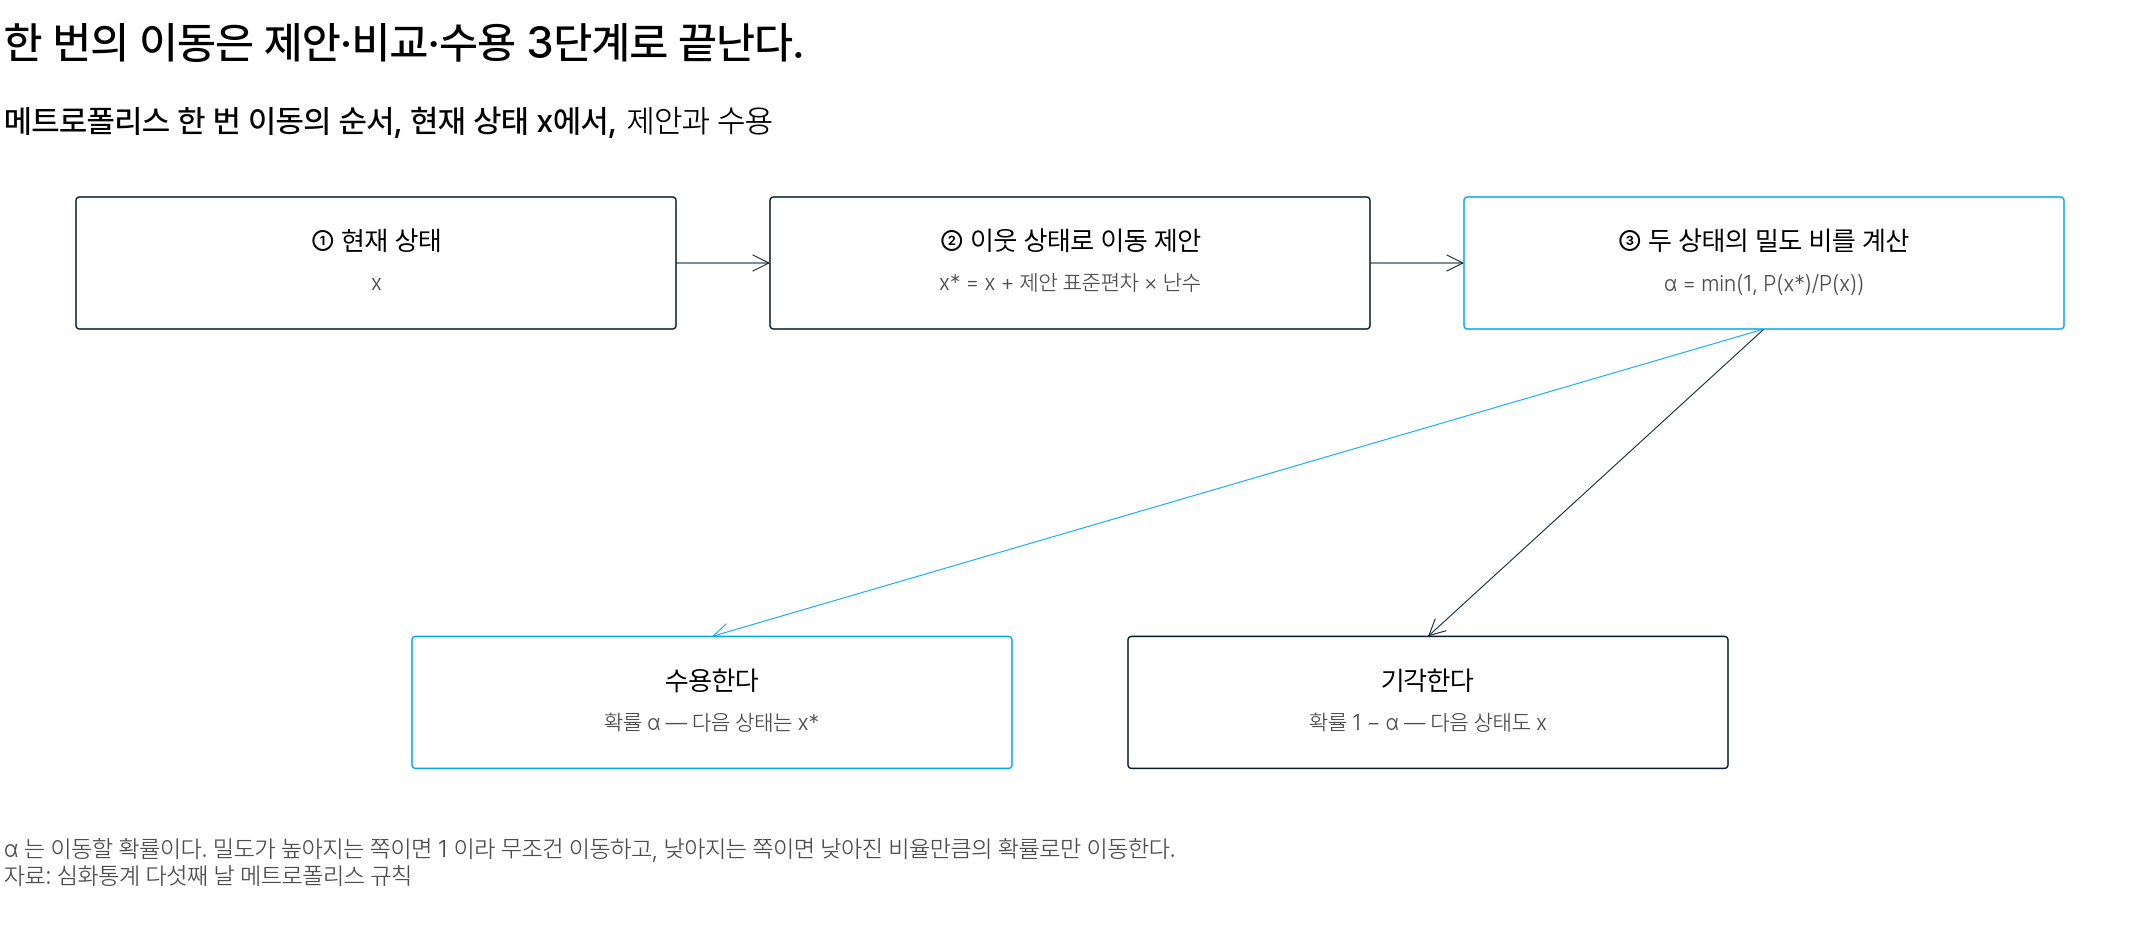

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 메트로폴리스의 한 번 이동 — ③ 에서 계산한 비가 이동할 확률이고, 하늘색이 수용하는 경로다 — 밀도가 낮아지는 쪽으로도 그 비만큼의 확률로 이동한다.</em></p>

앞에서 적은 $\alpha$ 의 식으로 돌아갑니다. 이 식의 분자와 분모는 아직 적을 수 없다고 한 사후분포의 밀도입니다. 그래서 같은 식을 계산할 수 있는 형태로 다시 적습니다.

$$
\alpha = \min\left(1,\ \frac{\text{사전}(x^{*}) \times \text{우도}(x^{*})}{\text{사전}(x) \times \text{우도}(x)}\right)
$$

앞에서 계산할 수 없다고 한 것은 $Z$ 하나였습니다. 사후분포의 밀도가 사전분포와 우도의 곱을 $Z$ 로 나눈 값이라, 그 $Z$ 가 분자와 분모에 똑같이 들어 있어 약분됩니다. 남는 것은 어느 점에서든 값을 대입해 계산되는 사전분포와 우도뿐입니다. **MCMC 가 계층 모형을 푸는 이유는 이 약분 하나가 전부입니다.**

### [직접 해보기] 한 걸음은 어떻게 정해지는가

앞의 위젯이 표본을 한꺼번에 찍었다면 이 위젯은 한 걸음을 쪼갭니다. 왼쪽 회색 점선 곡선과 세로 눈금은 앞 위젯과 같습니다. 채운 점은 지금 상태, 빈 점은 이번 걸음의 다른 한 상태입니다.

조작하기 전에 예측해 봅니다. 제안한 상태의 높이가 지금 상태보다 낮을 때, 체인은 그쪽으로 가지 않을까요 아니면 낮아진 만큼의 확률로 갈까요. 답을 적어 둔 뒤 아래 순서대로 조작합니다.

1. **조작.** 위젯은 `제안 폭`(앞에서 말한 제안 표준편차) 0.020, `출발점` 0.100, 걸음 0 인 상태로 열립니다. 먼저 `한 걸음` 을 여섯 번 누르며 오른쪽 읽기값의 둘째 줄을 매번 읽습니다. 그다음 `100걸음` 을 여섯 번 눌러 606걸음까지 채웁니다. 한 걸음씩 흘러가는 모습을 보고 싶으면 `자동 재생` 을 눌러도 됩니다.
2. **관찰.** 첫 걸음의 읽기값은 `현재 0.1000 (높이 0.118)`, `제안 0.1041 (높이 0.084)`, `비 0.71`, `난수 0.11` 이 차례로 이어지고 끝이 `이동` 입니다. 화면의 비는 제안한 상태의 높이를 지금 상태의 높이로 나눈 값이고, 그 값보다 난수가 작으면 `이동`, 크거나 같으면 `머묾` 입니다. 높이가 높아지는 걸음에서는 난수를 뽑을 것도 없이 `높이가 높아지므로 무조건 이동` 이 나옵니다.
3. **관찰.** 606걸음을 채우면 하늘색 막대가 회색 점선 곡선의 모양을 되찾고, `0.05~0.06 구간에 머문 비율` 0.22 가 `정확한 확률` 0.22 와 같아집니다. `체인 사후평균` 0.05935 와 `정확한 사후평균` 0.06061 도 소수 둘째 자리까지 같습니다. 걸음 수와 난수가 달라 아래 코드의 0.06034 와는 소수 셋째 자리부터 다릅니다.
4. **확인 질문.** 낮은 쪽으로 가는 제안을 두고 적어 둔 예측과 화면의 결과를 대조합니다. 그리고 `제안 폭` 을 오른쪽 끝 0.300 까지 옮긴 뒤 `처음부터` 를 누르고 다시 600걸음을 채워, `수용률` 이 얼마까지 떨어지는지와 그때 막대가 곡선을 채우지 못하는 이유를 왼쪽 점 아래 가로 선분의 길이에서 찾아 적어 봅니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/step-lab.html", width=980, height=520)

#### 왜 낮아지는 쪽으로도 이동하는가

늘 높은 쪽으로만 가면 체인이 가장 높은 한 점에 갇힙니다. 그러면 얻는 것은 최빈값(MAP) 하나뿐이고 곡선의 모양은 얻지 못합니다. 비율만큼 낮은 쪽으로도 가야 높이의 비율대로 표본이 모입니다.

기각한 걸음에서는 현재 값을 표본에 한 번 더 적습니다. 그래서 이동 경로에 평평한 구간이 생기고, 도수분포는 같은 값을 여러 번 집계합니다.

아래 코드는 그 문장 2개를 그대로 옮겼습니다. 현재 상태 $x$ 가 변수 `p` 이고 제안한 상태 $x^{*}$ 가 변수 `q` 입니다.

`log_post` 가 $Z$ 없는 사전 × 우도이고, `lq - lp` 가 두 높이의 비를 로그로 적은 값입니다. 로그에서는 나눗셈이 뺄셈이 되기 때문입니다.

In [ ]:
# 메트로폴리스 표집기 — 둘째 날 사후분포 Beta(10, 155) 를 표본으로 다시 계산한다
import numpy as np

k, n = 4, 63                      # 63건 세그먼트: 계약 63건 중 사고 4건
a0, b0 = 6.0, 96.0                # 둘째 날 사전 Beta(6, 96)


def log_post(p):                  # 사전 x 우도 (로그) — 정규화 상수 Z 는 빠져 있다
    if not 0.0 < p < 1.0:
        return -np.inf
    return (a0 - 1) * np.log(p) + (b0 - 1) * np.log1p(-p) \
         + k * np.log(p) + (n - k) * np.log1p(-p)


rng = np.random.default_rng(0)
draws, step = 20000, 0.02
chain = np.empty(draws)
p = 0.05                          # 출발점
lp = log_post(p)
for i in range(draws):
    q = p + step * rng.standard_normal()      # 1) 이웃 상태로 이동 제안
    lq = log_post(q)
    if np.log(rng.random()) < lq - lp:        # 2) 좋아지면 가고, 나빠져도 가끔 간다
        p, lp = q, lq                         # 3) 수용하면 그 상태로 옮긴다
    chain[i] = p
burn = draws // 2
post = chain[burn:]

print(f"체인으로 얻은 사후평균   = {post.mean():.5f}")
print(f"공식으로 푼 사후평균   = {(a0 + k) / (a0 + b0 + n):.5f}   (Beta(10, 155) 의 평균)")
print(f"체인으로 얻은 95% 구간   = [{np.quantile(post, 0.025):.4f}, {np.quantile(post, 0.975):.4f}]")
exact = np.random.default_rng(1).beta(a0 + k, b0 + n - k, 1000000)   # 이름이 있으니 바로 추출된다
print(f"Beta(10, 155) 에서 바로 추출한 95% 구간 = [{np.quantile(exact, 0.025):.4f}, {np.quantile(exact, 0.975):.4f}]")
print(f"수용률                 = {np.mean(np.diff(chain) != 0):.3f}")

체인으로 얻은 사후평균이 **0.06034** 이고 공식으로 푼 사후평균이 **0.06061** 이라 소수점 아래 2자리까지 같고 두 값의 차는 0.00027 입니다. 95% 구간은 관측이 드문 꼬리 쪽에서 조금 차이 납니다. 체인으로 얻은 위끝 0.0985 가 공식으로 푼 위끝 0.1016 보다 작습니다. **공식이 있는 경우에 답을 대조했으니 공식이 없는 경우에도 같은 규칙을 그대로 쓸 수 있습니다.**

둘째 날 같은 세그먼트에 적은 0.0552 는 이 사후분포의 최빈값(MAP)이고 여기 0.0606 은 같은 분포의 평균입니다.

여기서 볼 설정값은 **제안 표준편차 0.02** 와 **버릴 앞 구간** 2개입니다. 제안 표준편차는 위 코드의 `step` 이고, 버릴 앞 구간은 `burn = draws // 2` 입니다. 방금 읽은 0.06034 는 그 뒤의 `post` 로 계산한 값입니다(절반을 버리는 이유는 곧 나옵니다). 출발점 `p = 0.05` 와 반복 횟수 20,000, 그리고 체인을 몇 개 돌릴지도 사람이 지정하는 값이고, 그 셋은 5번에서 다룹니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Metropolis_hastings_algorithm.png" width="800" height="261"/>
<p align="center"><em>▲ 제안이 나오는 방식 — 실선이 표본을 얻으려는 사후분포이고 점선이 현재 상태에서 제안 표준편차로 이동 거리를 뽑는 분포다 — 왼쪽처럼 현재 상태가 밀도가 높은 구간의 왼쪽에 있으면 오른쪽으로 제안이 자주 나오고, 오른쪽처럼 꼬리에 있으면 제안이 좌우 양쪽으로 고르게 나온다 (출처: Wikipedia)</em></p>

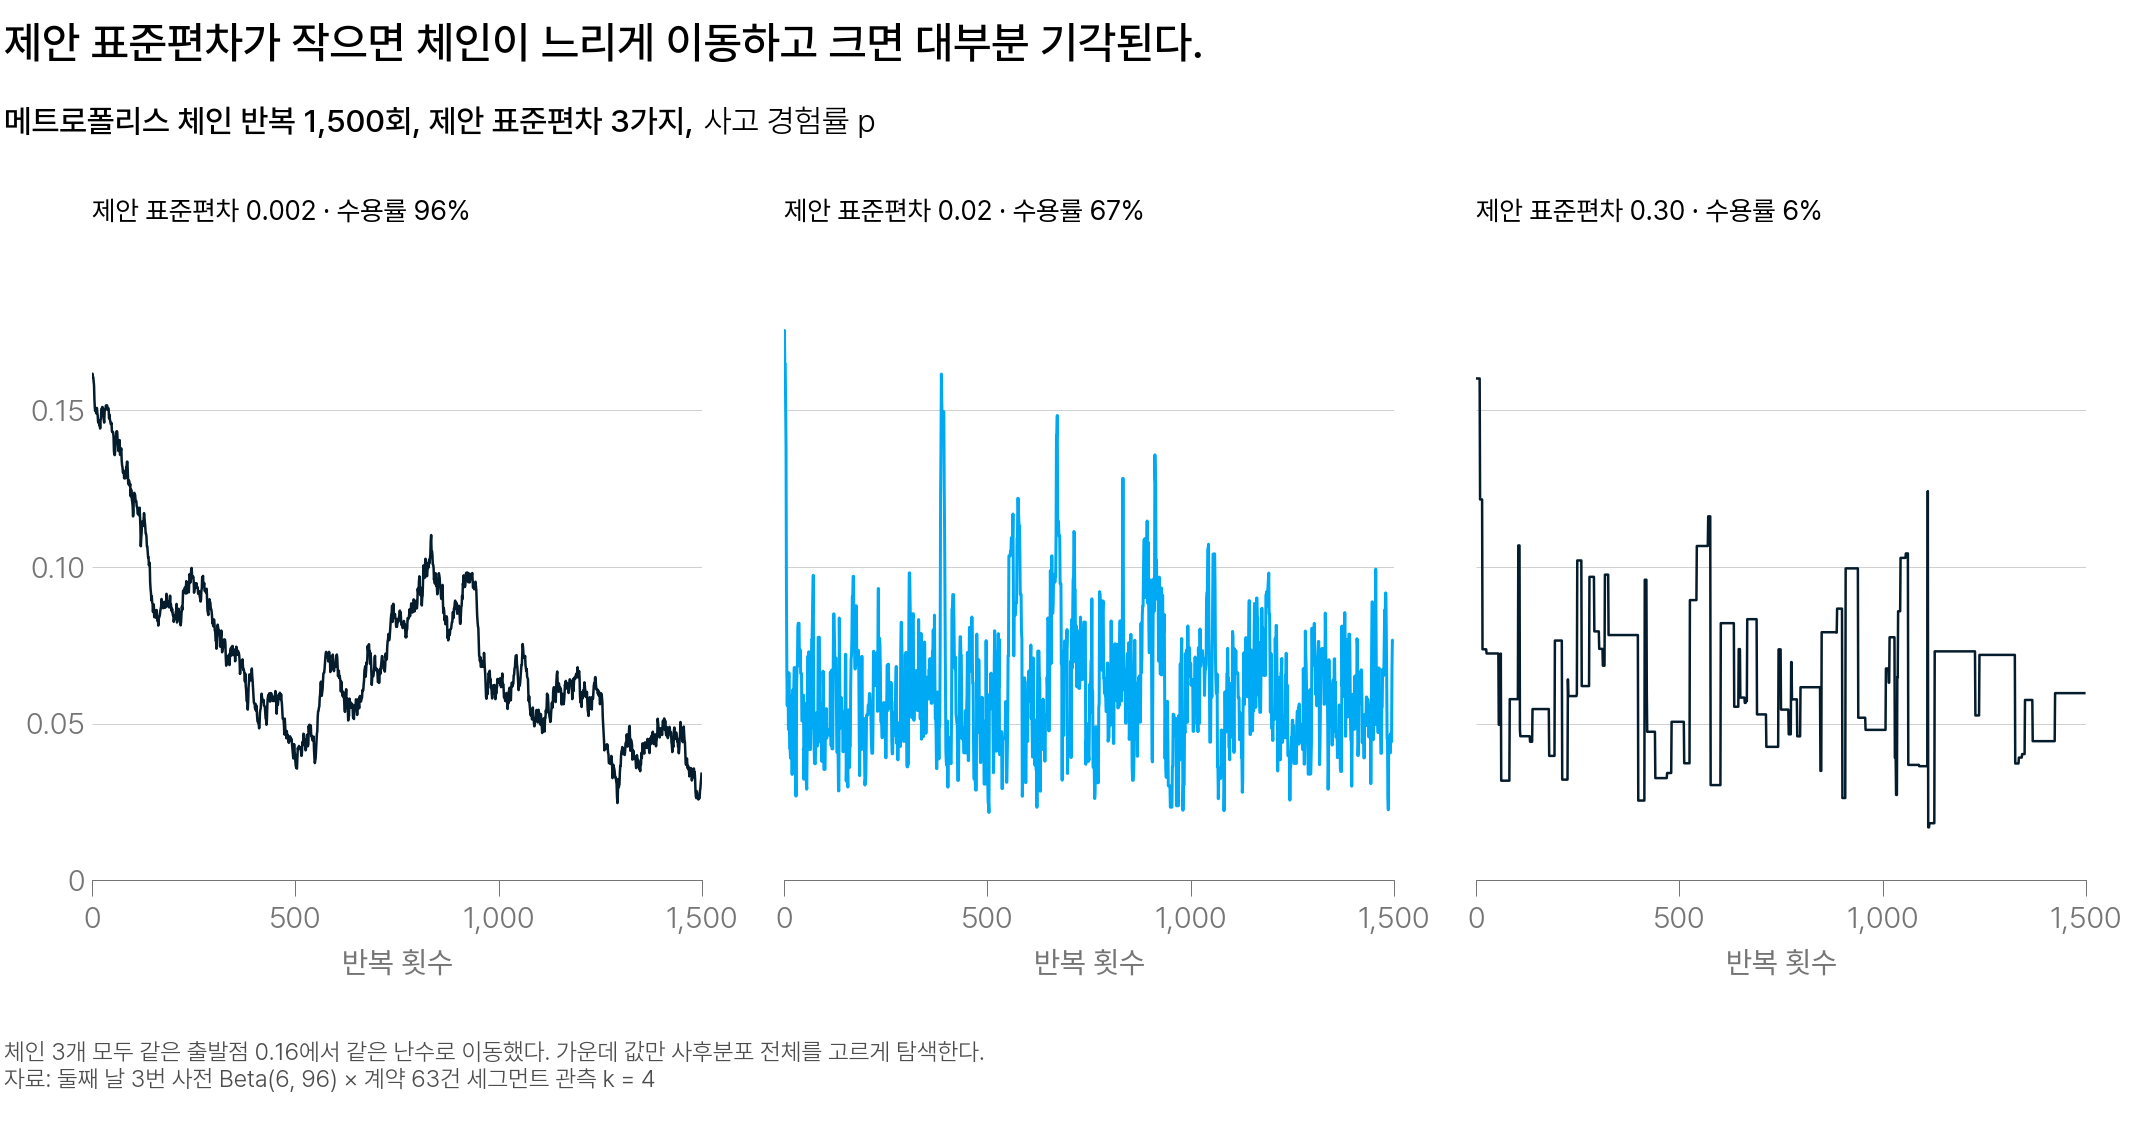

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 제안 표준편차 3가지로 실행한 같은 체인 — 가운데가 0.02 다 — 값이 작으면 한쪽에서 다른 쪽으로 이동하는 중이고 값이 크면 대부분 기각되어 계단 모양이 된다.</em></p>

패널 3개가 같은 사후분포를 대상으로 하는데 모양이 전혀 다릅니다. 제안 표준편차가 **0.002** 면 수용률이 96% 로 거의 다 수용됩니다. 그런데 한 번의 이동 거리가 짧아 반복 1,500회를 지나도 사후분포가 차지하는 구간 전체를 지나가지 못합니다.

**0.30** 이면 수용률이 6% 라 대부분 기각되어 같은 상태에 오래 남습니다. 가운데 **0.02** 만 수용률 67% 로 사후분포 전체를 고르게 탐색합니다.

#### 왜 수용률 44% 부근을 목표로 하는가

두 극단은 반복 횟수에 비해 지나간 구간이 좁습니다. 모수 1개 문제에서는 **약 44%** 가 좋다고 알려져 있습니다. 목표는 44% 를 정확히 맞히는 것이 아니라 두 극단을 피하는 것입니다.

#### 왜 앞 구간을 버리는가

사람이 지정한 두 번째 수는 버릴 앞 구간입니다. **번인(burn-in)** 은 초기값의 영향이 아직 남아 있는 앞 구간입니다. 그 구간을 요약에서 빼는 처리도 번인이라 부릅니다.

위 코드의 `burn = draws // 2` 가 그 처리이고 절반을 버리는 방식이 흔한 관행입니다. 반복 20,000회이면 앞 10,000회를 버리고 뒤 10,000회로 요약합니다.

덜 버리면 초기값의 영향이 사후평균에 포함되어 답이 틀립니다. 반복 횟수를 함께 늘리면서 충분히 버릴 때 잃는 것은 계산 시간뿐입니다. 반복 20,000회를 그대로 둔 채 앞 18,000회를 버리면 요약에 쓸 표본이 2,000회분만 남아, 5번에서 볼 유효표본수가 1,367에서 287로 줄어듭니다.

실무 도구는 같은 구간을 **워밍업**이라 부릅니다. `pm.sample` 의 `tune` 인자가 그 반복 횟수입니다.

### [직접 해보기] 제안 표준편차에 따른 체인의 이동

이 위젯도 같은 연습 예시를 쓰고, 앞 그림과는 다른 체인 3,000걸음을 새로 실행합니다. 왼쪽은 그 체인이 지나온 이동 경로이고, 오른쪽은 앞 500걸음을 버린 뒤(코드의 절반과 달리 위젯은 걸음 수가 적어 앞 500걸음만 버립니다) 남은 걸음을 누적한 도수분포입니다. 오른쪽 회색 점선이 공식으로 구한 정확한 사후분포이고, 왼쪽 이동 경로에 깔린 회색 띠는 같은 사후분포의 95% 구간이며 화면이 `정확한 95% 구간` 이라 부릅니다.

조작하기 전에 예측해 봅니다. `제안 폭` 을 0.002 로 줄이면 오른쪽 도수분포는 회색 점선보다 넓어질까요 좁아질까요. 답을 적어 둔 뒤 아래 순서대로 조작합니다.

1. **조작.** 버튼 3개를 왼쪽부터 차례로 누릅니다. `너무 좁게 0.002`, `알맞게 0.020`, `너무 넓게 0.300` 입니다. `출발점` 슬라이더는 그대로 둡니다.
2. **관찰.** `수용률` 이 96%, 66%, 8% 로 갑니다. 양 끝의 두 값은 이유가 서로 반대입니다. 0.002 는 한 걸음이 짧아 거의 다 수용되고, 0.300 은 멀리 제안해 대부분 기각됩니다. 그 아래 `체인 95% 구간` 을 `정확한 95% 구간` 0.0296 ～ 0.1016 과 대조하면, 0.002 에서는 0.0335 ～ 0.0772 로 크게 짧고 0.020 에서는 0.0303 ～ 0.0988 로 거의 겹칩니다. `체인 사후평균` 도 0.002 에서 0.05600, 0.020 에서 0.05999 라 `정확한 사후평균` 0.06061 에 가까워집니다. 앞 그림에서 읽은 67%·6% 와 여기 66%·8% 가 다른 것도, `체인 사후평균` 0.05999 가 위 코드의 0.06034 와 소수 넷째 자리부터 다른 것도 걸음 수와 난수가 다르기 때문입니다.
3. **확인 질문.** `제안 폭` 이 0.002 일 때의 도수분포를 적어 둔 예측과 대조합니다. 그리고 그렇게 되는 이유를 왼쪽 이동 경로에서 찾아봅니다. 3,000걸음 동안 체인이 회색 띠의 어느 쪽을 지나갔는지 한 문장으로 적어 봅니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/chain-lab.html", width=980, height=520)

연습 예시는 여기까지입니다. 242개 세그먼트의 연간 사고율 $\lambda$ 를 추정하는 원래 문제로 돌아갑니다.

244개 모수에도 같은 수용 규칙을 그대로 씁니다. 앞 주제에서 본 수축 그림의 부분 풀링 값이 그렇게 모은 표본의 평균입니다.

#### 왜 Z 없이도 사후분포가 나오는가

높이가 2배인 구간에는 표본이 2배 많이 모이기 때문입니다. 그러면 「어느 구간에 머문 표본 수 ÷ 전체 표본 수」가 그 구간의 확률이 됩니다. 이 비율은 모든 구간을 더하면 저절로 1 이 됩니다. 곡선을 $Z$ 로 나누어 넓이를 1 로 맞추던 일을, 구간별 표본 수를 전체 표본 수로 나누는 일이 대신하는 것입니다.

위 코드의 체인에서 구간 3개로 확인합니다. 밀도는 좁은 구간에 몰린 확률을 높이로 적은 값이었으니, 구간에 머문 비율을 그 구간의 너비 0.01 로 나누면 높이가 됩니다.

| 구간 | 머문 비율 | $\div\ 0.01$ | 사후 Beta(10, 155) 높이 |
|---|---:|---:|---:|
| 0.05 ～ 0.06 | 0.228 | 22.8 | 22.2 |
| 0.07 ～ 0.08 | 0.135 | 13.5 | 13.4 |
| 0.09 ～ 0.10 | 0.041 | 4.1 | 3.9 |

둘째 열을 구간 너비 0.01 로 나눈 셋째 열이 그 구간 가운데의 곡선 높이와 거의 같습니다. 남은 차이는 표본 10,000개로 계산한 값이라 생기는 오차입니다. 표본의 도수분포가 곡선의 높이와 같아졌습니다.

앞의 「한 걸음은 어떻게 정해지는가」 에서 606걸음을 채웠을 때 읽은 `0.05~0.06 구간에 머문 비율` 0.22 와 이 표의 첫 행 0.228 은 같은 구간에서 계산한 값이고, 걸음 수가 달라(위젯 606걸음, 코드의 표본 10,000개) 소수 둘째 자리가 다릅니다. 화면의 `정확한 확률` 0.22 를 소수 셋째 자리까지 적으면 0.219 입니다. 표의 0.228 은 걸음 수가 다른 체인에서 계산한 값이라 정확한 확률 0.219 보다 0.009 큽니다.

**그래서** MCMC 는 사후분포 밀도의 **절댓값**을 몰라도 **두 상태의 밀도 비**만으로 표본을 모으는 방법입니다.

대신 치르는 대가가 2가지입니다. 방금 본 제안 표준편차와 번인 길이처럼 사람이 지정해야 할 설정값이 생기고, 얻은 표본을 요약에 써도 되는지 따로 판정해야 합니다.

번인을 버린 뒤 체인이 각 상태를 지나간 횟수의 비율이 사후분포이므로, 반복 20,000회의 마지막 값 하나를 답으로 읽으면 안 됩니다. 그러면 이 표본을 요약에 써도 되는지를 무엇으로 판정하는지가 다음 질문입니다.

> **MCMC 는 사후분포의 곡선을 계산하지 않고 그 곡선을 닮은 표본을 만듭니다. 표본의 도수분포가 곧 곡선이고, 요율표에 적을 요약값은 그 표본에서 나옵니다.**

<details class="lms-extra"><summary>더 깊이 — 실무의 제안 표준편차 자동 조정과 HMC·NUTS</summary>

위 코드는 제안 표준편차를 0.02 로 고정했습니다. 모수가 1개면 몇 번 시험해 지정할 수 있지만 244개면 그럴 수 없습니다. 실무 도구는 방법 2가지로 이 문제를 피합니다.

**⑴ 앞 구간에서 제안 표준편차를 자동으로 조정합니다.** 앞 구간에서 수용률을 측정하고 목표인 44% 보다 높으면 키우고 낮으면 줄입니다. 앞에서 242개 세그먼트 그림을 만든 표집기가 이 방식입니다. 전체 반복의 5분의 1 지점에서 세그먼트마다 수용률을 측정하고 그 수용률에 맞춰 제안 표준편차를 한 번 조정했는데, 그 조정을 받은 대상은 모수 244개 전부가 아니라 세그먼트 편차 $\theta_j$ 242개뿐이고 공통 평균 $\mu$ 와 세그먼트 간 표준편차 $\tau$ 의 제안 표준편차는 사람이 지정한 값에 고정되어 있습니다.

**⑵ 애초에 그 값이 필요 없는 방식을 씁니다.** 사후분포의 기울기, 곧 로그 사후분포의 미분을 써서 밀도가 높은 쪽으로 방향을 정하면 기준 없이 제안하고 기각하는 낭비가 줄어듭니다. **해밀턴 몬테카를로(HMC)** 와 그 자동 조정 형태인 **NUTS** 가 이 계열입니다.

기울기를 쓰면 이점이 하나 더 있습니다. 메트로폴리스는 차원이 커지면 이동 거리를 줄여야 해서 체인이 느려지는데, HMC 는 기울기를 따라가므로 차원이 커져도 덜 느려집니다. 244차원에서 이미 차이가 큽니다. 수천 차원이면 메트로폴리스로는 사실상 풀 수 없습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Hamiltonian_Monte_Carlo.svg" width="800" height="415"/>
<p align="center"><em>▲ 해밀턴 몬테카를로가 지나온 이동 경로 — 등고선이 사후분포이고 붉은 곡선이 한 번의 이동이다 — 기울기를 따라 곡선을 그리며 멀리 이동하므로 기준 없이 제안하고 기각하는 낭비가 줄어든다 (출처: Wikipedia)</em></p>

그래도 여기서 메트로폴리스를 다루는 이유는 규칙이 문장 2개이기 때문입니다. 제안·수용·이동 3단계가 코드에 그대로 보여서 「사후분포에서 표본을 모은다」가 무슨 뜻인지 눈으로 확인할 수 있습니다. NUTS 는 같은 일을 훨씬 잘하지만 코드에서는 `pm.sample()` 한 행이라 내부가 보이지 않습니다.

</details>

> **[문제] 메트로폴리스가 정규화 상수를 몰라도 되는 이유는 두 지점의 사후분포 밀도를 나눌 때 그 상수가 약분되기 때문이다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 5. 수렴 진단: R-hat 과 유효표본수

**여기서 할 일**

1. 사후평균을 요율표에 옮겨도 되는지 판정하는 두 값이 무엇인지 확인합니다.
2. 두 진단값이 각각 무엇을 측정하는지 확인합니다.
3. 반복 횟수를 5배로 늘렸을 때 두 값이 어떻게 달라지는지 표로 대조합니다.

**여기서 다루는 값** — 앞 주제의 앞부분과 같습니다. 연간 사고율 $\lambda$(단위: 건/년), 지역×브랜드 242개 세그먼트입니다.

바로 앞에서 얻은 것은 표본 집합 하나입니다. 그런데 사후평균만 적어 두면 그 값이 체인이 충분히 이동한 뒤에 나온 값인지 아직 수렴하지 않은 채로 나온 값인지 구분할 수 없습니다. 그 판정에 **수렴 진단** 값 2개를 씁니다.

| 진단값 | 무엇을 측정하는가 | 기준값 | 통과하지 못하면 |
|---|---|---|---|
| R-hat($\hat{R}$) | 여러 체인이 만든 표본 분포가 서로 일치하는지 | 1.01 이하 | 표집기 설정을 먼저 확인하고, 그래도 미통과이면 반복 횟수를 늘립니다 |
| 유효표본수(effective sample size, ESS) | 체인 표본이 서로 독립인 표본 몇 개와 같은 정보량인지 | 400 이상 | 표집기 설정을 먼저 확인하고, 그래도 미통과이면 반복 횟수를 늘립니다 |

$\hat{R}$ 는 단위가 없습니다.

표에 적은 「서로 독립인 표본」부터 확인합니다. 4번 주제에서 제안 표준편차 0.02 로 실행한 체인의 뒤 10,000개 가운데 연속한 6개는 0.0657, 0.0657, 0.0427, 0.0451, 0.0467, 0.0467 입니다. 같은 값이 두 번 이어지고(머문 걸음) 이웃한 값이 서로 가깝습니다.

앞 값을 알면 다음 값을 어느 정도 맞힐 수 있는 이 관계를 **자기상관**이라 합니다. 바로 앞 값과의 상관계수는 0.748 입니다. 서로 독립인 표본이면 이 값이 0 에 가깝습니다.

유효표본수는 표본들이 서로 얼마나 닮았는지로 정해집니다. 표본이 전부 서로 독립이면 유효표본수는 표본 수와 같습니다. 앞 표본과 거의 같은 값이 이어지면 유효표본수는 표본 수보다 훨씬 작아집니다.

작은 수로 보면 이렇습니다. 표본 2개가 똑같은 값이면 새 정보는 1개분이라 유효표본수는 2개가 아니라 1개입니다. 위에 적은 0.02 체인의 10,000개도 서로 닮아 있어 독립 표본 약 1,300개와 같은 정보량입니다(계산한 유효표본수 1,305).

제안 표준편차를 바꾸면 이 수가 함께 달라집니다. 0.002 로 줄이면 연속한 값이 0.0388, 0.0388, 0.0365, 0.0367, 0.0369, 0.0338 처럼 거의 움직이지 않아 상관계수가 0.993 이고 유효표본수는 38개입니다. 0.30 으로 키우면 같은 값이 오래 이어져 상관계수 0.905, 유효표본수 497개입니다. 0.02 일 때가 1,305개로 가장 많습니다.

환산하는 식은 아래 「더 깊이 — 유효표본수 공식」에 있습니다.

<details class="lms-extra"><summary>더 깊이 — 유효표본수 공식</summary>

$$
N_{\text{eff}} \approx \frac{N}{1 + 2\sum_{k \ge 1} \rho_k}
$$

- $N$ : 저장한 표본 수입니다.
- $\rho_k$ : $k$ 걸음 떨어진 두 값 사이의 상관계수입니다. $\rho_1$ 이 바로 앞 값과의 상관계수입니다.
- 분모의 합은 $\rho_1$ 하나가 아니라 걸음 간격 $k$ 를 늘려 가며 더한 값입니다. 더하는 범위는 $\rho_k$ 가 처음으로 0 이하가 되기 전까지입니다.

$\rho_k$ 가 전부 0 이면 분모가 1 이라 $N_{\text{eff}} = N$ 입니다. 0.748 처럼 크면 분모가 커져 그만큼 줄어듭니다. 제안 표준편차 0.02 체인의 10,000개를 이 식에 대입하면 1,305 입니다. $\rho_1$ 인 0.748 하나만 넣고 멈추면 분모가 실제보다 작아 1,305 보다 큰 수가 나옵니다.

</details>

$\hat{R}$ 는 체인을 **여러 개** 실행해야 얻습니다. 서로 다른 값에서 출발한 체인 4개가 같은 구간을 이동하고 있다면 그 구간이 사후분포일 가능성이 높습니다. 4개가 서로 다른 구간에 남아 있다면 아직 수렴하지 않았습니다.

> **[예측] 체인 4개를 서로 다른 값에서 출발시켜 반복 4,000회씩 실행하면, 번인을 버린 뒤 체인 4개의 누적평균은 어떻게 될까요?**
>
> 1. 한 값으로 모인다 — 반복 4,000회면 충분하다
> 2. 두 무리로 갈라진다 — 출발점이 가까운 체인끼리 뭉친다
> 3. 넷이 갈라진 채 끝난다 — 끝까지 서로 다른 값에 남는다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

누적평균은 그 지점까지 모은 표본의 평균입니다. 앞에서 242개 세그먼트 그림을 만든 표집기를 체인 4개로 실행해 공통 평균 $\mu$ 의 누적평균을 그립니다.

표집 설정은 체인 4개이고, 체인마다 반복 횟수의 앞 절반을 번인으로 버립니다. 체인당 20,000회면 체인마다 10,000개가 남아 합이 40,000개입니다. $\hat{R}$ 는 체인 4개를 각각 앞뒤 절반으로 갈라 만든 8줄의 표본 분포가 서로 일치하는지 보는 값이고, 유효표본수는 합친 40,000개를 독립 표본으로 환산한 수입니다.

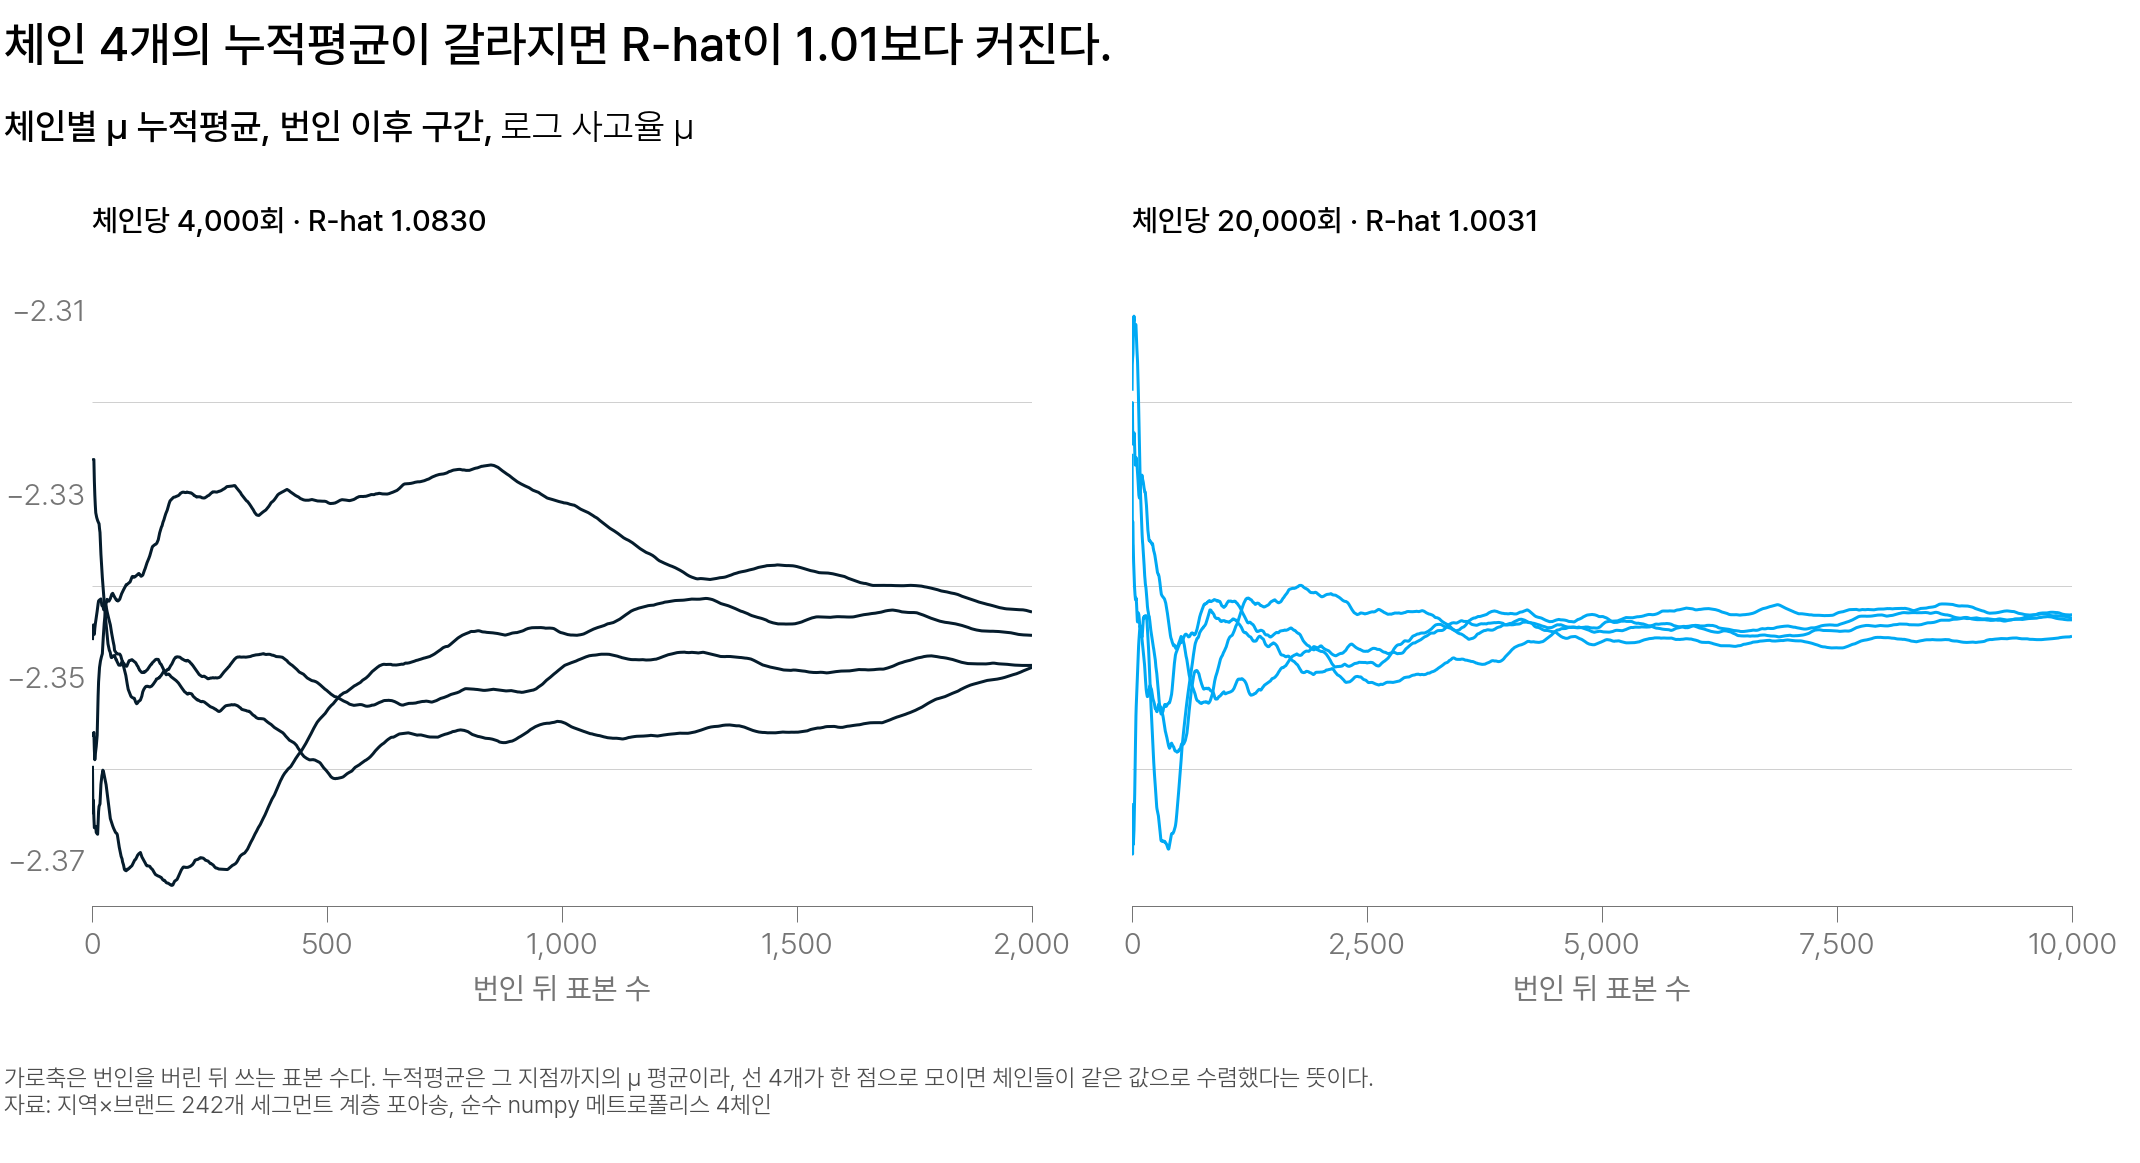

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 체인 4개의 μ 누적평균 — 왼쪽이 체인당 반복 4,000회, 오른쪽이 20,000회다 — 왼쪽은 선 4개가 끝까지 하나로 모이지 못해 끝점 4개가 −2.343 에서 −2.349 까지 0.006 만큼 흩어진 채 끝나고, 오른쪽은 절반쯤에서 겹쳐 끝점 4개가 −2.343 에서 −2.346 안에 든다.</em></p>

오른쪽에서 선 4개가 겹치는 **약 −2.34** 가 공통 평균 $\mu$ 의 값입니다. 지수를 취하면 $e^{-2.34} = 0.096$ 건/년이라 앞에서 확인한 계약 전체의 값 0.1006 건/년보다 약 5% 작습니다.

두 값이 정확히 같지 않은 것은 둘을 계산한 방식이 다르기 때문입니다. 0.1006 은 노출이 많은 세그먼트가 크게 반영된 계약 전체 값이고, $\mu$ 는 세그먼트 242개의 로그 사고율을 가운데로 모은 값입니다. 이 차이는 수렴이 덜 되었다는 신호가 아닙니다. 이 값을 요약에 써도 되는지는 뒤에서 유효표본수로 따로 판정합니다.

이 그림을 숫자 하나로 요약한 값이 $\hat{R}$ 입니다. 산포는 값들이 중심에서 떨어져 있는 크기이고, 여기서는 분산으로 측정합니다.

말로 먼저 적으면 $\hat{R}$ 는 「두 산포를 표본 수로 가중해 섞은 값 ÷ 체인 안의 산포」의 제곱근입니다.

$$
\hat{R} = \sqrt{\frac{\widehat{V}}{W}}
$$

표본분산은 편차 제곱의 합을 (개수 − 1) 로 나눈 값입니다.

- $W$ : 체인 안의 산포입니다. 체인마다 표본분산을 구해 평균 낸 값입니다.
- $B$ : 체인 사이의 산포입니다. 체인 평균들이 갈라져 있는 크기이고, 체인 평균의 표본분산에 체인당 표본 수 $N$ 을 곱해 구합니다. 3번 주제의 가상 노출 $B$ 와는 다른 값입니다.
- $\widehat{V}$ : $W$ 와 $B$ 를 표본 수로 가중해 결합한 값이고 $\widehat{V} = \frac{(N-1)W + B}{N}$ 입니다. 체인들이 갈라져 있으면 $W$ 보다 커집니다.

실제로 잴 때는 체인 4개를 각각 앞뒤 절반으로 갈라 8줄로 둔 뒤 이 식을 그대로 적용하고, $N$ 은 그 절반의 표본 수입니다. 위 그림의 1.0830 과 1.0031 도 그렇게 잰 값입니다.

아래 표본 5개 체인 2개 예제는 계산 과정이 보이도록 가르지 않은 형태로 계산한 것입니다.

체인마다 표본이 5개라면, 체인 사이의 산포가 체인 안의 산포와 같을 때 $\hat{R} = 1.00$ 입니다. 체인 사이의 산포가 10% 커서 $B = 2.75$ 가 되면 $\widehat{V} = (4 \times 2.5 + 2.75) \div 5 = 2.55$ 이고, $2.55 \div 2.5 = 1.02$ 의 제곱근이라 $\hat{R} = 1.01$ 입니다.

표본 5개인 체인 2개에 대입합니다.

| 경우 | 체인 2개의 표본 | $W$ | 체인 사이의 산포 $B$ | $\hat{R}$ |
|---|---|---:|---:|---:|
| ⑴ 겹치는 경우 | 1, 2, 3, 4, 5 와 2, 3, 4, 5, 6 | 2.5 | 2.5 | 1.000 |
| ⑵ 갈라진 경우 | 1, 2, 3, 4, 5 와 11, 12, 13, 14, 15 | 2.5 | 250 | 4.56 |

두 경우 모두 체인 안의 산포 $W$ 는 2.5 입니다. ⑴ 의 체인 사이의 산포는 체인 평균 3 과 4 의 표본분산 0.5 에 5 를 곱한 2.5 이고, ⑵ 는 체인 평균 3 과 13 의 표본분산 50 에 5 를 곱한 250 입니다. 체인 평균 3 과 4 는 평균이 3.5 라 편차가 0.5 와 −0.5 이고, $0.5^2 + 0.5^2 = 0.5$ 를 1 로 나눈 0.5 가 표본분산입니다.

계산 과정은 아래 「자세히 — 표본 5개 체인 2개로 R-hat 을 직접 계산하기」에 있습니다. 이는 다음 뜻입니다.

- 체인 안의 산포가 같은데 체인 사이의 산포만 달라져 $\hat{R}$ 가 1.000 에서 4.56 으로 커졌습니다. 이 비가 측정하는 것은 값의 산포가 큰가가 아니라 **체인들이 서로 같은 구간에 있는가**입니다.
- 표본을 늘리면 체인 평균들이 한 점으로 모이므로 $\widehat{V}$ 가 $W$ 쪽으로 접근하고 $\hat{R}$ 도 1 에 접근합니다.
- 위 그림의 두 숫자도 이 비로 읽습니다. 1.0830 은 $\widehat{V}$ 가 $W$ 보다 17% 큰 상태이고($1.0830^2 = 1.173$), 1.0031 은 0.6% 큰 상태입니다.

<details class="lms-extra"><summary>자세히 — 표본 5개 체인 2개로 R-hat 을 직접 계산하기</summary>

**⑴ 겹치는 경우.** 위 표의 첫 행입니다. 체인마다 표본이 $N = 5$ 개입니다.

체인 안의 산포 $W$ 는 체인별 표본분산의 평균입니다. 두 체인의 표본분산이 각각 2.5 이므로 $W = 2.5$ 입니다.

체인 사이의 산포 $B$ 는 체인 평균들의 표본분산에 $N$ 을 곱한 값입니다. 체인 평균 3 과 4 의 표본분산 0.5 에 5 를 곱하면 $B = 2.5$ 입니다.

두 값을 $\widehat{V}$ 의 정의에 대입합니다.

$$
\widehat{V} = \frac{(N-1)\,W + B}{N} = \frac{4 \times 2.5 + 2.5}{5}
$$

분자를 계산하고 5 로 나눕니다.

$$
\frac{12.5}{5} = 2.5
$$

$\widehat{V}$ 를 $W$ 로 나누고 제곱근을 취합니다.

$$
\hat{R} = \sqrt{\frac{2.5}{2.5}} = 1.000
$$

**⑵ 갈라진 경우.** 위 표의 둘째 행입니다. 체인 안의 산포는 그대로 $W = 2.5$ 이고, 체인 평균 3 과 13 의 표본분산 50 에 5 를 곱하면 $B = 250$ 으로 커집니다.

같은 정의에 두 값을 대입하고 분자를 정리합니다.

$$
\widehat{V} = \frac{4 \times 2.5 + 250}{5} = 52
$$

앞과 같이 $W$ 로 나누고 제곱근을 취합니다.

$$
\hat{R} = \sqrt{\frac{52}{2.5}} = 4.56
$$

</details>

$\hat{R}$ 의 기준값 1.01 은 베타리 등(2021)이 제시한 현행 권고입니다. 그 이전 25년 동안 쓰이던 1.1 보다 훨씬 엄격한 값입니다. 계산으로 정해지는 수가 아니라 실무에서 널리 쓰는 권고 기준이라는 뜻입니다. 예를 들어 $\hat{R}$ 가 1.0031 이면 통과이고 1.008 도 통과이며, 1.015 는 미통과입니다.

#### 왜 R-hat 하나로는 부족한가

$\hat{R}$ 는 여러 체인의 표본 분포가 서로 일치하는지만 측정하고 새 정보가 얼마나 들어왔는지는 측정하지 않습니다. 체인의 표본은 바로 앞 표본에 의존해 서로 닮았으므로, 20,000개를 추출해도 독립 표본 기준으로는 수백 개에 그칠 수 있습니다.

두 경우를 대조하면 이렇습니다.

- 체인 4개가 서로 다른 구간에 남아 있으면 체인 사이의 산포가 커져 $\hat{R}$ 도 커집니다.
- 체인 4개가 같은 구간에서 아주 느리게 이동하면 $\hat{R}$ 가 1.00 인데도 유효표본수는 수십 개에 그칠 수 있습니다.

기준값 400 의 근거도 같은 논문입니다. $\hat{R}$ 는 체인 4개를 앞뒤 절반으로 갈라 8줄로 재므로 그 8줄마다 50개가 필요하고, $8 \times 50 = 400$ 입니다.

유효표본수는 사후분포의 가운데와 양쪽 끝을 따로 계산해 실습의 요약표에 `ess_bulk` 열과 `ess_tail` 열로 냅니다. 사후평균은 `ess_bulk` 로 판정하고, 구간의 하한과 상한은 `ess_tail` 도 기준값과 대조합니다. 뒤에 나오는 대조 표의 공통 평균 $\mu$ 유효표본수 47 과 330 이 `ess_bulk` 값입니다.

$\hat{R}$ 는 모수마다 따로 계산되므로 세그먼트 편차가 242개면 $\hat{R}$ 도 242개입니다. 분포를 확인합니다.

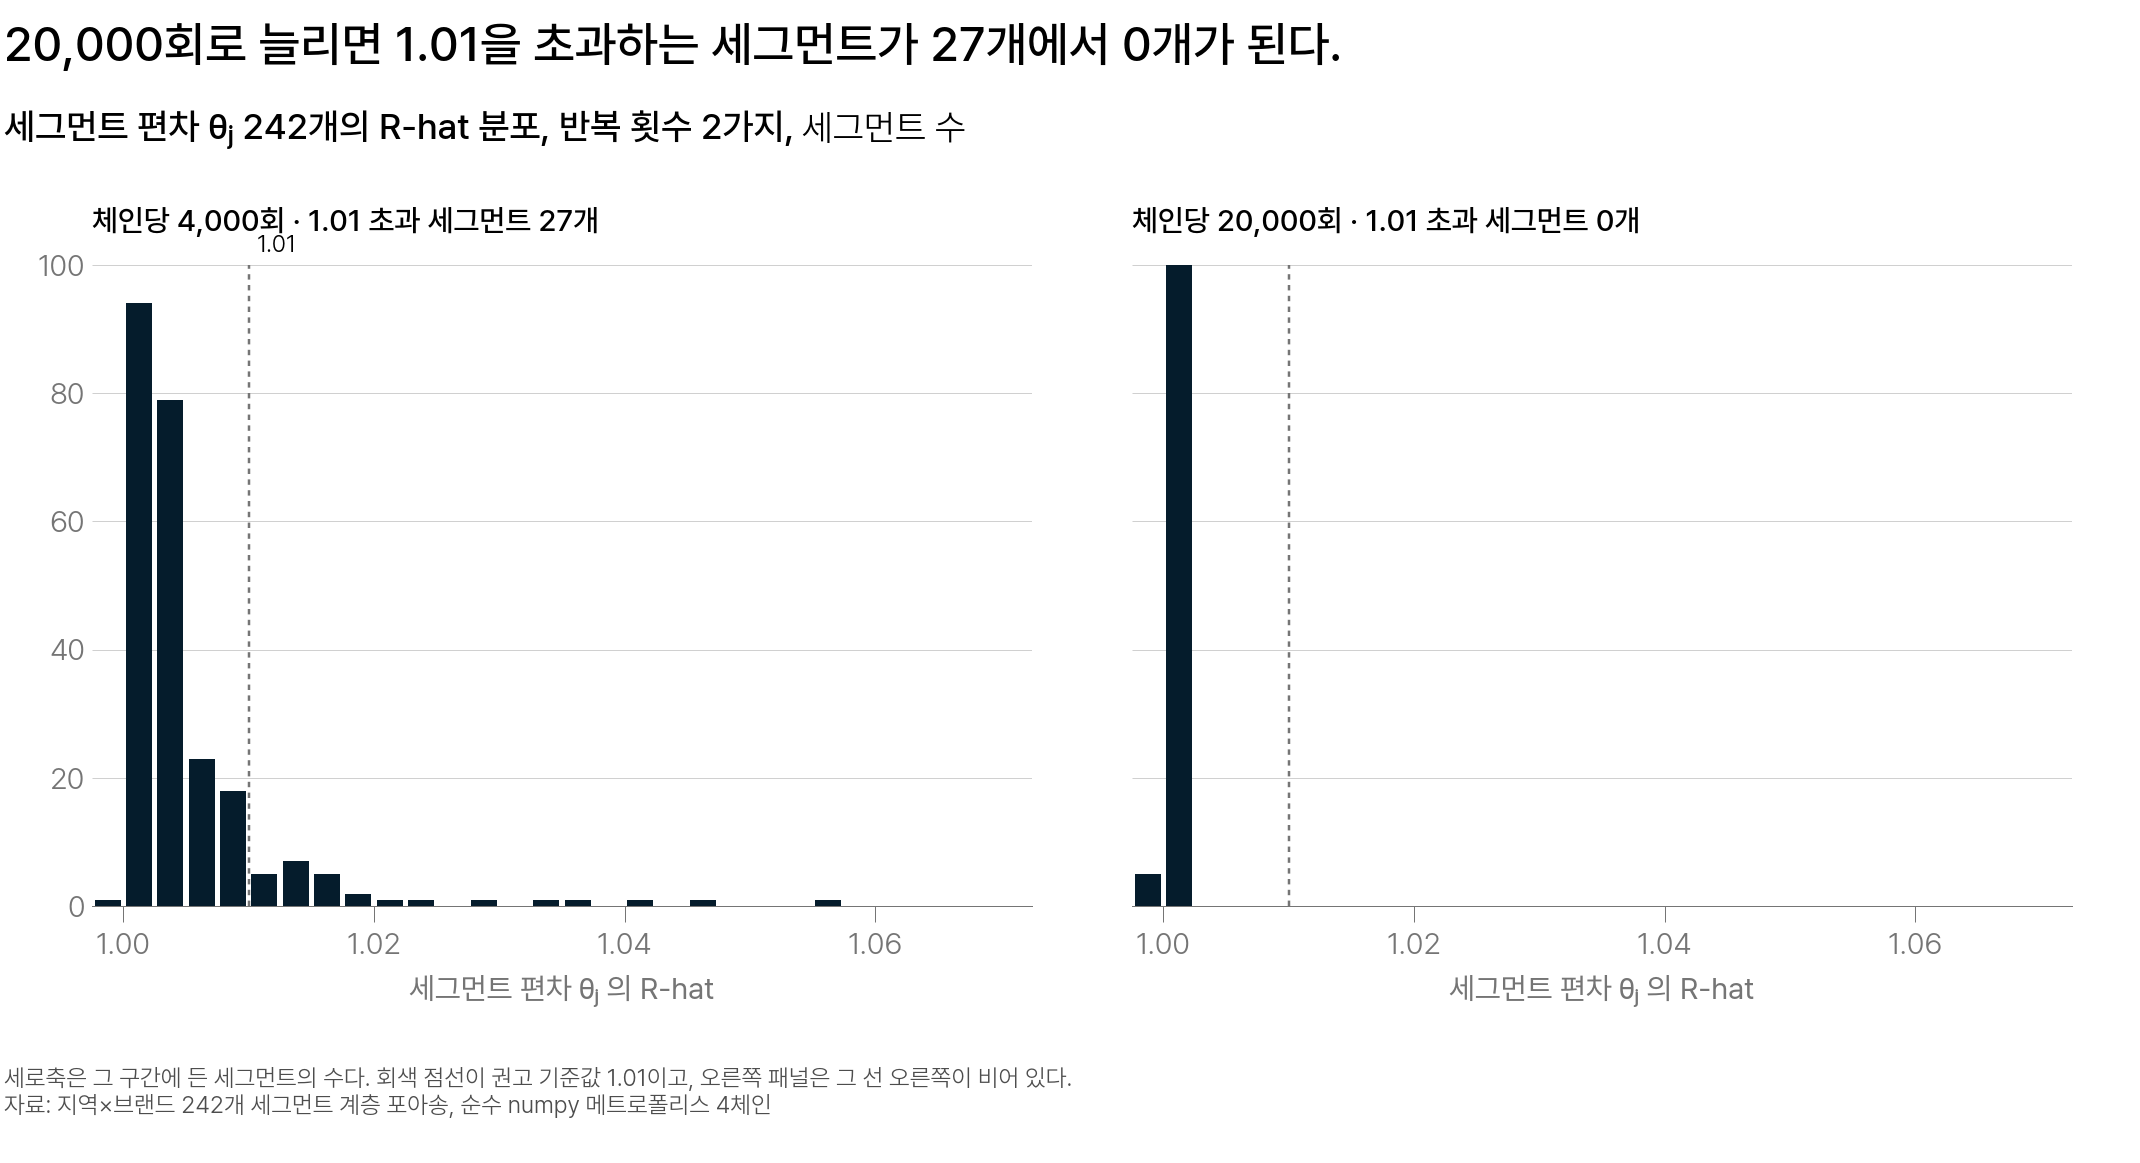

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 세그먼트 편차 θⱼ 242개의 R-hat 분포 — 회색 점선이 권고 기준값 1.01 이다 — 반복 4,000회에서는 세그먼트 27개가 선 오른쪽에 있고 20,000회에서는 그 구간이 비어 있다.</em></p>

기준값을 초과한 세그먼트가 27개에서 0개가 됩니다. 반복 횟수 2가지를 표로 대조합니다.

| 체인당 반복 횟수 | 실행 시간(초) | $\hat{R}(\mu)$ | 유효표본수 $\mu$(ess_bulk, 개) | $\theta_j$ 중 $\hat{R}$ 1.01 초과 | $\theta_j$ 중 유효표본수 400 미만 | $\lambda_j$ 중 유효표본수 400 미만 |
|---:|---:|---:|---:|---:|---:|---:|
| 4,000 | 0.8 | **1.0830** 미통과 | 47 미통과 | **27 / 242** | 21 / 242 | 0 / 242 |
| 20,000 | 4.1 | 1.0031 통과 | **330 미통과** | **0 / 242** | 0 / 242 | **0 / 242** |

반복 20,000회에서 세그먼트 편차 $\theta_j$ 242개도, 앞에서 읽은 세그먼트별 연간 사고율 $\lambda_j = e^{\mu + \theta_j}$ 242개도 두 기준값을 모두 통과했습니다. 연간 사고율 $\lambda_j$ 의 유효표본수는 가장 적은 세그먼트가 5,105개이고, 세그먼트 편차 $\theta_j$ 는 가장 적은 세그먼트가 544개로 기준값 400 을 넘습니다.

통과하지 못한 것은 공통 평균 $\mu$ 하나입니다. 유효표본수 330개가 기준값 400 에 미치지 못합니다. 그래서 앞에서 읽은 $\mu$ 의 사후평균과 그 값을 복원한 0.096 건/년도 다시 표집하기 전까지 요율표에 옮기지 않습니다.

$\lambda_j$ 가 식 안에 $\mu$ 를 포함하고도 통과하는 이유는 두 값의 표준편차가 다르기 때문입니다. 로그 스케일에서 $\mu$ 의 표준편차는 0.019 이고 세그먼트 편차 $\theta_j$ 의 표준편차는 중앙값이 0.132 라, 합 $\mu + \theta_j$ 가 이동하는 거리는 7배 큰 $\theta_j$ 가 결정합니다. 그래서 합 $\mu + \theta_j$ 는 이웃한 표본끼리 $\mu$ 보다 덜 닮고, 그만큼 유효표본수가 커집니다.

표본 수를 늘리면 체인의 표본 분포가 정확한 분포에 겹쳐 간다는 것은 다른 예에서도 같습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Metropolis_algorithm_convergence_example.png" width="600" height="601"/>
<p align="center"><em>▲ 표본 수를 100개에서 50,000개까지 늘려 가며 그린 사후분포의 밀도 — 주황이 체인으로 얻은 표본이고 파랑이 정확한 분포다 — 100개에서는 밀도가 높은 구간 2개 중 오른쪽이 맞지 않고 5,000개부터 두 곡선이 겹친다 (출처: Wikipedia)</em></p>

「몇 개 추출하면 되는가」의 답이 반복 횟수 2가지를 대조한 위 표입니다. 정해진 수는 없고 통과할 때까지 늘립니다.

**다만 먼저 조정할 설정값이 반복 횟수는 아닙니다.** 실무 도구의 첫 조치는 **표집기를 기본값으로 두는 것**입니다. 계층 모형의 사후분포에서 표본을 추출하는 파이썬 라이브러리 PyMC 의 기본 표집기 NUTS 는 제안 표준편차가 필요 없는 방식이라(4번 주제 「더 깊이」의 ⑵) 기울기를 따라 같은 반복 횟수로 훨씬 멀리 이동합니다.

<details class="lms-extra"><summary>자세히 — 기본 표집기로 바꾼 뒤 확인할 것</summary>

기본 표집기로 바꾸면 확인할 진단값이 하나 더 붙습니다. divergence 는 체인이 밀도가 급히 꺾이는 구간을 제대로 지나지 못해 버려지는 걸음입니다. 「There were N divergences」 경고가 나오면 그 표본은 요약에 쓰지 않고, 수용률 목표값인 `target_accept` 를 0.9 로 높이거나 세그먼트 편차를 $\tau \times z$ 형태로, 곧 $\theta_j \sim N(0,\ \tau^2)$ 를 $\tau$ 와 $z$ 의 곱으로 바꿔 적어 경고가 0건이 된 뒤에 읽습니다.

</details>

#### 핵심 주의점

$\hat{R}$ 가 기준값 이하인 것을 표본이 충분하다는 증명으로 읽으면 안 됩니다. 두 진단값 가운데 하나만 통과한 표본은 요약에 쓰지 않습니다.

> **$\hat{R} = 1.0031$ 은 체인 4개가 갈라지지 않았다는 신호 하나이고, 사후평균은 유효표본수가 기준값 400 이상임을 함께 확인한 뒤에 적습니다.**

**그래서** 요약에 써도 된다고 판정한 것은 반복 20,000회 표본 가운데 두 진단값을 통과한 부분뿐입니다. 세그먼트별 연간 사고율 $\lambda_j$ 242개는 그대로 읽고, **공통 평균 $\mu$ 하나는 실습 미션 2 에서 NUTS 로 다시 표집한 뒤에 읽습니다**. 요율표에 적을 값은 이어지는 「6. 사전 강도를 데이터로 추정」의 이항 모형에서 따로 나옵니다.

> **[문제] R-hat 이 기준값 1.01 보다 작은 1.005 로 통과했다면 그 체인의 유효표본수도 자동으로 기준값 400 이상이 된다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 6. 사전 강도를 데이터로 추정

**여기서 할 일**

1. 둘째 날 사람이 지정한 102건을 데이터는 몇 건으로 추정하는지 확인합니다.
2. 세그먼트 간 표준편차 $\tau$ 를 사전 강도의 단위, 곧 가상 관측 건수로 환산합니다.
3. 두 사전분포와 양쪽 극단의 방식을 같은 세그먼트에 적용해 값을 대조합니다.

**여기서 다루는 값** — 사고 경험률 $p$(단위 없는 비율), 지역×브랜드×차량 출력 2,323개 세그먼트.

사고 경험률은 계약 가운데 기간 중 사고를 겪은 계약이 차지하는 비율입니다. 계약 63건 가운데 4건이 사고를 겪었으면 $4 \div 63 = 0.063$ 이고, 앞에서 쓴 연간 사고율은 건/년이라 단위가 다릅니다.

여기서부터 세그먼트 분할과 모형이 바뀝니다. 앞에서는 지역×브랜드 242개 세그먼트를 포아송 모형으로 적었고, 여기서부터는 지역×브랜드×차량 출력 2,323개 세그먼트를 이항 모형으로 적습니다. 이항 모형은 계약 하나하나가 기간 중 사고를 겪었는가 아닌가를 기록해 그 건수를 집계하는 모형입니다. 이 값에는 노출이 들어가지 않습니다. 계약 하나를 사고 유무로만 보므로 평균 보장 기간이 짧은 세그먼트가 낮게 나올 수 있습니다. 그래서 이 분할로 적는 표는 세그먼트마다 수축의 크기를 대조하는 데 쓰고, 실제 요율은 노출을 오프셋(추정하지 않고 이미 아는 값으로 모형에 넣는 항)으로 둔 빈도 모형에서 따로 계산합니다.

바꾸는 이유는 하나입니다. 오늘 대조할 대상인 둘째 날의 사전분포 Beta(6, 96) 이 사고 경험률로 정의되어 있어서, 사전 강도를 같은 단위로 대조하려면 같은 값을 쓰는 모형이 필요합니다.

「오늘 배울 것」에서 제시한 계약 63건 세그먼트도 이 2,323개 분할에 속합니다. 아래에서 값을 대조하는 대상이 그 세그먼트입니다. 여기서부터 적는 값은 표집기를 PyMC 의 NUTS 로 바꾼 표본에서 나왔고, 실습 과제의 준비 셀이 그 두 진단값을 출력합니다.

앞에서 사전 강도가 크다는 말을 사전분포가 이미 많은 노출, 곧 400년치 노출을 본 것처럼 작동한다는 뜻으로 적었습니다. 여기서는 그것이 관측 몇 건에 해당하는지를 같은 방식으로 환산합니다.

**사전 강도(prior strength) $M$** 은 사전분포가 가상 관측 몇 건에 해당하는지를 나타내는 수입니다. 베타 사전분포면 $M = \alpha_0 + \beta_0$ 이고 단위는 관측과 같은 건입니다.

$\alpha_0$ 는 가상으로 사고를 겪은 건수이고 $\beta_0$ 는 사고를 겪지 않은 건수라, 둘을 더한 수가 가상 관측 전체입니다. 4번 주제에서 사후분포의 두 수를 사고 4건과 사고가 아닌 59건으로 읽은 것과 같은 덧셈입니다.

둘째 날의 Beta(6, 96) 은 $M = 6 + 96 = 102$ 건이고, 중심은 가상 관측 102건 가운데 사고를 겪은 6건의 비율 $6 \div 102 = 0.0588$ 입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Beta_distribution_pdf.svg" width="640" height="512"/>
<p align="center"><em>▲ 베타분포는 두 수 α₀·β₀(그림 범례에는 α·β 로 적혀 있다) 만으로 모양이 전부 정해진다 — 우리가 쓴 Beta(6, 96) 은 이 그림의 주황 곡선처럼 왼쪽에 몰린 모양이고, 두 수의 합이 클수록 분포가 좁아진다 (출처: Wikipedia)</em></p>

계층 모형의 $\tau$ 가 하는 일이 $M$ 이 하던 일과 같습니다. $\tau$ 가 작으면 세그먼트별 값이 공통 평균 가까이 모이고, $M$ 이 크면 추정값이 사전분포의 중심 가까이 모입니다. 그래서 $\tau$ 를 $M$ 의 단위로 환산하면 둘째 날의 102건과 나란히 대조할 수 있습니다.

둘이 어떻게 이어지는지 차례로 적으면 이렇습니다.

- $\tau$ 가 작다 → 세그먼트들이 서로 비슷하다 → 사전분포가 좁다 → $M$ 이 크다(강한 부분 풀링)
- $\tau$ 가 크다 → 세그먼트들이 많이 다르다 → 사전분포가 넓다 → $M$ 이 작다(약한 부분 풀링)

2,323개 세그먼트 이항 계층 모형의 $\tau$ 사후평균은 **0.2631** 입니다. 사후분포의 가운데 95% 를 자른 구간은 **[0.241, 0.287]** 입니다.

이 0.2631 은 확률을 직접 측정한 값이 아닙니다. 사고 경험률 $p$ 와는 단위가 다른 양이고, 셋째 날 로지스틱 회귀에서 쓴 **로짓 스케일**, 곧 확률 $p$ 를 $\log\dfrac{p}{1-p}$ 로 바꾼 좌표에서 측정한 세그먼트 간 표준편차입니다. 확률을 이 좌표로 옮기는 이유는 아래 「왜 로짓 스케일에서 측정하는가」 에 적었습니다.

로그를 취한 값과 로짓은 다릅니다. $p$ 가 0.05 면 $\log(0.05) = -2.996$ 이고 $\log(0.05 \div 0.95) = -2.944$ 입니다. 계층 모형이 쓰는 것은 뒤의 로짓이고, 7번 주제에 나오는 $-2.94$ 가 이 값입니다.

0.2631 이 어느 정도인지는 배수로 바꾸면 읽기 쉽습니다. $e^{0.2631} = 1.301$ 이고 $e^{-0.2631} = 0.769$ 입니다.

로짓은 $p \div (1-p)$ 에 로그를 취한 값이라, 로짓에 0.2631 을 더하는 것은 $p \div (1-p)$ 에 $e^{0.2631}$ 을 곱하는 것과 같습니다. 이 배수가 곱해지는 대상은 확률 $p$ 자체가 아니라 그 좌표에서 곱해지는 양인 $p \div (1-p)$ 입니다. 그래서 로짓 스케일에서 $\tau$ 를 한 번 더하고 뺀 이 범위, 곧 세그먼트의 약 68% 에서 $p \div (1-p)$ 가 계약 전체의 $p \div (1-p)$ 의 0.77배에서 1.30배 사이입니다.

확률로는 얼마인지 한 번 계산해 둡니다. $p$ 가 0.05 면 $p \div (1-p) = 0.0526$ 이고, 여기에 1.301 을 곱하면 0.0685 입니다.

이 값을 확률로 복원하는 계산은 나눗셈 한 번입니다. $0.0685 \div (1 + 0.0685) = 0.064$ 라 0.05 의 1.28배이고, 반대쪽도 같은 순서로 복원해 $0.0405 \div (1 + 0.0405) = 0.0389$ 이라 0.78배입니다. 이 나눗셈이 시그모이드이고, 곡선은 7번 주제에서 확인합니다.

계층 모형은 $\tau$ 도 다른 모수처럼 사후분포로 계산하므로, 값 하나가 아니라 그 값을 얼마나 확신하는지까지 함께 나옵니다.

이 표준편차를 확률 스케일로 옮긴 값이 베타 사전분포의 표준편차와 같다고 두고 풀면 환산식 하나가 나옵니다. 말로 먼저 적으면 세 단계입니다.

1. 세그먼트 간 표준편차의 제곱과 계약 전체 비율과 사고를 겪지 않은 비율을 모두 곱합니다.
2. 그 값으로 1 을 나눕니다.
3. 거기서 1 을 뺍니다.

그 결과가 **등가 사전 강도**입니다.

$$
M \approx \frac{1}{\tau^2\, \bar{p}(1-\bar{p})} - 1
$$

- $M$ : 등가 사전 강도입니다. 이 $\tau$ 가 가상 관측 몇 건에 해당하는지를 나타냅니다.
- $\tau$ : 방금 확인한 세그먼트 간 표준편차 0.2631 이고, 로짓 스케일에서 측정한 값입니다.
- $\bar{p}$ : 계약 전체의 사고 경험률 0.05024 입니다.

값을 대입합니다.

$$
M \approx \frac{1}{0.2631^2 \times 0.05024 \times 0.94976} - 1 = \frac{1}{0.003303} - 1 = 301.8
$$

이는 다음 뜻입니다.

- 이 $\tau$ 는 가상 관측 **약 300건**에 해당합니다.
- 둘째 날 사람이 지정한 102건의 3배에 가깝습니다.

$\tau$ 가 더 작을 때와 더 클 때 이 식이 무엇이 되는지도 같은 대입으로 확인합니다.

- $\tau = 0.05$ 를 대입하면 $M$ 이 8,382건입니다. 세그먼트마다 얹는 가상 관측이 그만큼 많아 값이 계약 전체 값 가까이 모여 완전 풀링 쪽에 가깝습니다.
- $\tau = 0.5$ 를 대입하면 $M$ 이 82.8, 곧 약 83건입니다. 계약 63건 세그먼트에 83건을 얹으면 자기 데이터의 비중이 $63 \div (63 + 83) = 0.43$ 이라 절반 가까이로 커집니다.

$\tau$ 의 95% 구간 [0.241, 0.287] 의 두 끝을 같은 식에 대입하면 $M$ 이 각각 360건과 254건입니다. 약 300건은 한 점이 아니라 250건에서 360건 사이의 값이고, 102건은 그 밖에 있습니다.

그래서 이 데이터에서 읽은 사전 강도는 102건이 아니라 약 300건입니다.

<details class="lms-extra"><summary>자세히 — τ 를 가상 관측 건수로 바꾸는 환산</summary>

**본문에서 결과만 적은 $M \approx 1/[\tau^2 \bar{p}(1-\bar{p})] - 1$ 이 어디에서 나오는지 한 단계씩 적어 둡니다.**

**⑴ 두 모형을 같은 양으로 대조할 수 있게 맞춥니다.** 계층 모형은 로짓 스케일에서 $\theta_j \sim N(0, \tau^2)$ 이라 적고, 베타 사전분포는 확률 스케일에서 $p_j \sim \text{Beta}(\alpha_0, \beta_0)$ 이라 적습니다. 스케일이 다르니 곧장 대조할 수 없습니다. 대조할 수 있는 것은 세그먼트별 값이 얼마나 흩어져 있는가, 곧 분산 하나입니다.

**⑵ 베타 쪽 분산을 적습니다.** $\text{Beta}(\alpha_0, \beta_0)$ 의 분산은 $M = \alpha_0 + \beta_0$ 와 중심 $\bar{p} = \alpha_0/M$ 으로 이렇게 적힙니다.

$$
\mathrm{Var}(p) = \frac{\bar{p}(1-\bar{p})}{M + 1}
$$

**⑶ 계층 쪽 분산을 같은 스케일로 옮깁니다.** $\theta$ 는 로짓 스케일의 값이고 $p = \text{sigmoid}(\mu + \theta)$ 입니다. 스케일을 옮기는 규칙이 하나 필요한데 **델타 방법**입니다.

산포가 작으면 함수 $g$ 를 중심 부근에서 직선으로 근사할 수 있습니다. 직선은 기울기만큼 산포를 늘리므로 분산은 **기울기의 제곱**만큼 커집니다.

$$
\mathrm{Var}(g(\theta)) \;\approx\; \left[g'(\text{중심})\right]^2 \times \mathrm{Var}(\theta)
$$

- $g$ : 로짓 스케일의 값을 확률로 복원하는 함수, 곧 시그모이드입니다.
- $g'(\text{중심})$ : 그 함수의 미분을 중심에서 계산한 값입니다.
- $\mathrm{Var}(\theta)$ : 로짓 스케일에서 계산한 분산이고 $\tau^2$ 입니다.

시그모이드의 미분은 $p(1-p)$ 이므로 중심 $\bar{p}$ 에서 계산하면 $\bar{p}(1-\bar{p})$ 입니다. 작은 수로 확인하면 $\bar{p} = 0.05024$ 일 때 기울기가 $0.05024 \times 0.94976 = 0.0477$ 이라, 로짓 스케일에서 계산한 분산이 확률 스케일로 옮겨질 때 $0.0477^2$ 배가 됩니다. 위 규칙의 두 항에 각각 대입합니다.

$$
\mathrm{Var}(p) \;\approx\; \left[\bar{p}(1-\bar{p})\right]^2 \tau^2
$$

직선으로 근사한 식이라 산포가 작을 때만 성립하고 $\tau$ 가 크면 맞지 않습니다. 우리 $\tau$ 는 0.26 이라 이 근사를 쓸 수 있습니다.

**⑷ 두 식을 같다고 둡니다.**

$$
\frac{\bar{p}(1-\bar{p})}{M + 1} = \left[\bar{p}(1-\bar{p})\right]^2 \tau^2
$$

양변을 $\bar{p}(1-\bar{p})$ 로 나눕니다.

$$
\frac{1}{M+1} = \bar{p}(1-\bar{p})\, \tau^2
$$

양변의 역수를 취합니다.

$$
M + 1 = \frac{1}{\tau^2\, \bar{p}(1-\bar{p})}
$$

양변에서 1 을 빼면 본문의 식입니다.

$$
M = \frac{1}{\tau^2\, \bar{p}(1-\bar{p})} - 1
$$

**⑸ 값을 대입합니다.** $\tau$ 를 제곱합니다.

$$
\tau^2 = 0.2631^2 = 0.069222
$$

$\bar{p}$ 와 $1-\bar{p}$ 를 곱합니다.

$$
\bar{p}(1-\bar{p}) = 0.05024 \times 0.94976 = 0.047716
$$

두 값을 곱합니다.

$$
0.069222 \times 0.047716 = 0.003303
$$

역수를 취하고 1 을 뺍니다.

$$
M = \frac{1}{0.003303} - 1 = 301.8
$$

**검산해 보겠습니다.** 301.8 을 다시 두 모수로 나누면 중심 쪽이 $\alpha_0 = 0.05024 \times 301.8 = 15.2$ 이고 나머지가 $\beta_0 = 301.8 - 15.2 = 286.6$ 입니다. 그 중심을 다시 계산하면 $15.2 \div 301.8 = 0.0504$ 로, 출발점인 계약 전체의 사고 경험률 0.0502 와 소수점 아래 3자리까지 같습니다.

**그래서 무엇이 달라졌는가.** $\tau$ 는 로짓 스케일의 표준편차라 그 자체로는 크기를 가늠하기 어렵습니다. 가상 관측 건수로 환산하면 둘째 날 사람이 지정한 수와 나란히 대조할 수 있습니다. 이 환산은 근사라 소수 자리를 다투는 데는 쓸 수 없지만 102건과 301.8건을 대조하는 데는 충분합니다.

</details>

#### 왜 로짓 스케일에서 측정하는가

계층 모형은 세그먼트 편차를 공통 평균에 더해서 값을 만듭니다. 확률에 편차를 그대로 더하면 0 보다 작거나 1 보다 큰 값이 나오는데, 로짓 스케일에서 더한 값은 어떤 수가 되어도 시그모이드로 복원하면 0 과 1 사이에 들어옵니다. 확률 0.05 의 로짓은 $\log(0.05 \div 0.95) = -2.94$ 입니다. 앞에서 0.0685 를 0.064 로 되돌린 나눗셈이 그 시그모이드입니다.

#### 왜 400년과 300건을 곧장 대조하지 않는가

오늘 다른 세그먼트에서 가져오는 정보량을 나타내는 수가 셋입니다.

| 이름 | 단위 | 어느 모형에서 나오는가 | 크기를 대조할 수 있는가 |
|---|---|---|---|
| 가상 노출 $B$ 약 400년 | 년 | 연간 사고율 $\lambda$, 지역×브랜드 242개 세그먼트 포아송 | 바로 아래 행과만 |
| 위젯 화면의 `사전 강도 β₀` | 년 | 화면이 바로 위 행과 같은 수를 다른 이름으로 부른 것 | 바로 위 행과 같은 수입니다 |
| 사전 강도 $M$ 약 300건 | 건 | 사고 경험률 $p$, 지역×브랜드×차량 출력 2,323개 세그먼트 이항 | 둘째 날의 102건과만 |

첫 행과 마지막 행은 단위가 년과 건으로 달라 크기를 곧장 대조하지 않습니다. 둘 다 사전 강도이고 구실이 같습니다. 크면 사전분포가 세서 수축이 강하고, 작으면 약합니다. 다만 사전분포가 담은 정보량을 그 모형의 관측 단위로 옮기는 식은 모형마다 달라서, 400년은 가중치에서 역산했고 300건은 분산을 맞춰 환산했습니다.

둘째 행의 $\beta_0$ 는 앞에서 베타 사전분포의 둘째 모수로 적은 $\beta_0$ 와 이름만 같고 뜻이 다릅니다. 화면의 $\beta_0$ 는 가상 노출 년이고, Beta(6, 96) 의 96 은 가상 관측 건입니다.

아래 코드는 두 사전분포를 같은 세그먼트에 적용합니다.

In [ ]:
# 사람이 지정한 사전분포와 데이터로 추정한 사전분포를 같은 세그먼트에 적용하면
import numpy as np

k, n = 4, 63                       # 63건 세그먼트
p_pool = 0.05024                   # 전체 계약 비율 (계약 678,013건)
tau = 0.2631                       # 2,323개 세그먼트 계층 모형이 추정한 세그먼트 간 표준편차

M_data = 1.0 / (tau ** 2 * p_pool * (1 - p_pool)) - 1
print(f"tau {tau} 를 사전 강도로 환산하면 M = {M_data:.1f} 건\n")

for lab, a0, b0 in [("둘째 날 사람이 지정한 Beta(6, 96)", 6.0, 96.0),
                    ("데이터로 추정한 사전분포", p_pool * M_data, (1 - p_pool) * M_data)]:
    M = a0 + b0
    center = a0 / M
    mode = (a0 + k - 1) / (M + n - 2)          # MAP — 사후 최고점
    mean = (a0 + k) / (M + n)                  # 사후평균
    print(f"{lab}")
    print(f"   중심 {center:.4f} · 사전 강도 M = {M:.1f} 건")
    print(f"   MAP {mode:.4f}   사후평균 {mean:.4f}")

print("\n계층 모형의 사후평균                0.0503  [0.0312, 0.0759]")
print("무 풀링(그 세그먼트만 보기)     0.0635")

행 3개를 나란히 대조합니다. 표의 **MAP** 은 사후분포가 가장 높은 지점의 값입니다. 둘째 날 그 세그먼트에 적은 값이 MAP 이라, 여기서도 MAP 끼리 대조합니다.

| | 중심 | 사전 강도 $M$ | 그 세그먼트의 MAP | 그 세그먼트의 사후평균 |
|---|---:|---:|---:|---:|
| 둘째 날 사람이 지정한 사전분포 | 0.0588 | 102건 | **0.0552** | 0.0606 |
| 데이터로 추정한 사전분포 | 0.0502 | 301.8건 | **0.0501** | 0.0525 |
| 계층 모형 | | | | **0.0503** |

지금 대조하는 것은 위 두 행의 MAP 2개뿐입니다. 사람이 지정한 사전분포의 0.0552 에서 데이터로 추정한 사전분포의 **0.0501** 로 감소합니다.

감소한 데는 이유가 2가지입니다. 사전 강도가 102건에서 301.8건으로 커졌고 **중심도 0.0588 에서 0.0502 로 감소했습니다.**

값을 낮춘 쪽은 중심입니다. 사전 강도가 커진 것은 그 낮아진 중심 쪽으로 수축을 더 크게 만드는 역할이라, 두 요인이 함께 0.0552 를 0.0501 로 옮겼습니다.

셋째 행의 0.0503 은 이 이항 계층 모형이 계산한 사후평균이고 위 두 행과 계산 방식이 달라 이 표에서는 대조하지 않습니다. 오늘 요율표에 적을 값이 그 셋째 행입니다.

위 표와 아래 그림은 역할이 다릅니다. 표는 사전 강도를 바꾸었을 때 MAP 이 어떻게 달라지는지를 대조하고, 그림은 같은 세그먼트를 추정하는 방법 4개의 값을 한 눈금에 나란히 배치합니다. 표의 둘째 날 MAP 과 계층 모형의 사후평균에 양쪽 극단인 무 풀링과 완전 풀링을 더하면 방법 4개가 됩니다.

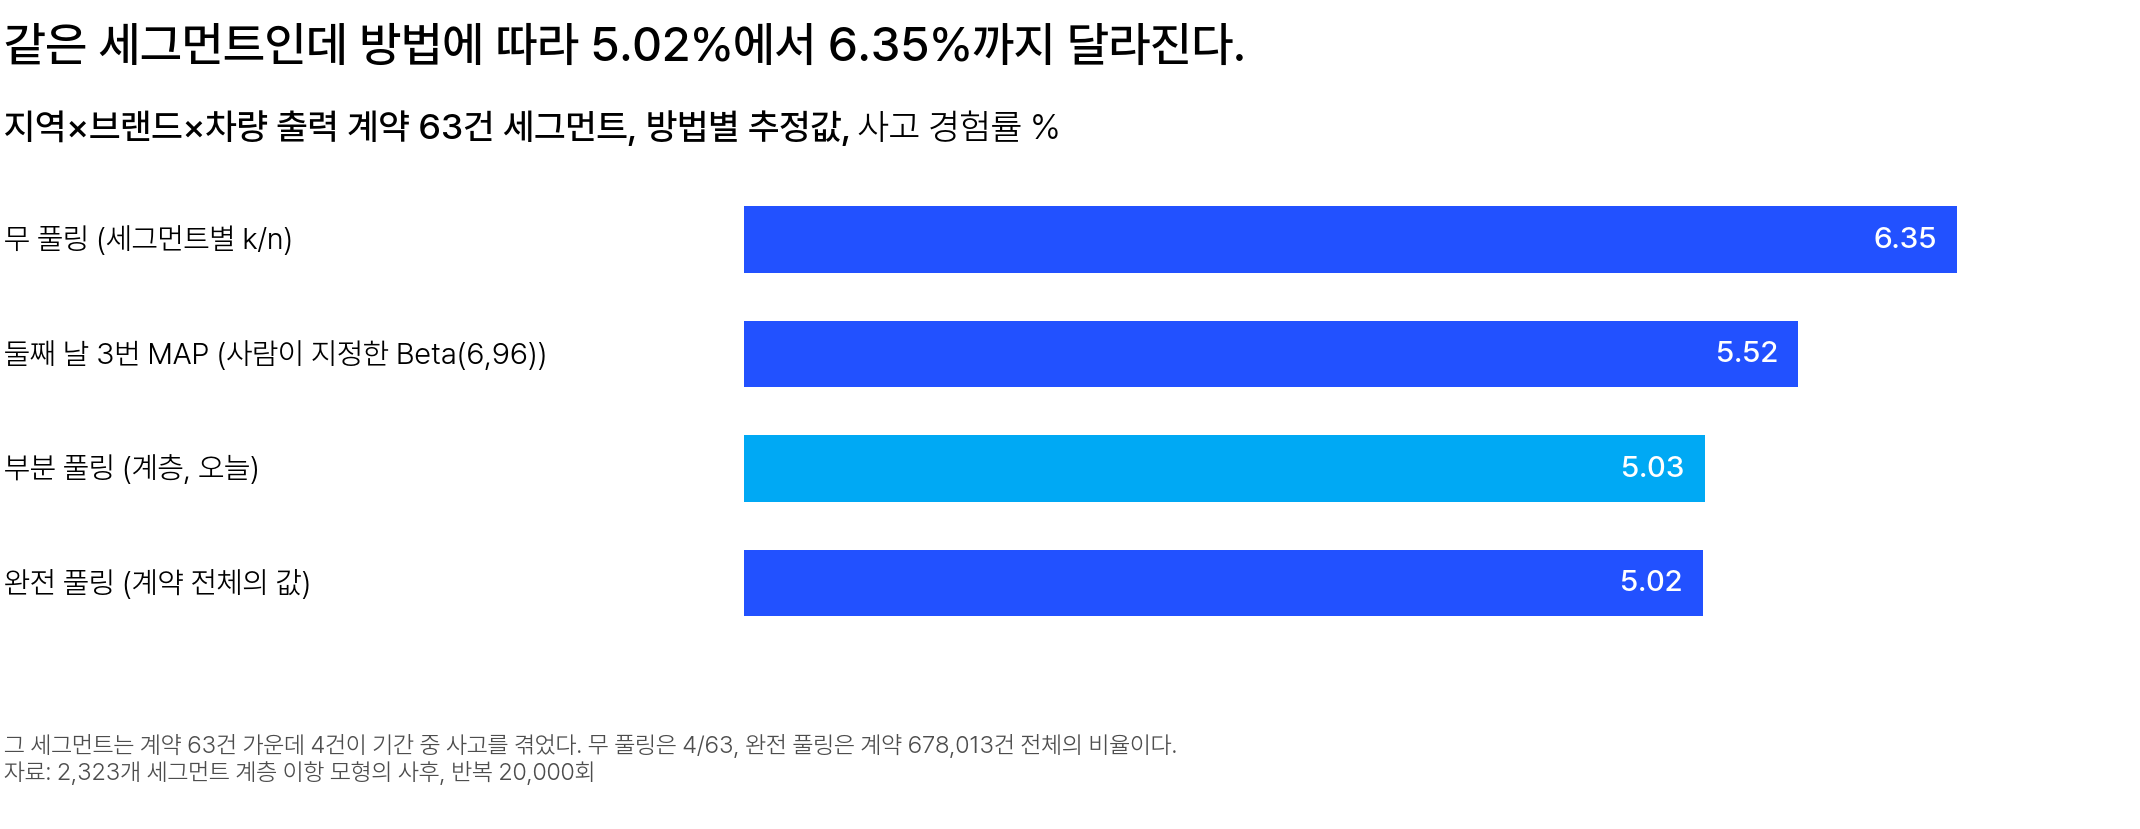

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계약 63건인 세그먼트 1개에 방법 4개를 적용한 값 — 하늘색이 오늘의 부분 풀링이다 — 같은 세그먼트인데 5.02% 부터 6.35% 까지 달라지고, 부분 풀링은 완전 풀링에 거의 근접한다.</em></p>

그림의 값은 표의 비율에 100 을 곱해 % 로 적은 것입니다. 표의 0.0552 가 그림의 5.52% 이고, 계층 모형의 0.0503 이 5.03% 입니다. 위 그림은 방법마다 대표값 하나씩을 한 눈금에 나란히 배치해, 값이 어디에서 어디까지 놓이는지를 봅니다.

무 풀링 6.35% 와 완전 풀링 5.02% 의 차이가 1.33%p 입니다. 오늘의 부분 풀링이 그 사이에서 완전 풀링 쪽에 거의 근접한 이유는 계약 63건으로는 계약 전체에서 벗어났다고 말할 근거가 부족했기 때문입니다.

**그래서** 처음에 「적당해 보인다」로 지정하던 사전 강도를 데이터에서 얻었습니다. 둘째 날에는 사전분포의 중심과 사전 강도를 둘 다 사람이 지정했고, 계층 모형은 중심을 계약 전체의 값으로 두고 사전 강도를 세그먼트 간 표준편차가 정하게 만듭니다. 그러면 이렇게 얻은 값과 구간을 요율표에 어떻게 옮기는지가 다음 질문입니다.

> **세그먼트 간 표준편차 $\tau$ 를 가상 관측 건수로 환산한 값이 약 300건이고, 사전 강도를 사람이 지정하지 않고 데이터에서 얻는다는 것이 오늘 바뀐 부분입니다.**

> **[문제] 데이터로 추정한 사전 강도를 대입했을 때 값이 더 감소한 이유**
>
> 둘째 날 사람이 지정한 사전분포는 그 세그먼트에 MAP 0.0552 를 주었고, 데이터로 추정한 사전분포는 0.0501 을 주었습니다. 표에 적힌 두 사전분포의 **중심**과 **사전 강도**를 각각 대조해, 값이 0.0051 만큼 감소한 데 두 요인이 어떻게 함께 작용했는지 두 문장으로 적어 보세요.

## 7. 요율표에 적는 값: 신용구간과 상대 구간 길이

**여기서 할 일**

1. 계약 63건 세그먼트의 구간이 첫날과 오늘 어떻게 다른지 봅니다.
2. 오늘의 구간이 왜 짧아졌는지 확인합니다.
3. 계층 모형이 로짓 스케일에서 준 값을 확률로 복원하는 방법을 확인합니다.
4. 상대 구간 길이로 요율표를 두 분류로 나누는 기준을 정합니다.

**여기서 다루는 값** — 사고 경험률 $p$(단위 없는 비율), 지역×브랜드×차량 출력 2,323개 세그먼트.

이제 「오늘 배울 것」의 63건 세그먼트로 돌아갑니다. **신용구간(credible interval)** 은 사후분포의 가운데 일정 비율을 잘라 낸 구간이고, 자른 비율은 값과 함께 적습니다. 「4. MCMC: 사후분포를 식으로 적을 수 없을 때 표본으로 얻는 방법」에서 익힌 방식으로 「6. 사전 강도를 데이터로 추정」의 이항 계층 모형에서 모은 사후 표본을 작은 값부터 차례로 나열하고, 아래에서 2.5% 지점과 97.5% 지점의 값을 읽으면 그 둘이 구간의 두 끝입니다.

자른 비율은 고른 값입니다. 99% 로 정하면 구간이 길어지고 50% 로 정하면 짧아지며, 오늘은 가운데 95% 를 씁니다.

넷째 날 부트스트랩의 신뢰구간은 표본을 다시 추출했을 때 그 절차가 만드는 구간의 95% 가 참값을 담는다는 규칙이라 뜻이 다릅니다.

첫날 그 세그먼트의 구간은 $\pm 2\,\mathrm{SE}$ 로 계산했습니다. 여기서 $\mathrm{SE}$ 는 표준오차, 곧 같은 크기 표본을 다시 뽑을 때 추정값이 흔들리는 정도입니다. 첫날 「3. MLE — 가장 그럴듯한 모수 찾기」에서 추정값의 위아래로 $2\,\mathrm{SE}$ 씩인 구간이 다시 뽑을 때마다 참값을 약 95% 담는다고 확인했으니, 오늘의 95% 신용구간과 길이를 나란히 견줄 수 있습니다.

$\hat{p}$(그 세그먼트에서 실제로 센 사고 경험률)가 $4/63 = 0.0635$ 이고, $\mathrm{SE} = \sqrt{0.0635 \times 0.9365 \div 63} = 0.03072$ 입니다.

구간이 추정값의 위아래로 각각 $2\,\mathrm{SE}$ 씩이라 길이는 $\mathrm{SE}$ 의 4배입니다. $4 \times 0.03072 = 0.12288$, 곧 12.29%p(%p 는 퍼센트끼리의 차)가 첫날의 구간 길이였습니다.

아래 그림의 부분 풀링 값 5.03% 와 구간은 「6. 사전 강도를 데이터로 추정」에서 얻은 계층 모형 사후평균 0.0503 과 그 95% 신용구간입니다.

같은 세그먼트에 규칙 2개를 나란히 적용합니다.

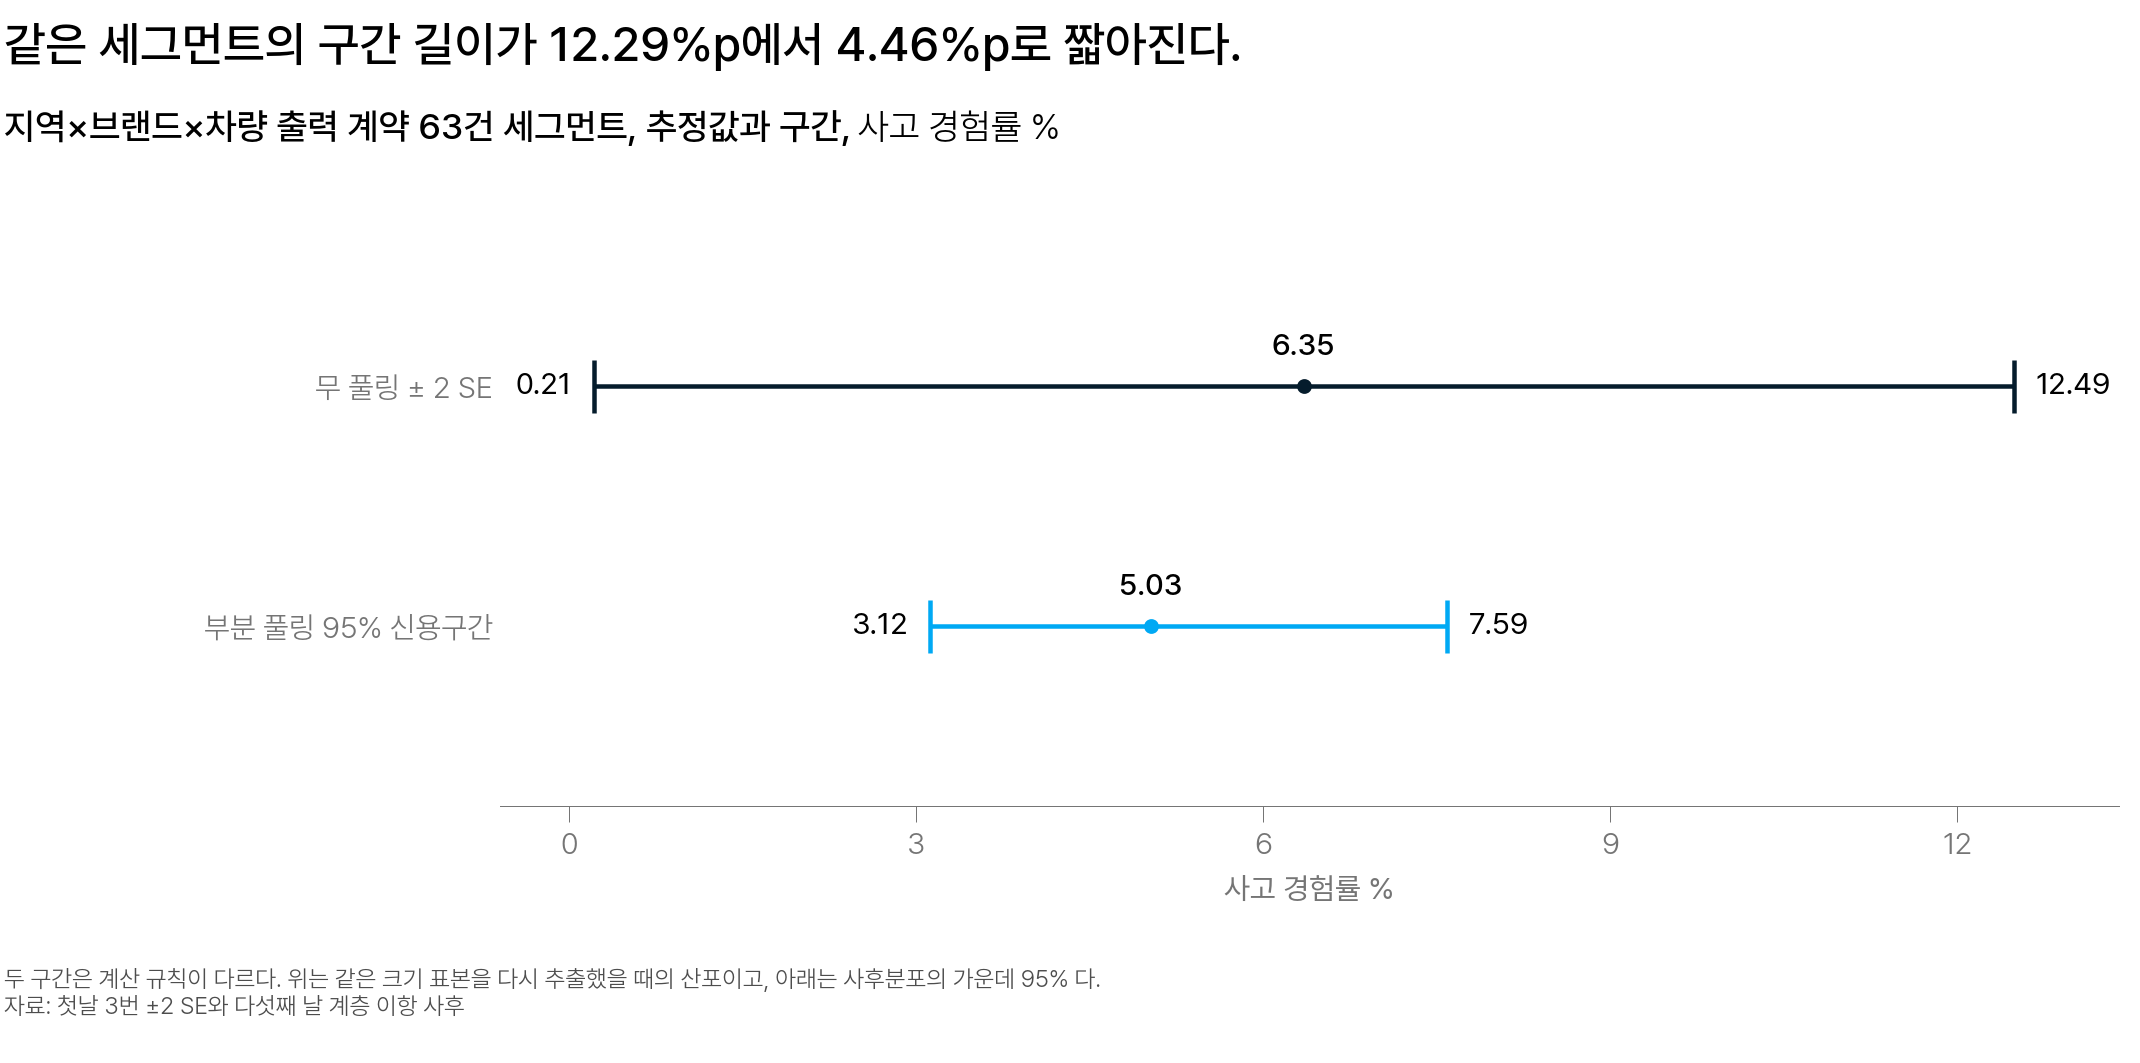

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계약 63건인 세그먼트를 규칙 2개로 계산한 구간 — 위가 첫날의 ±2 SE, 아래가 오늘의 95% 신용구간이다 — 값은 조금 감소했을 뿐인데 구간 길이가 3분의 1 남짓으로 짧아졌다.</em></p>

구간 길이가 **64% 줄었습니다**. 이 세그먼트의 데이터는 첫날과 한 건도 달라지지 않았습니다. 계약을 더 모은 것이 아니라 **다른 세그먼트에서 정보를 가져온 것**입니다.

| | 값 | 구간 | 구간 길이 | 상대 구간 길이 |
|---|---:|---|---:|---:|
| 무 풀링 $\pm 2\,\mathrm{SE}$ (첫날) | 6.35% | [0.21%, 12.49%] | **12.29%p** | **1.94** |
| 부분 풀링 95% 신용구간 (오늘) | 5.03% | [3.12%, 7.59%] | **4.46%p** | **0.89** |

구간 끝값은 소수점 아래 둘째 자리로 반올림했고, 구간 길이는 반올림 전 값에서 계산했습니다.

#### 왜 계층 모형의 구간이 더 좁아지는가

이 세그먼트만 보면 사고가 4건뿐입니다. 이 데이터만으로는 사고 경험률을 정밀하게 알기 어렵고, 그래서 첫날의 구간이 12.29%p 로 넓었습니다.

계층 모형은 나머지 2,322개 세그먼트의 정보를 이 세그먼트에 가져옵니다. 「2. 부분 풀링과 계층 모형」에서 적은 부분 풀링입니다.

- 값이 6.35% 에서 5.03% 로 계약 전체의 값 쪽으로 이동합니다.
- 관측이 적은 세그먼트의 극단적인 값이 완화됩니다.
- 불확실성이 줄어듭니다.
- 구간이 12.29%p 에서 4.46%p 로 짧아집니다.

대가는 가정 하나입니다. 이 세그먼트의 값이 다른 세그먼트들과 같은 분포를 따른다는 가정이고, 그 가정이 틀리면 짧아진 구간이 참값을 포함하지 못할 수 있습니다.

#### 어떻게 계층 모형의 값을 확률로 복원하는가

로짓은 확률 $p$ 를 $\log[p/(1-p)]$ 로 바꾼 값이고, 앞 표의 5.03% 는 계층 모형이 로짓 스케일에서 준 값을 확률로 복원한 것입니다. 「6. 사전 강도를 데이터로 추정」에서 쓴 이항 계층 모형은 세그먼트 편차를 로짓 스케일에서 더하므로 여기서도 같은 스케일을 쓰고, 그 값을 확률로 복원하는 함수가 **시그모이드(sigmoid)** 입니다.

복원하는 식을 말로 적으면 「확률 = 1 ÷ (1 + $e^{-\text{로짓 값}}$)」이고, 기호로는 이렇습니다.

$$
p = \frac{1}{1 + e^{-x}}
$$

- $x$ : 로짓 스케일의 값이고, 공통 평균에 세그먼트 편차를 더한 수입니다.
- $p$ : 복원한 확률이고 여기서는 사고 경험률입니다.

작은 수를 대입하면 $x = 0$ 에서 0.5 이고 $x = -3$ 에서 0.047 입니다.

계약 전체의 사고 경험률 0.05 의 로짓 $\log(0.05 \div 0.95) = -2.94$ 에 편차 0.26 을 더하면 $-2.68$ 입니다. 여기 쓴 0.26 도 같은 이항 계층 모형에서 데이터로 얻은 세그먼트 간 표준편차 0.2631 이고, 계약 전체의 값에서 1 표준편차만큼 떨어진 세그먼트를 예로 든 값입니다.

편차 0.26 을 확률 0.05 에 그대로 더하면 안 되는가. 이 작은 수가 확률로는 얼마인지 곡선으로 봅니다.

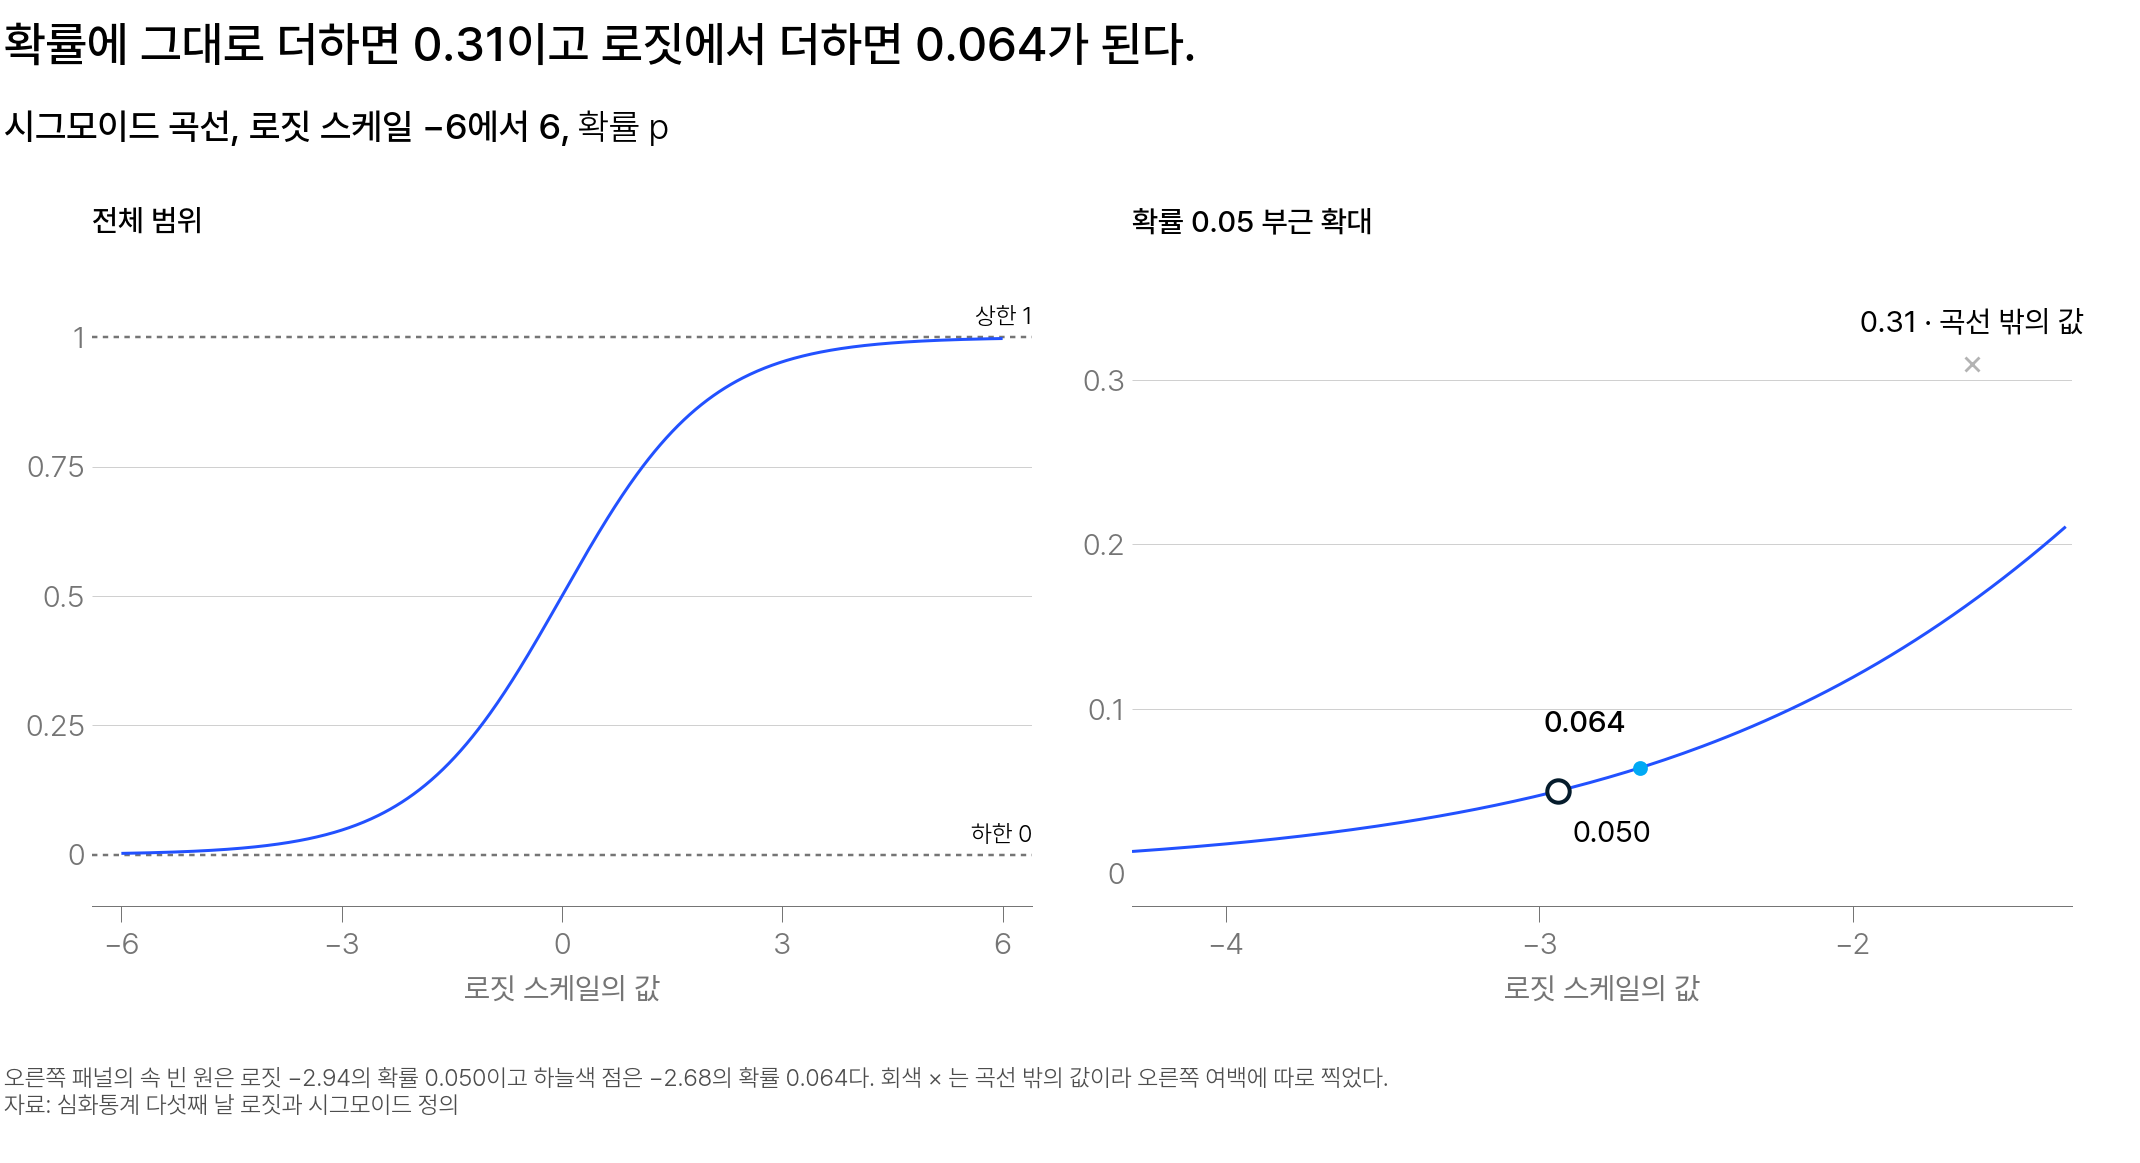

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 로짓 스케일의 값을 확률로 복원하는 시그모이드 곡선 — 왼쪽이 전체 범위, 오른쪽이 확률 0.05 부근을 확대한 패널이다 — 로짓에서 0.26 을 더한 뒤 복원하면 0.064 이고, 확률에 그대로 더한 0.31 은 로짓 스케일의 가로축에 좌표가 없어 회색 × 로 오른쪽 여백에 따로 찍었다.</em></p>

그림의 숫자를 식으로 잇습니다. $-2.68$ 을 대입하면 $1 \div (1 + e^{2.68}) = 0.064$ 입니다. 이는 다음 뜻입니다.

- 어떤 수를 대입해도 0 과 1 사이의 값이 나오므로, 편차를 아무리 더해도 확률이 그 범위를 벗어나지 않습니다.
- **무엇이 곤란한가.** 같은 편차 0.26 을 확률에 그대로 더하면 0.31, 곧 0.05 의 6.2배입니다. 로짓에서 더해 복원한 0.064 는 1.28배입니다. 0.31 은 로짓 $-2.68$ 의 위치에 찍을 수 없어 오른쪽 패널의 여백에 회색 × 로 따로 표시했습니다.

앞 표의 마지막 열에 있는 **상대 구간 길이**는 구간 길이 ÷ 요율표에 적으려는 값입니다.

상대 구간 길이를 기호로 옮기면 이렇습니다.

$$
\text{상대 구간 길이} = \frac{\text{구간 길이}}{\text{추정값}}
$$

- 구간 길이 : 위 끝에서 아래 끝을 뺀 값이고 단위는 %p 입니다.
- 추정값 : 요율표에 적으려는 사고 경험률이고 단위는 % 입니다. 상대 구간 길이는 %p 를 % 로 나눈 값이라 단위가 없습니다.

작은 수로 확인합니다. 사후평균이 5% 이고 구간이 3% 에서 8% 면 구간 길이는 5%p 이고 상대 구간 길이는 $5 \div 5 = 1.0$ 입니다.

앞 표의 두 행을 대입합니다.

$$
\frac{12.29}{6.35} = 1.94, \qquad \frac{4.46}{5.03} = 0.89
$$

이는 다음 뜻입니다.

- 첫날의 1.94 는 구간 길이가 값의 2배에 가깝다는 말입니다. 아래 끝 0.21% 와 위 끝 12.49% 로 매긴 보험료는 약 60배 차이인데, 첫날의 값으로는 어느 쪽인지 가릴 수 없었습니다.
- 오늘의 0.89 는 구간 길이가 값보다 짧습니다.

#### 왜 상대 구간 길이로 요율표를 두 분류로 나누는가

넷째 날 이론 마지막에 어느 세그먼트를 자동 승인하고 어느 세그먼트를 사람 심사로 보낼지 정하겠다고 적었고, 그 둘을 나누는 기준이 상대 구간 길이입니다.

- **1 보다 작으면 값을 적습니다.** 그 값을 그대로 요율표에 적는 자동 승인이고, 오늘 계산한 63건 세그먼트가 여기 들어옵니다.
- **1 이상이면 구간을 적습니다.** 값과 구간을 함께 전달해 심사자가 판단하는 사람 심사이고, 첫날의 같은 세그먼트가 여기 있었습니다.

기준을 1 로 정한 근거는 「구간 길이가 값보다 길면 그 값을 값이라 부르기 어렵다」는 판단이고 회사마다 다릅니다.

#### 왜 사고가 한 건도 없던 세그먼트에도 이 기준을 적용할 수 있는가

2,323개 세그먼트 가운데 **756개(32.5%)** 는 관측 기간에 사고를 겪은 계약이 한 건도 없고, 그 세그먼트들의 계약 수 중앙값은 41건입니다. 무 풀링에서는 값도 구간 길이도 0 이라 이 기준이 성립하지 않았습니다.

부분 풀링은 그 756개를 0.03 에서 0.05 사이의 값으로 증가시키고 구간까지 함께 줍니다. 그래서 756개 전부를 판정할 수 있습니다. 0 을 그대로 적을 때의 문제는 아래 「자세히 — 사고 0건인 세그먼트 756개에 요율을 매기는 방법」에 있습니다.

<details class="lms-extra"><summary>자세히 — 사고 0건인 세그먼트 756개에 요율을 매기는 방법</summary>

**⑴ 0 을 그대로 적으면 어떻게 되는가.** 요율은 기대 손해액, 곧 빈도 × 심도에 비례해 매깁니다. 오늘 표에 적는 사고 경험률은 그중 빈도 쪽을 계약 단위로 센 값이고 심도는 이 모듈의 범위 밖입니다. 그 빈도가 0 이면 보험료도 0 이라, 계약 41건 동안 사고가 없었다는 이유로 그 756개 세그먼트를 무상으로 판매하겠다는 말이 됩니다.

**⑵ 표준오차를 계산해도 답이 나오지 않습니다.** 첫날 쓴 공식 $\mathrm{SE} = \sqrt{\hat{p}(1-\hat{p})/n}$ 의 $\hat{p}$ 항에 0 을 대입합니다.

$$
\mathrm{SE} = \sqrt{\frac{0 \times 1}{41}} = 0
$$

- $\hat{p}$ : 그 세그먼트의 사고 경험률입니다. 무사고 세그먼트면 0 입니다.
- $n$ : 그 세그먼트의 계약 수입니다. 분자가 0 이라 이 수가 값을 바꾸지 못합니다.

값이 0 인데 표준오차까지 0 이므로 「이 세그먼트의 사고 경험률은 정확히 0 이다」라고 단언하는 셈이 됩니다. 첫날 이 근사를 믿으면 안 되는 경우로 적어 둔 4가지 가운데 하나가 정확히 이것입니다.

**⑶ 실무의 임시 조치는 3가지입니다.**

- ⓐ 세그먼트를 합쳐 계약 수를 늘립니다. 세그먼트별 차이가 사라집니다.
- ⓑ 계약 전체의 값을 그대로 씁니다. 세그먼트 구분을 무시합니다.
- ⓒ 사전분포를 지정해 0 을 증가시킵니다. 사전 강도를 사람이 지정해야 합니다.

3가지 모두 무언가를 포기합니다.

**그래서 무엇이 달라졌는가.** 무 풀링이 0 을 계산하는 일은 예외적인 사고실험이 아니라 이 데이터의 3분의 1 입니다. 수축은 0 과 계약 전체의 값 0.0502 사이에서만 값을 이동시키므로 위 본문이 적은 0.03 에서 0.05 사이를 넘지 않습니다.

</details>

#### 핵심 주의점

신용구간 [3.12%, 7.59%] 를 「이 세그먼트 계약의 95% 가 이 안에 든다」로 읽으면 안 됩니다. 구간이 포함하는 것은 사고 경험률 하나이고 계약 63건이 아닙니다.

> **이 세그먼트의 사고 경험률 $p$ 가 3.12% 와 7.59% 사이에 있을 확률이 95% 라는 뜻입니다.**

**그래서** 상대 구간 길이가 그 값을 요율표에 그대로 적을지, 구간과 함께 심사로 넘길지를 가릅니다. 이 세그먼트는 0.89 라 그대로 적는 쪽입니다.

**한 문장으로** 적으면, 요율표에 값을 그대로 적을지 구간과 함께 심사로 넘길지는 구간 길이를 값으로 나눈 상대 구간 길이가 1 보다 작은가로 가릅니다.

> **[문제] 부분 풀링이 63건 세그먼트의 구간 길이를 4.46%p 로 좁힌 대가는 「이 세그먼트의 값이 다른 세그먼트들과 같은 분포를 따른다」는 가정을 하나 추가한 것이다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 8. 오늘의 정리와 팀 토론 질문

**여기서 할 일**

1. 오늘 배운 것을 한 문장으로 적습니다.
2. 주제마다 무엇을 묻고 무엇을 답했는지 표 한 장으로 확인합니다.
3. 판단이 갈리는 문항 하나를 팀에서 다룹니다.

**여기서 다루는 값** — 값 2개를 나누어 적습니다. 연간 사고율 $\lambda$(단위: 건/년)는 지역×브랜드 242개 세그먼트, 사고 경험률 $p$(단위 없는 비율)는 지역×브랜드×차량 출력 2,323개 세그먼트입니다. 노출은 그 세그먼트 계약이 관측된 연수의 합입니다.

오늘은 질문 하나로 시작했습니다. **계약 63건인 세그먼트에 요율을 얼마로 적을 것인가.**

답은 요율표의 빈도 항목에 적을 **0.0503**(곧 5.03%)이고, 95% 신용구간은 **[0.0312, 0.0759]**(그 안에 있을 확률이 95%, 길이 4.46%p) 입니다. 이 값은 세그먼트별 값을 하나의 공통 분포로 묶은 계층 이항 모형을 PyMC 의 기본 표집기 NUTS 로 표집해 두 진단값을 통과한 표본에서 나왔습니다.

표의 1번부터 5번 행은 세그먼트 242개의 연간 사고율 $\lambda$ 를 다루고, 6번과 7번 행은 세그먼트 2,323개의 사고 경험률 $p$ 를 다룹니다.

| 주제 | 물음 | 답 |
|---|---|---|
| 1 | 그 세그먼트만 보면 어떻게 되는가 | 노출 6.62년 세그먼트가 0.3021 건/년으로 계약 전체의 3배가 되고, 무사고 세그먼트 9개는 0 이 나옵니다(무 풀링) |
| 2 | 다른 세그먼트의 정보를 함께 쓰려면 | 세그먼트별 값이 하나의 공통 분포를 따른다고 적습니다(부분 풀링, 오늘의 답). 세그먼트 간 표준편차 $\tau$ 가 가져오는 양을 정합니다. $\tau$ 가 0 에 가까우면 완전 풀링, 크면 무 풀링이 됩니다 |
| 3 | 얼마나 이동하는가 | 노출이 적을수록 많이 이동합니다(수축). 가중치 $w = E/(E+B)$($E$ 는 그 세그먼트의 노출, $B$ 는 가상 노출)가 그 크기를 정하고, 가상 노출 $B$ 를 약 400년으로 두면 노출 6.62년 세그먼트는 $6.62 \div (6.62 + 400) = 0.016$ 이라 자기 데이터가 1.6% 만 반영되고 노출 35,949년 세그먼트는 98.9% 반영됩니다 |
| 4 | 그 사후분포는 어떻게 계산하는가 | 켤레가 성립하지 않고 모수가 244개라 격자도 쓸 수 없어, 무작위 이동을 반복해 표본을 모읍니다 |
| 5 | 그 표본을 요약에 써도 되는가 | $\hat{R}$ 가 1.01 이하이고 유효표본수가 400 이상인지 함께 확인합니다. $\hat{R}$ 는 체인 4개가 갈라졌는지를 재고, 유효표본수는 서로 닮지 않은 표본이 몇 개인지를 셉니다 |
| 6 | 데이터가 추정한 사전 강도는 | 사람이 지정한 102건에 대해 약 300건입니다 |
| 7 | 요율표에는 무엇을 적는가 | 구간 길이 4.46%p 를 값 5.03% 로 나눈 상대 구간 길이가 0.89 이고, 1 보다 작아 자동 승인 분류에 적습니다 |

표에 적지 않은 숫자는 값 2개가 서로 다른 세그먼트 묶음에서 나왔으므로 나누어 적습니다. 그래서 두 값은 어디까지 믿고 읽는지도 따로 확인합니다.

**연간 사고율 $\lambda$** — 세그먼트별 연간 사고율 242개는 두 진단값을 모두 통과했습니다. 세그먼트 242개에 공통인 로그 연간 사고율의 평균 $\mu$ 하나만 유효표본수 330개로 기준값 400 에 미치지 못했습니다. 그래서 $\mu$ 는 실습 미션 2 에서 NUTS 로 다시 계산한 뒤에 읽습니다.

**사고 경험률 $p$** — 2,323개 세그먼트 이항 모형의 표본은 두 진단값을 모두 통과했습니다. 그 표본에서 읽은 세그먼트 간 표준편차 $\tau = 0.2631$ 을 등가 사전 강도 $M$(가상 관측 건수)으로 환산하면 301.8건입니다.

첫날 그 세그먼트가 어디에서 어디로 이동했는지 한 장으로 확인합니다.

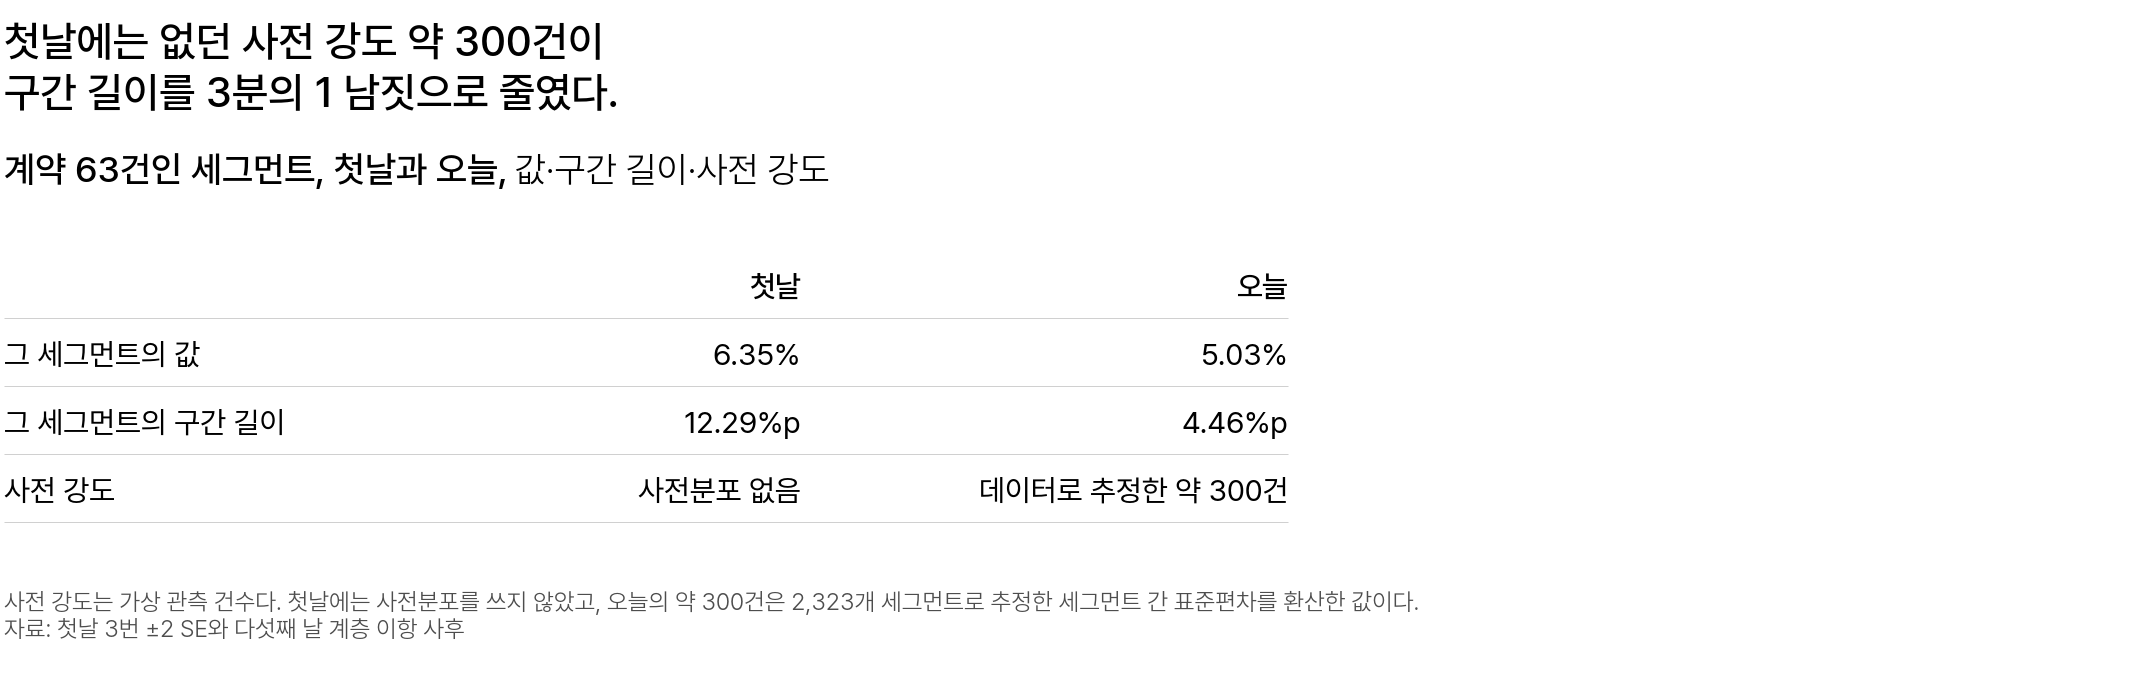

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계약 63건인 세그먼트 1개를 첫날과 오늘로 대조한 표 — 값은 1.32%p 감소했을 뿐인데 구간 길이가 12.29%p 에서 4.46%p 로 짧아졌다 — 첫날에는 사전분포 없이 그 세그먼트의 기록만 썼고, 오늘은 다른 세그먼트의 정보를 사전 강도 약 300건만큼 함께 썼다.</em></p>

그 세그먼트의 값은 5.03% 로 1.32%p 감소했을 뿐인데, 구간 길이는 3분의 1 남짓이 되었습니다. 그 차이를 만든 항목이 셋째 행의 사전 강도입니다.

> **그래서 사람이 지정한 102건을 데이터는 약 300건으로 추정했습니다.** 사전분포의 중심과 사전 강도를 사람이 지정하지 않고 둘 다 데이터가 정하게 바꾸자 「6. 사전 강도를 데이터로 추정」의 표에 적은 같은 세그먼트의 최빈값(MAP)이 0.0552 에서 0.0501 로 0.51%p 감소했습니다.

요율표의 빈도 항목에 적는 값은 계층 모형의 사후평균, 곧 표본의 평균인 0.0503 입니다. 심도는 이 모듈의 범위 밖이라 빈도 쪽만 적습니다. 그 표의 0.0552 와 0.0501 은 사전분포 2개를 같은 세그먼트에 대입해 얻은 최빈값이라 요율표에 적는 값이 아닙니다.

## 다음에 이어지는 것

실습에서는 오늘의 계층 모형을 PyMC 로 다시 만들고, 과제에서는 상대 구간 길이로 세그먼트를 자동 승인과 사람 심사로 나눈 요율표를 파일로 저장합니다.

오늘 다루지 않은 것도 있습니다. 우리는 세그먼트들이 **서로 무관하게** 하나의 공통 분포를 따른다고 두었습니다. 지역이 가깝거나 차량 출력 등급이 비슷한 세그먼트는 서로 닮았을 가능성이 높습니다.

그 닮음까지 적은 것이 공간 구조와 순서 구조를 반영한 계층 모형입니다. 시간이 흐르는 방향으로 같은 일을 하는 모형이 다음 모듈의 주제입니다.

## 수업에서 다룰 질문

아래 문항은 개인이 먼저 답을 적고, 팀에서 하나로 모은 뒤 수업에서 대조하는 문항입니다.

> **[문제] 팀 토론 — 요율표에 102건을 적을까 약 300건을 적을까**
>
> 다음 분기 요율표를 새로 짭니다. 관측이 적은 세그먼트의 값을 어떻게 계산할지 두 안이 대립했습니다.
> 
> **관점 A — 사람이 지정한 102건을 쓰자.** 사전 강도를 회사가 정하면 값이 어디서 왔는지 설명할 수 있습니다. 감독 당국이 「이 세그먼트의 요율 근거가 무엇이냐」고 물었을 때 「사전 강도 102건인 사전분포를 지정했다」는 한 문장이 답이 됩니다. 약 300건은 지난 분기 데이터로 추정한 값이라 다음 분기에 다시 실행하면 280 이 될 수도 있고 310 이 될 수도 있습니다. 그때마다 요율표 전체가 달라집니다.
> 
> **관점 B — 데이터가 추정한 약 300건을 쓰자.** 102건은 근거가 없습니다. 둘째 날 그 수를 지정한 이유는 「그 정도면 적당해 보였다」 하나였습니다. 사전 강도를 20 에서 1,020 까지 어디에 두느냐에 따라 같은 세그먼트의 값이 0.0516 에서 0.0583 으로 달라지고, 두 값의 차이가 0.67%p 입니다. 보험료로는 13% 차이입니다. 데이터로 추정한 값은 분기마다 달라지지만 그 불확실성도 $\tau$ 의 신용구간 [0.241, 0.287] 로 함께 보고할 수 있습니다.
>
> 1. A (사람이 지정한 102건을 쓴다)
> 2. B (데이터가 추정한 약 300건을 쓴다)